HAZARDNET FULL PRODUCTION PIPELINE
[Step 1] Fetching raw data from Multi-API sources...
[19:09:02] Launching Unified Aggregator...
SUCCESS: Aggregated 70 events into HazardNet_Master_Dataset_Final.csv
[Step 2] Exploding locations to District-level geodata...
[Step 3] Mapping API metadata to Unique HazardNet Indices...
[Step 4] Generating dense 2000-2026 time-series grid...
Pipeline Complete. Final Dataset: 624512 rows.
[Prep] Filtering for events between 2000 and 2026...
GEE-ready events dataset saved: 3324 events.

STATISTICAL ANALYSIS & EXPORTS


,Metric,Value
0,Total Unique Events,3324
1,Unique Districts,64
2,Date Range Start,2000-05-02 00:00:00
3,Date Range End,2026-07-05 00:00:00
4,Mean Severity Score,1.0
5,Total Validated Affected,0.0



--- HazardNet Descriptive Statistics Summary ---


,Metric,Value
0,Total Events (2000-2026),3324
1,Unique Districts Affected,64
2,Avg Events Per Year,132.96
3,Primary Hazard Type,Flood
4,Most Frequent District,Bandarban



All statistical CSVs saved.

GENERATING ALL VISUALIZATIONS


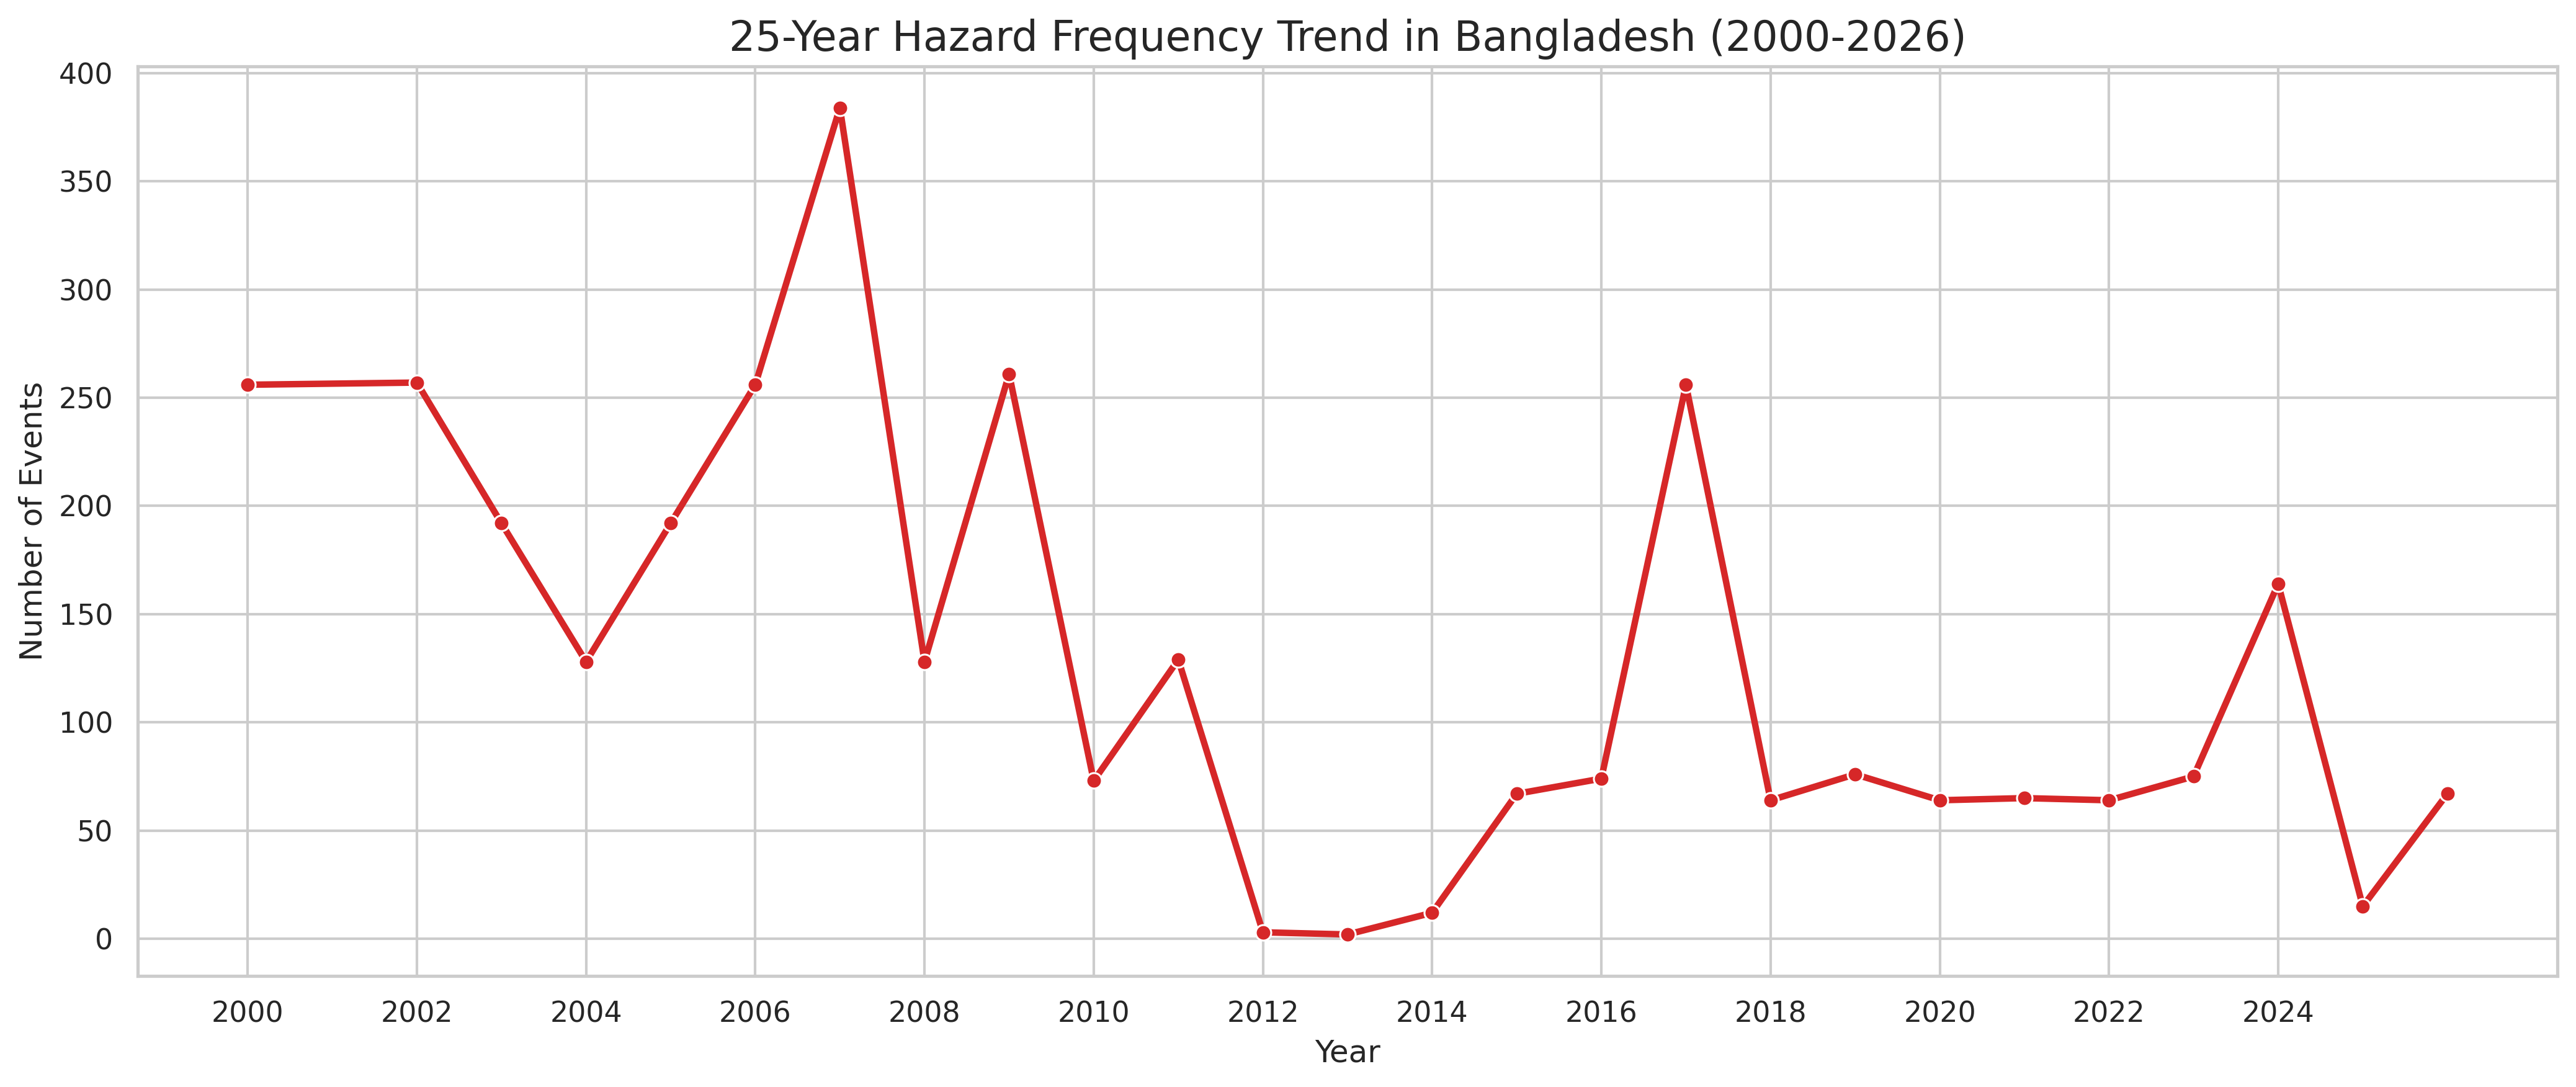

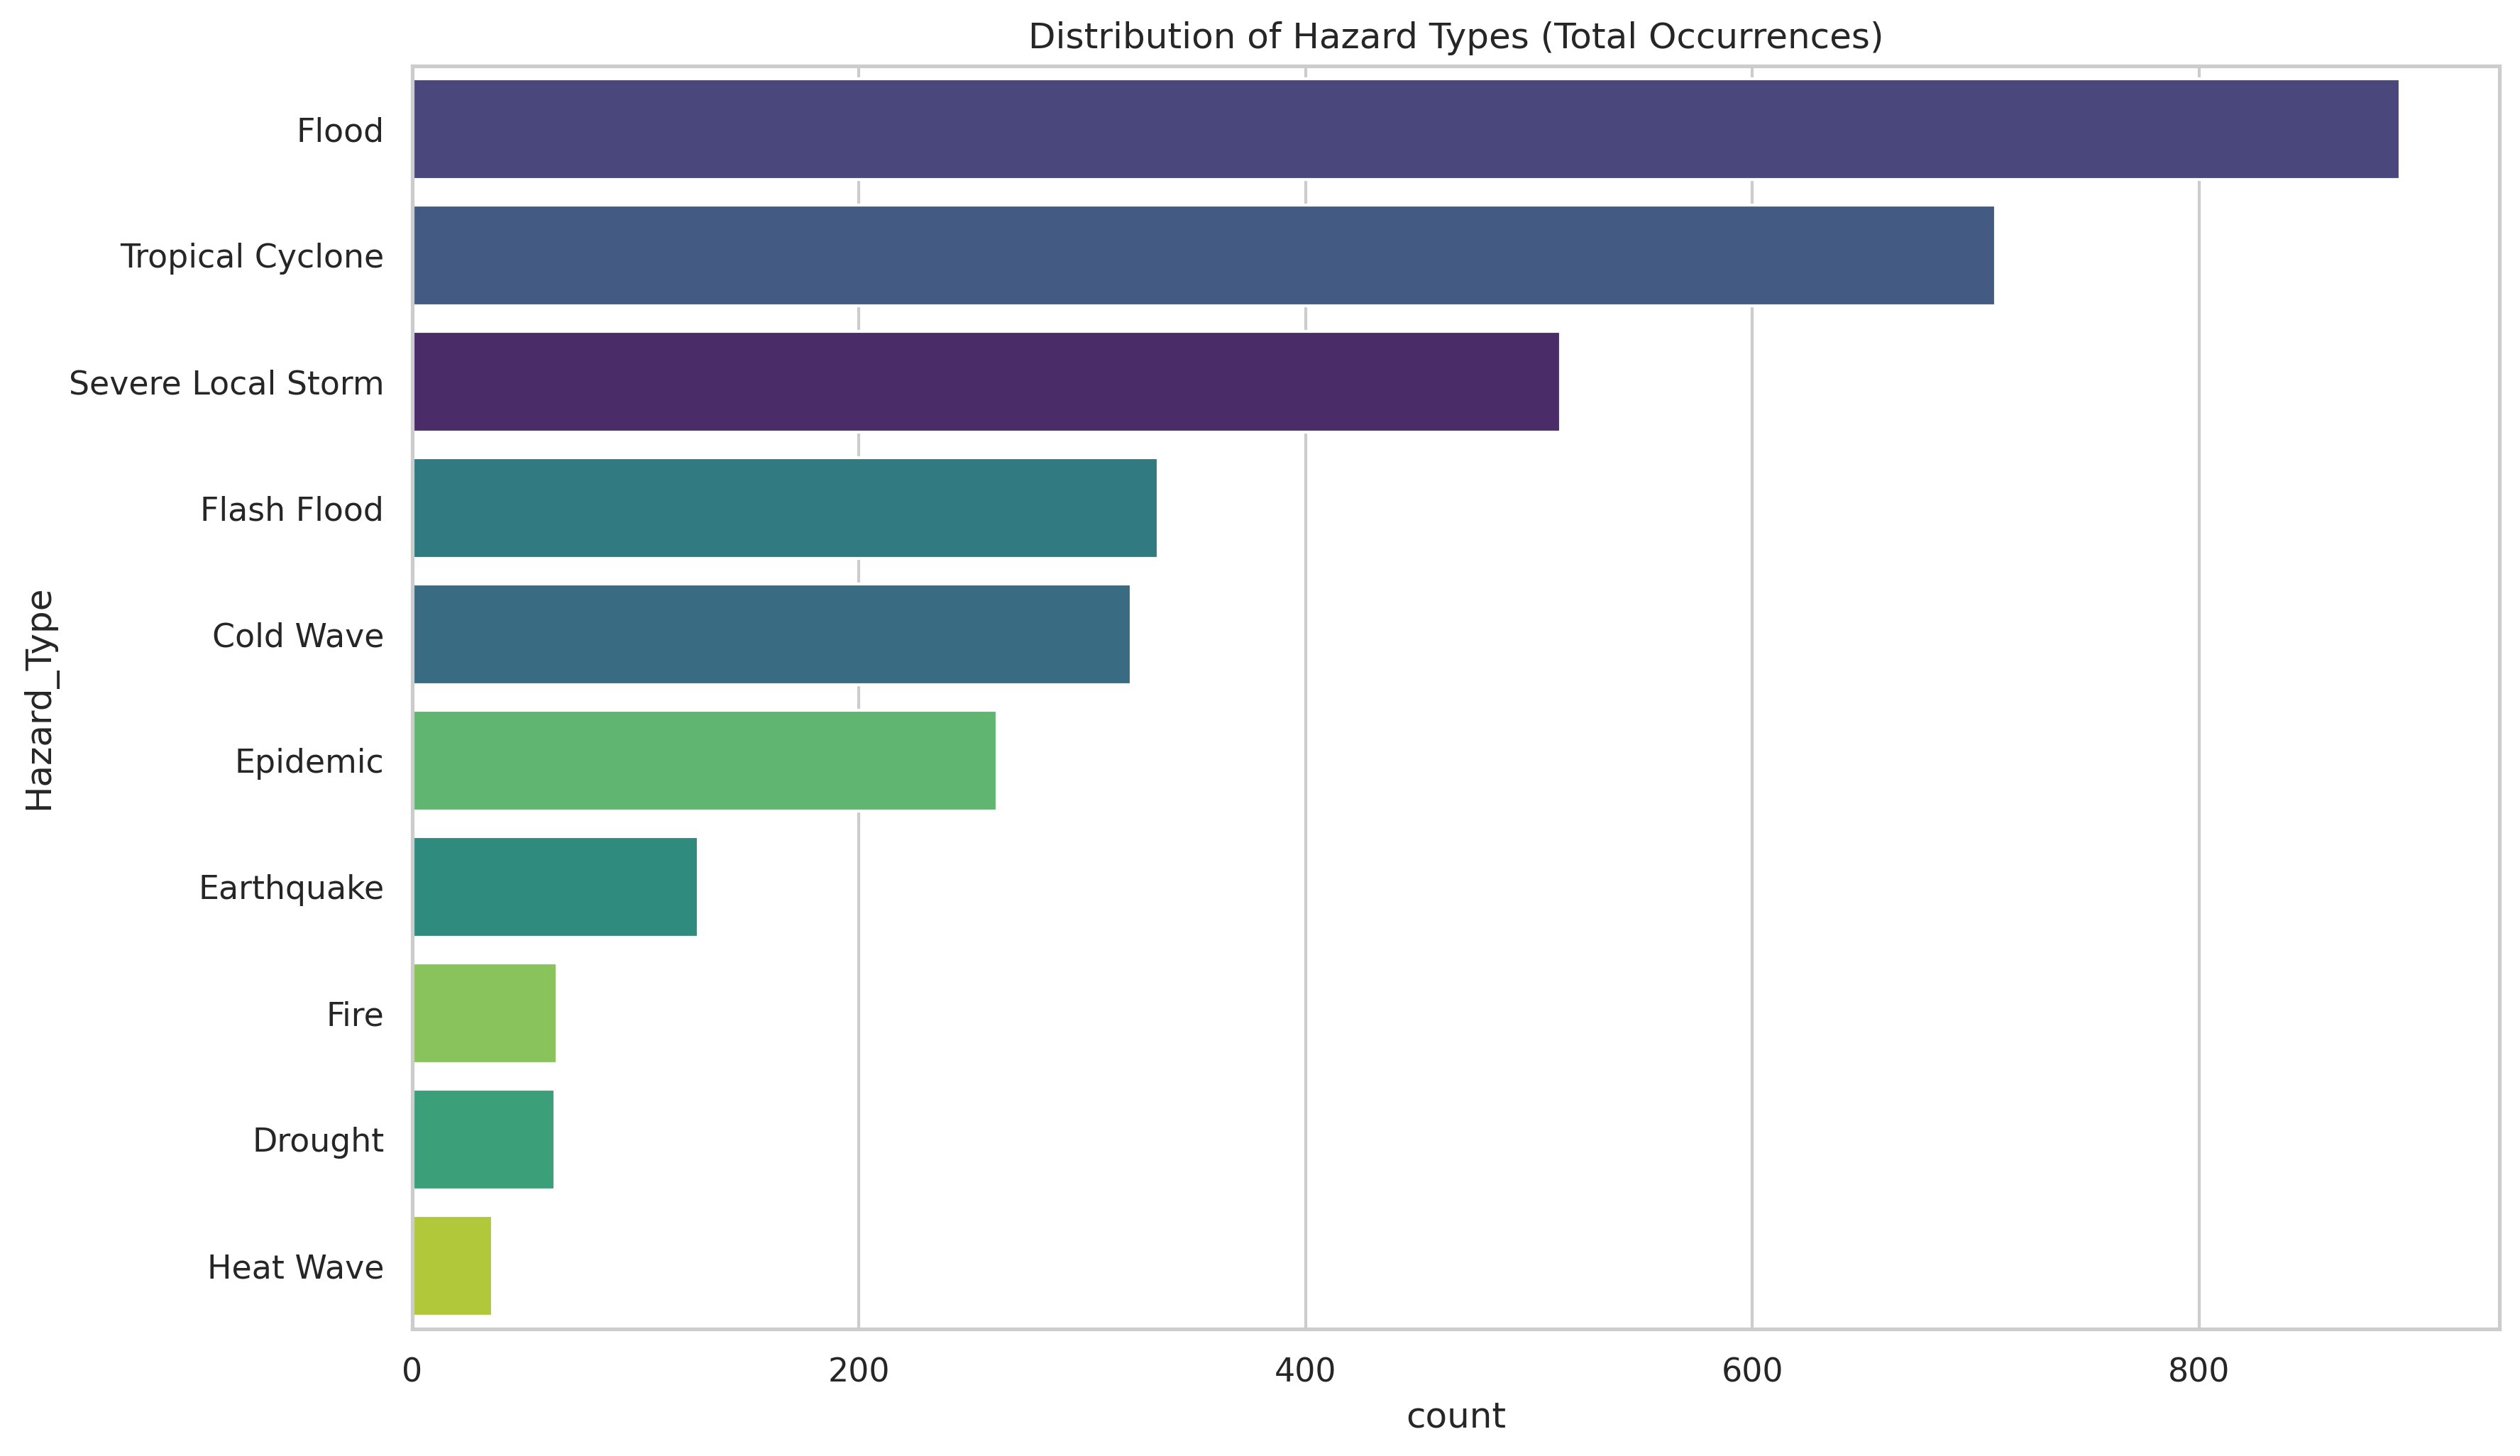

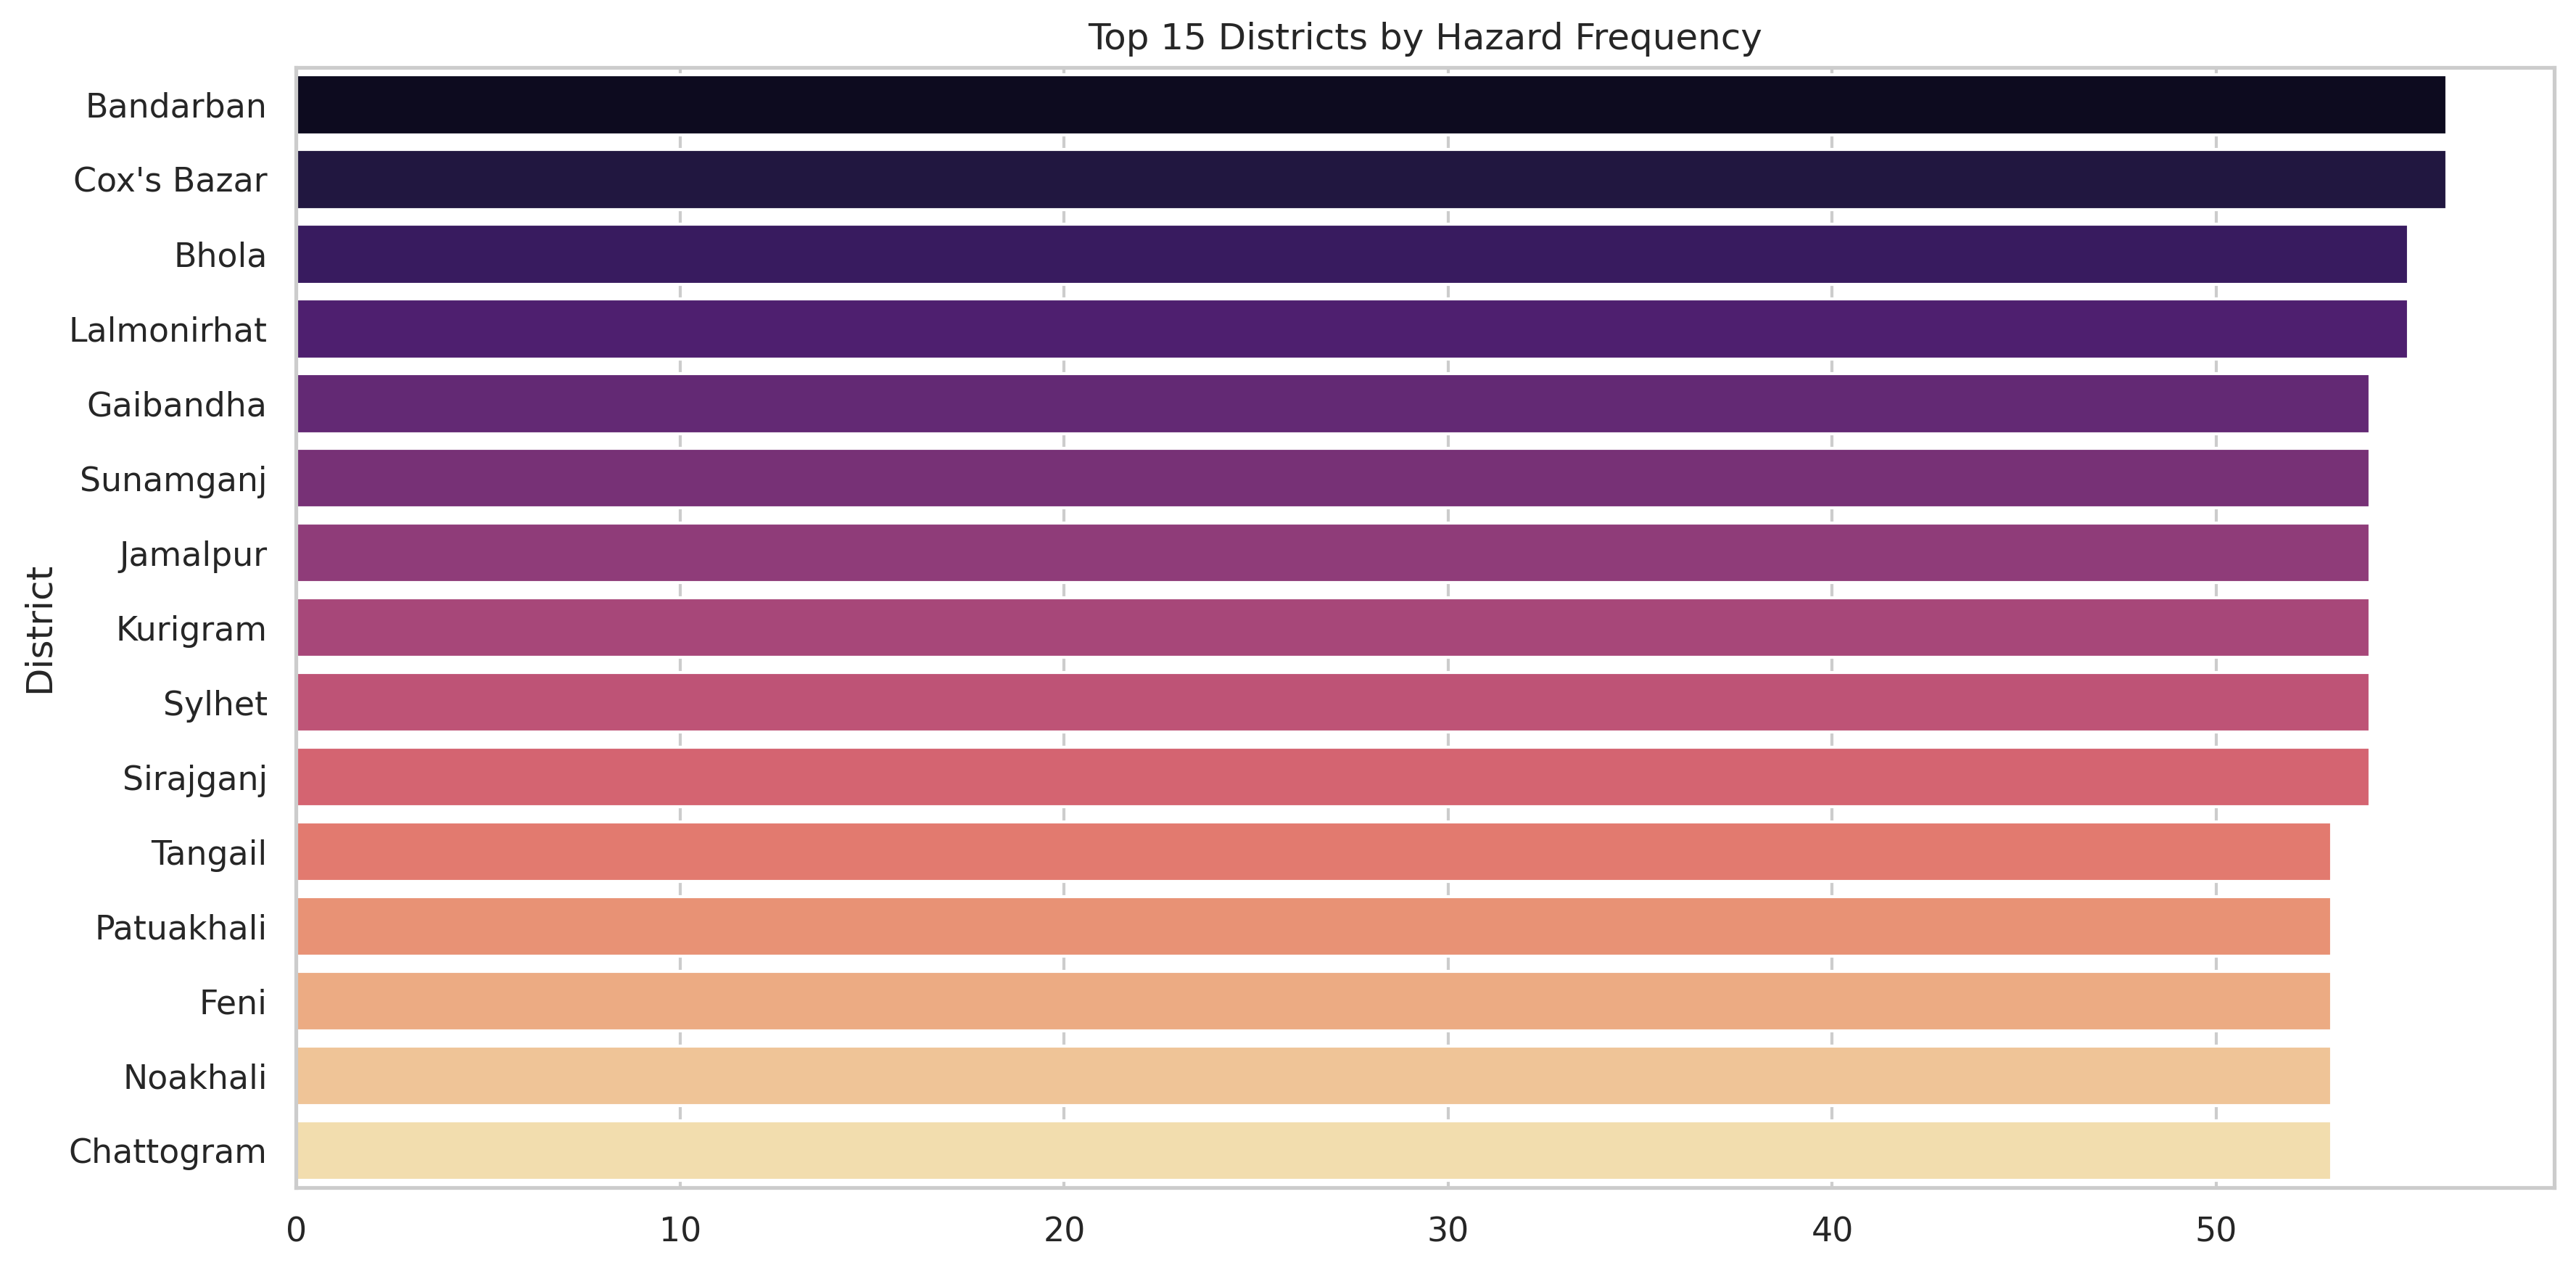

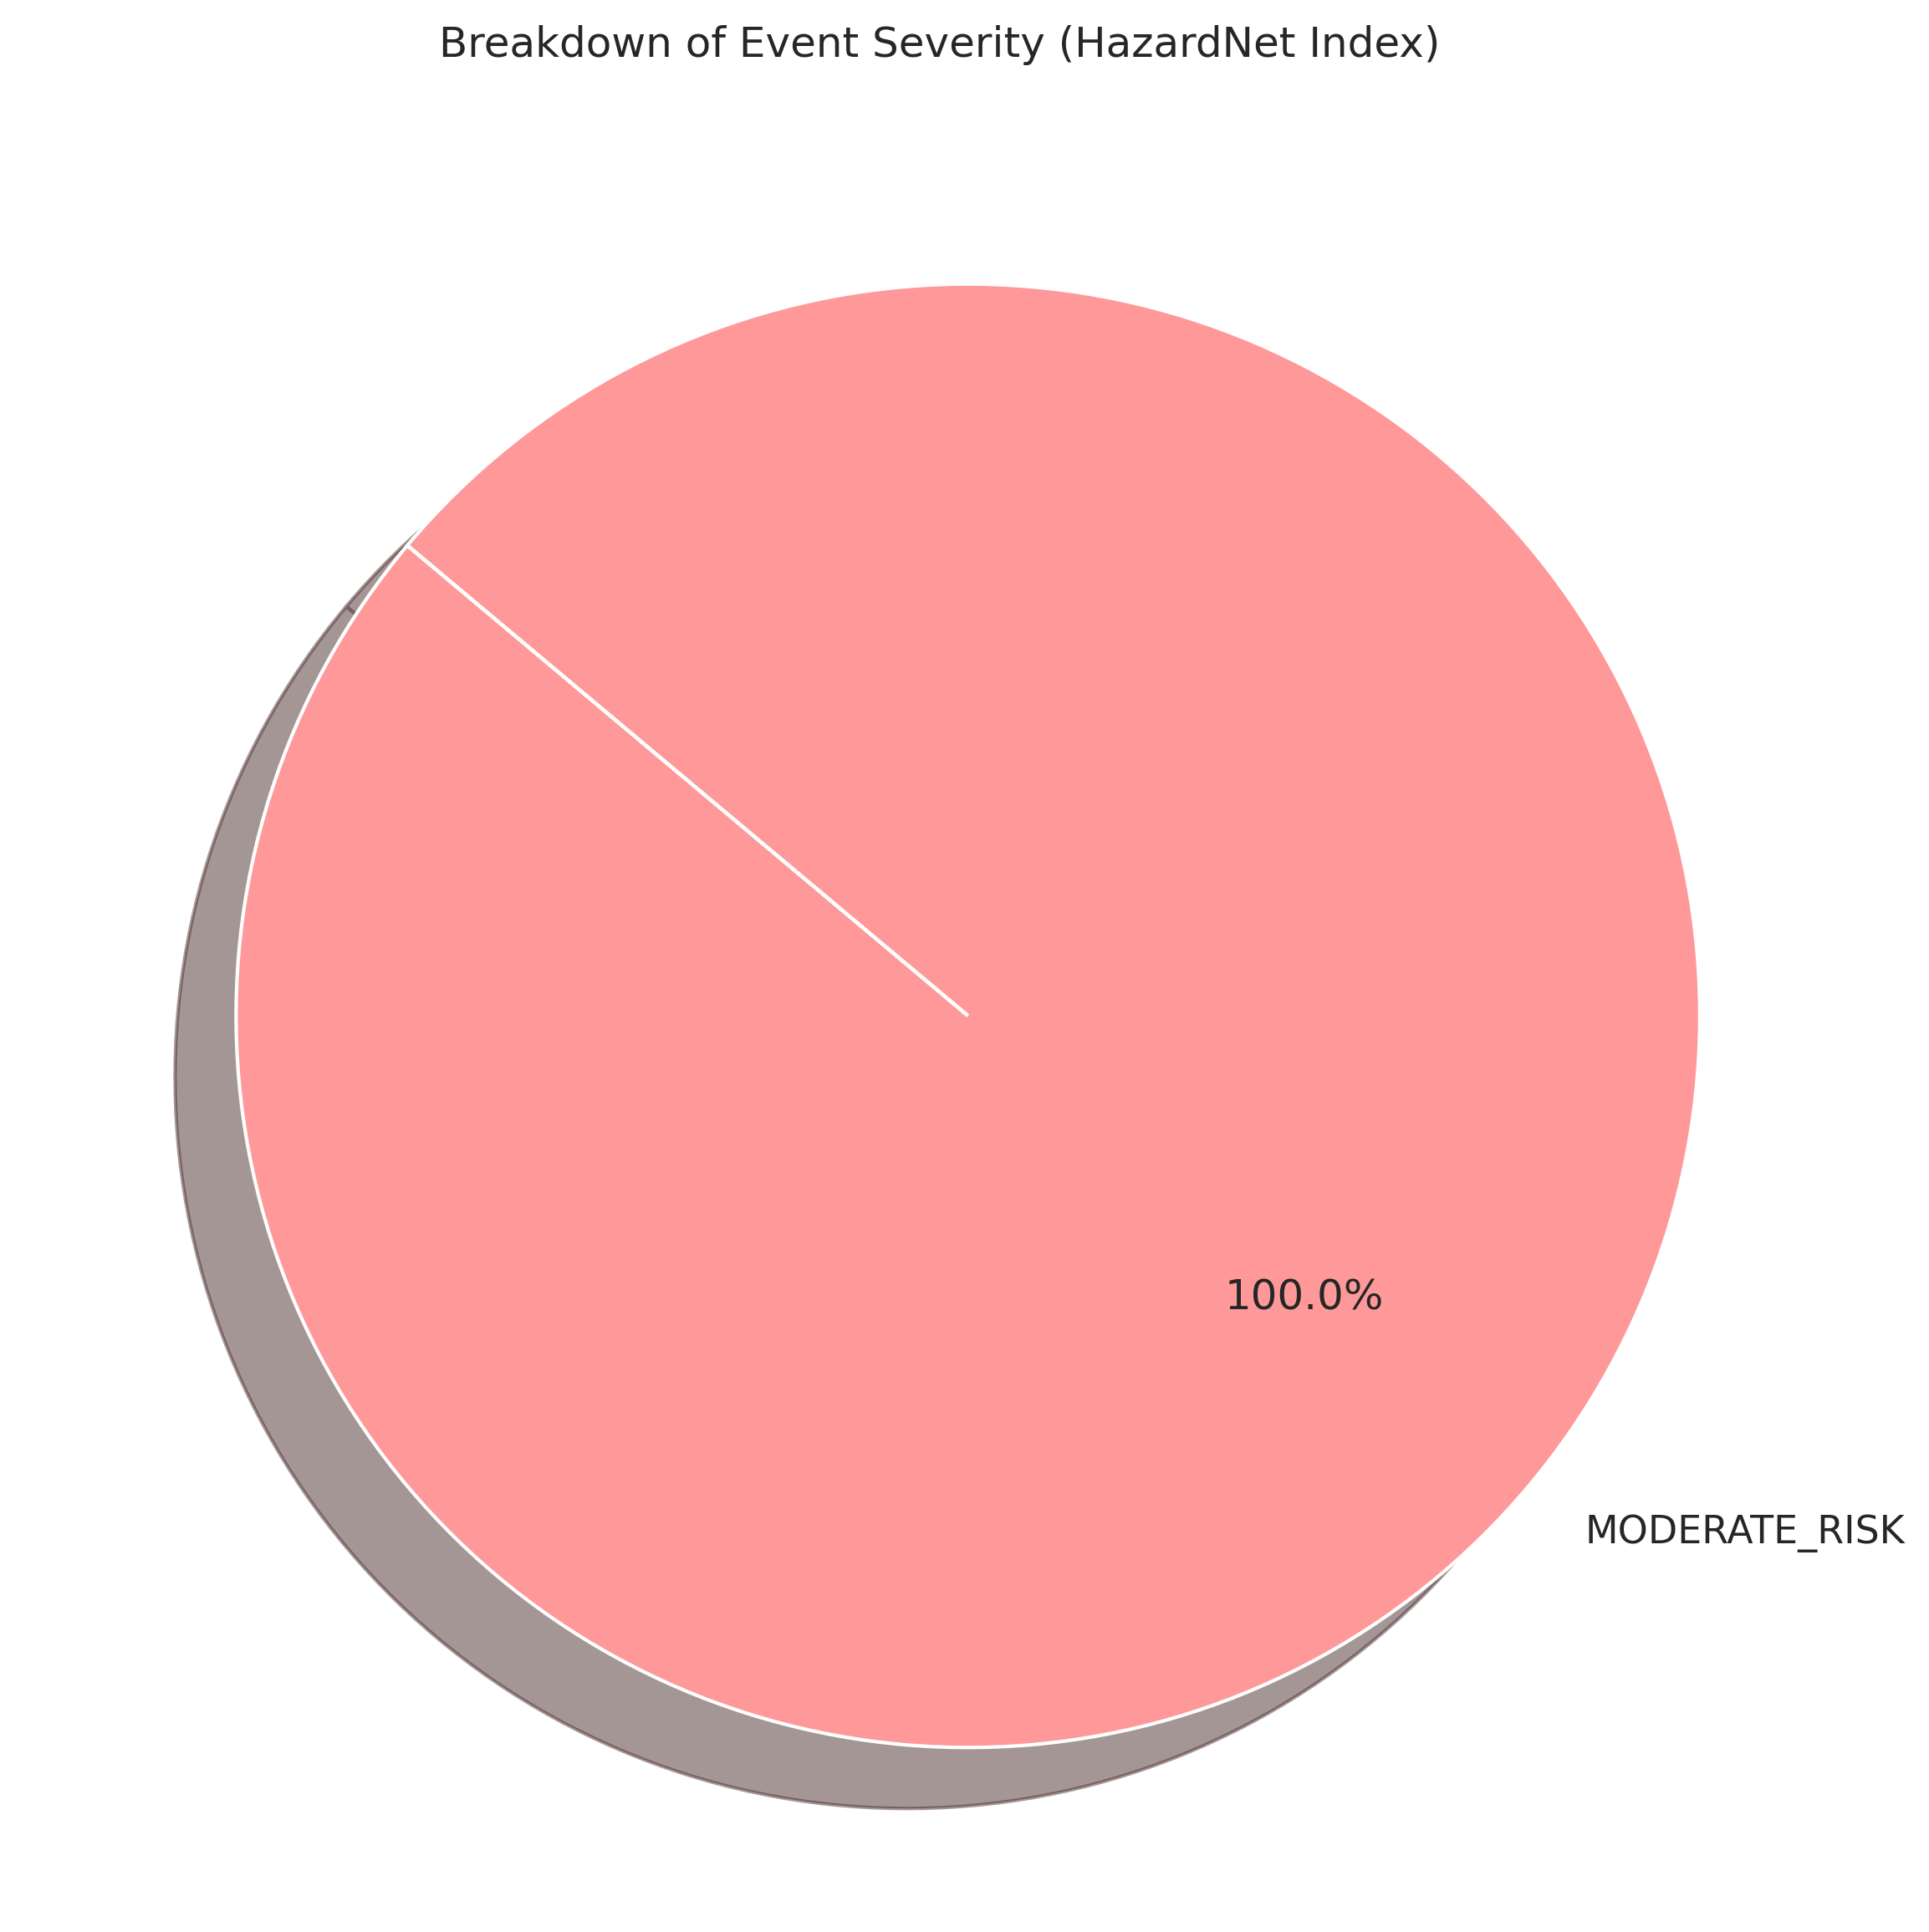

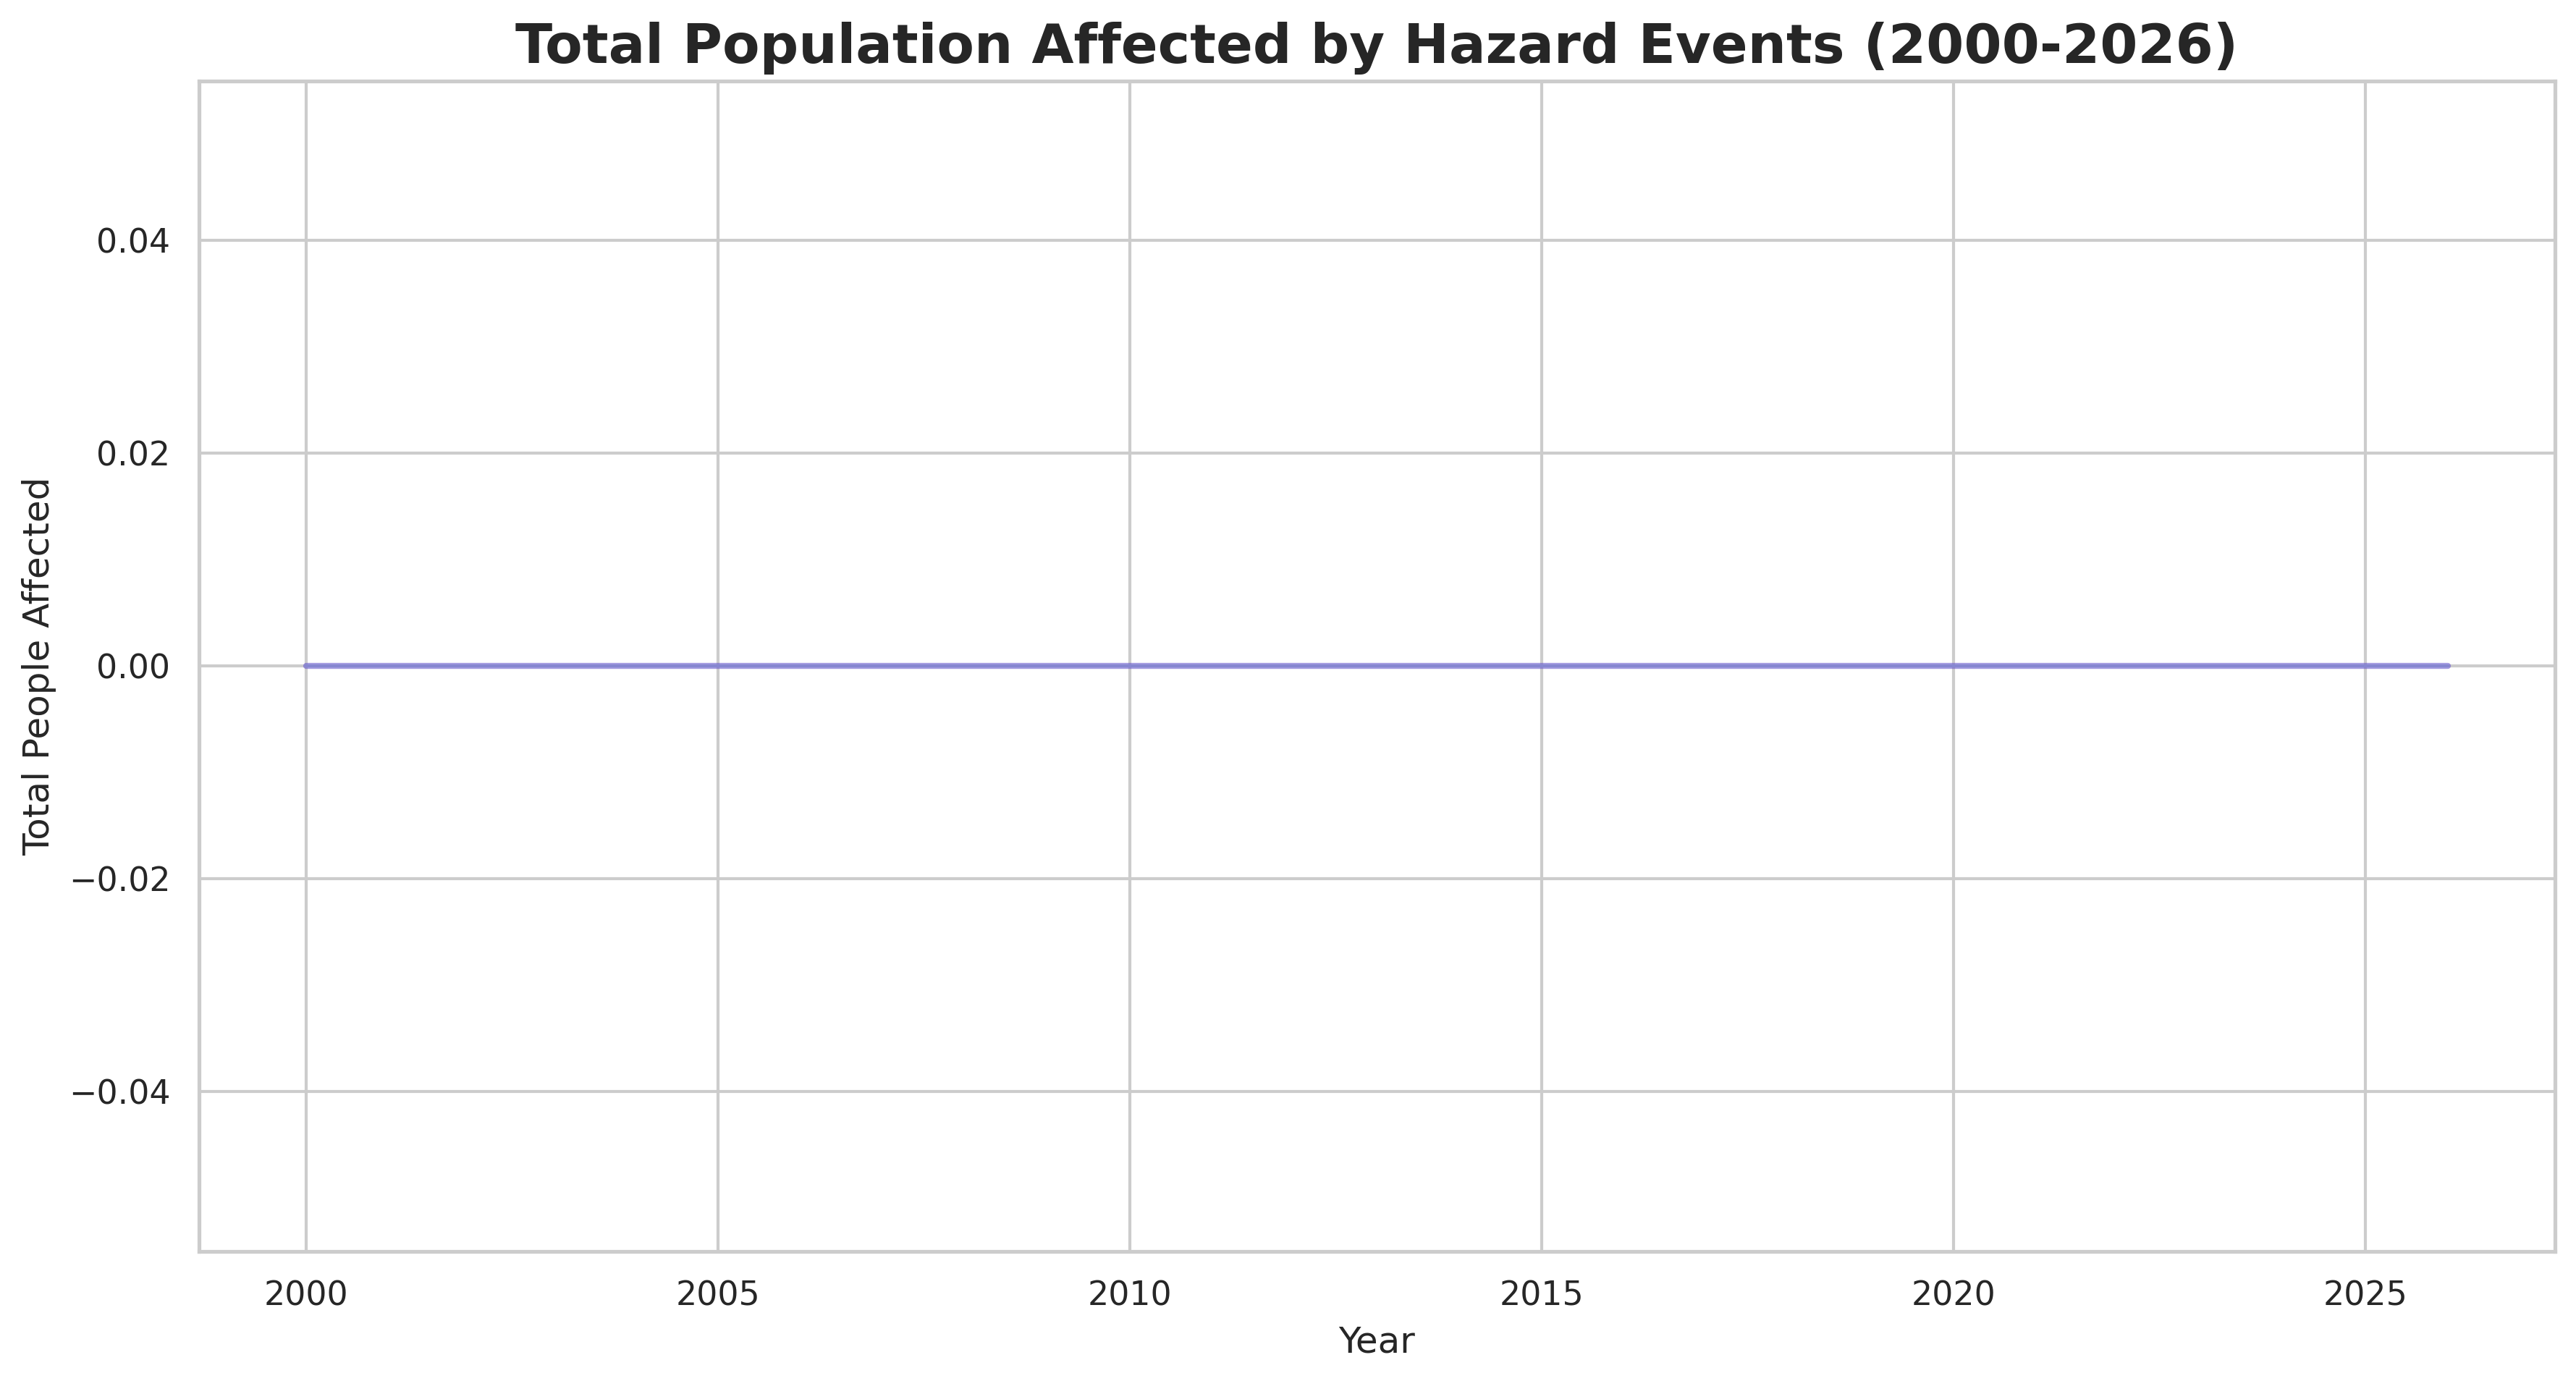

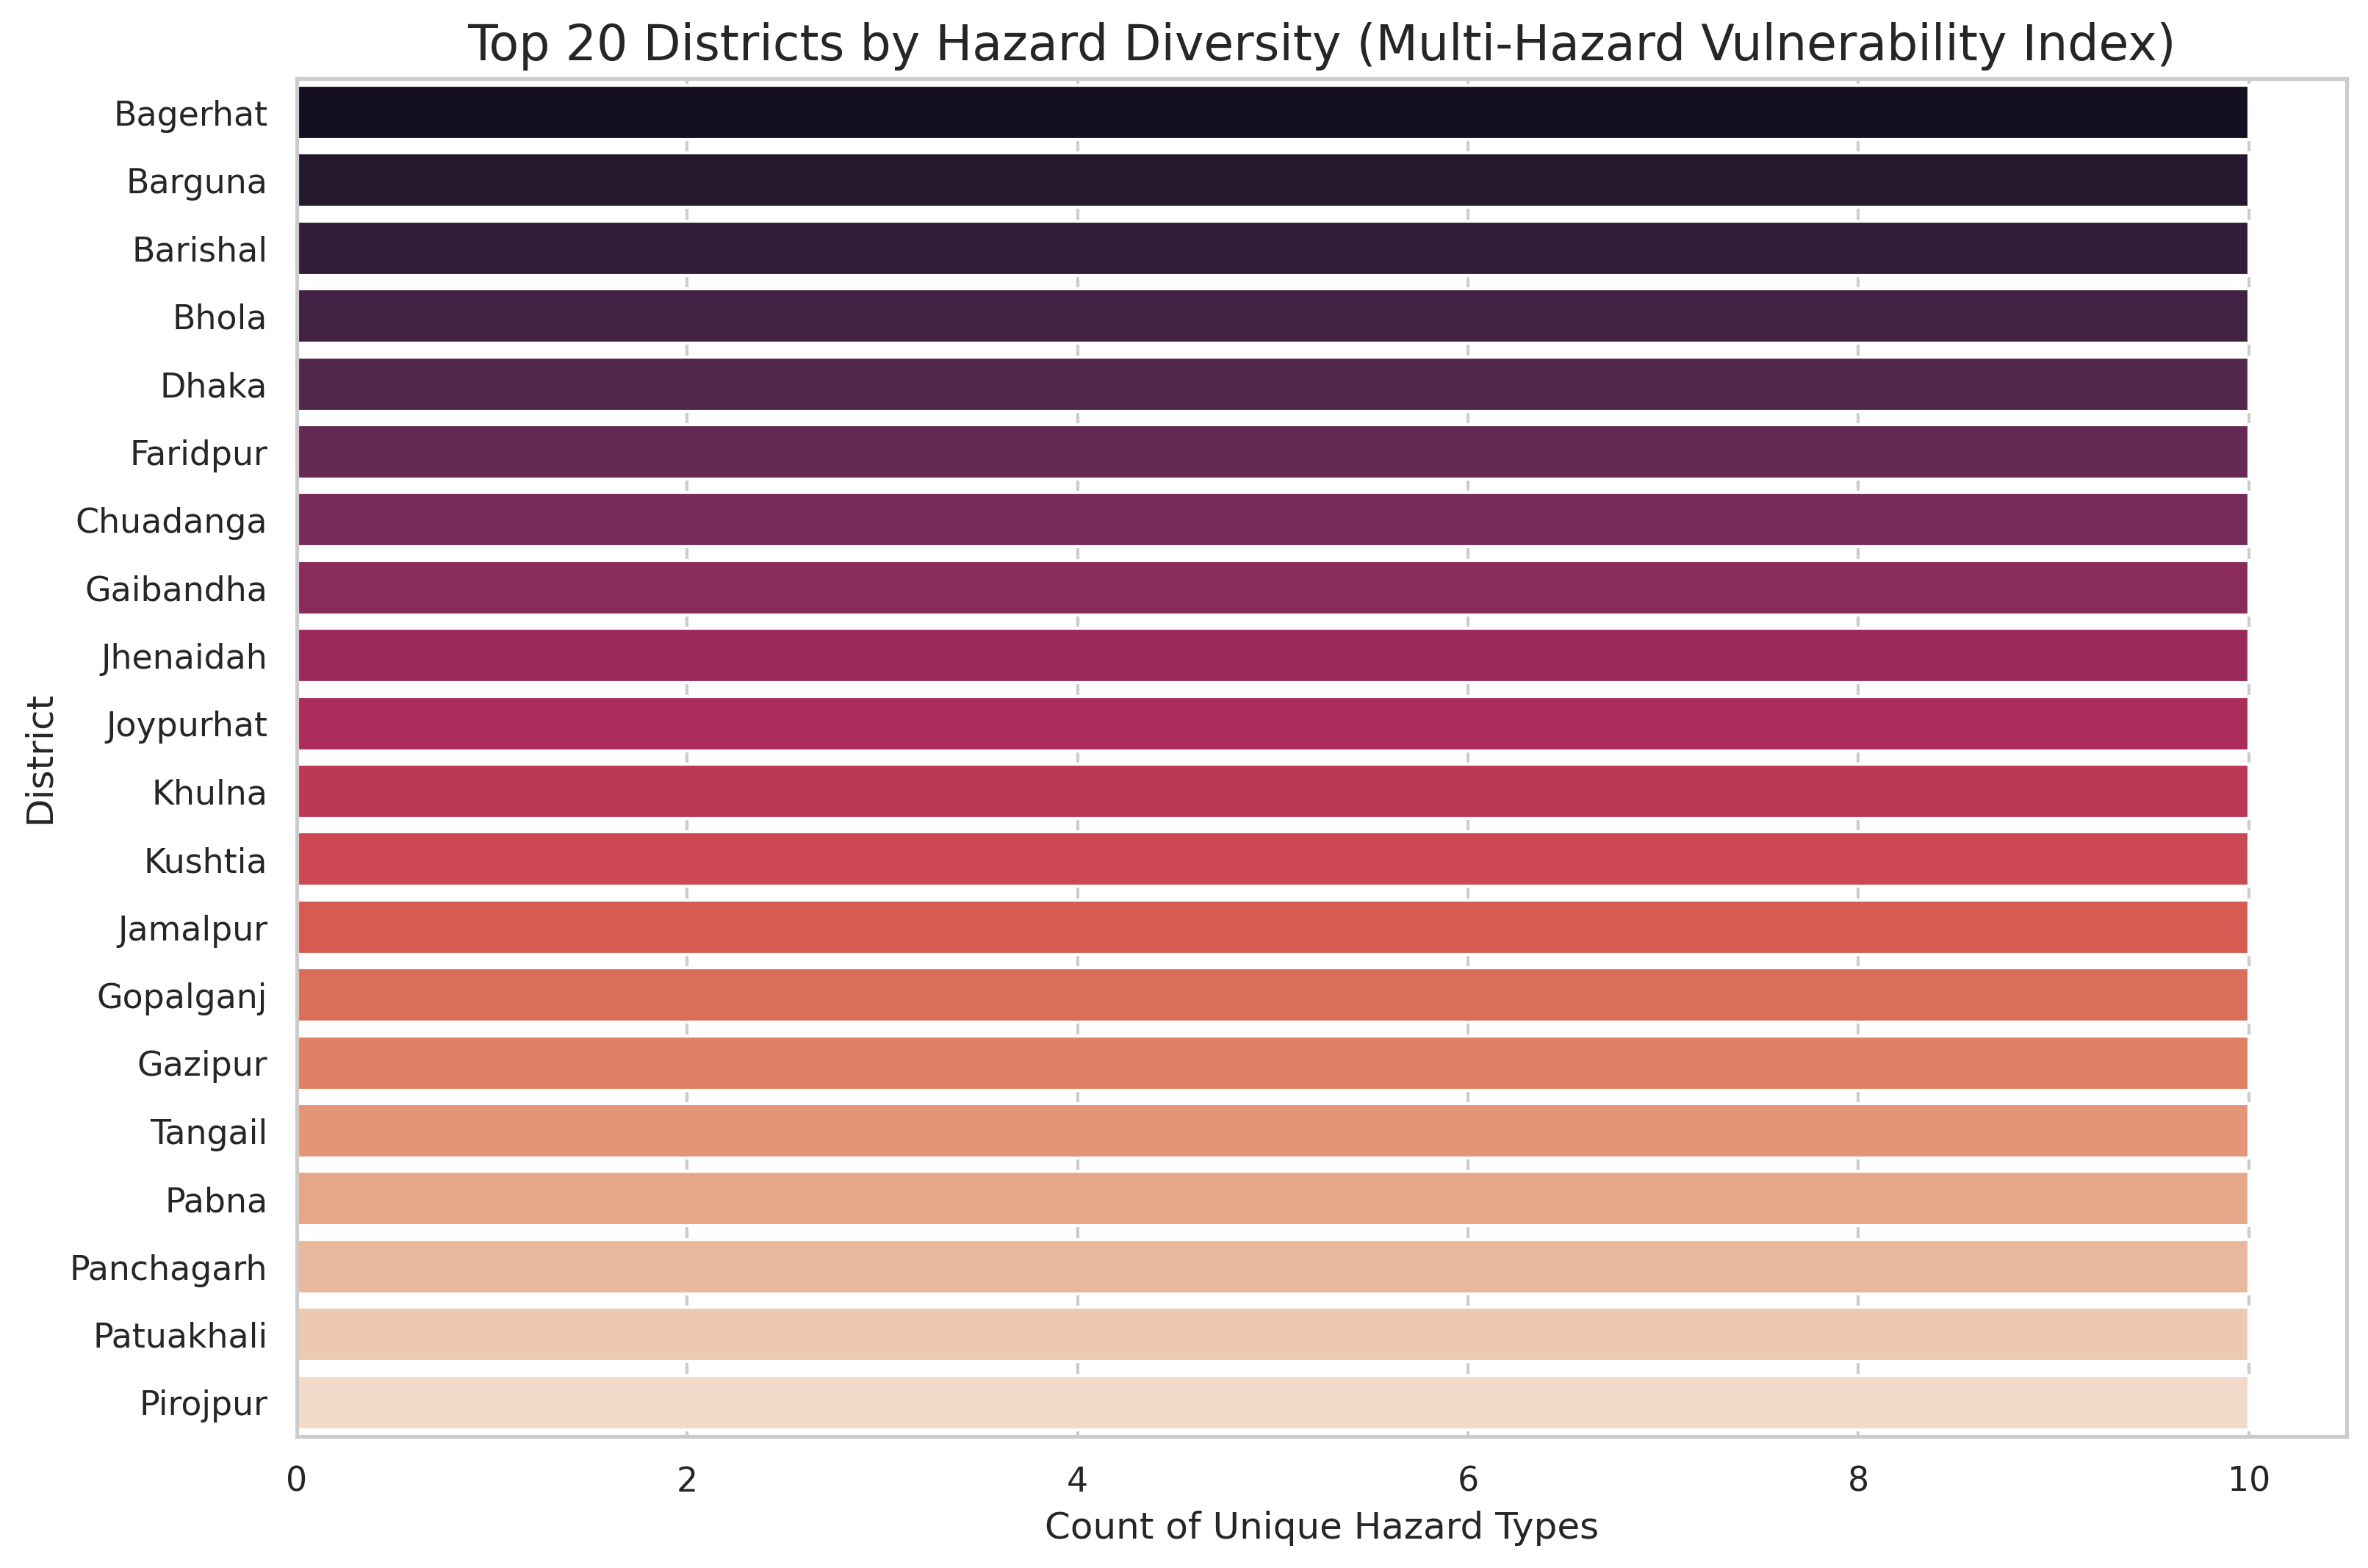

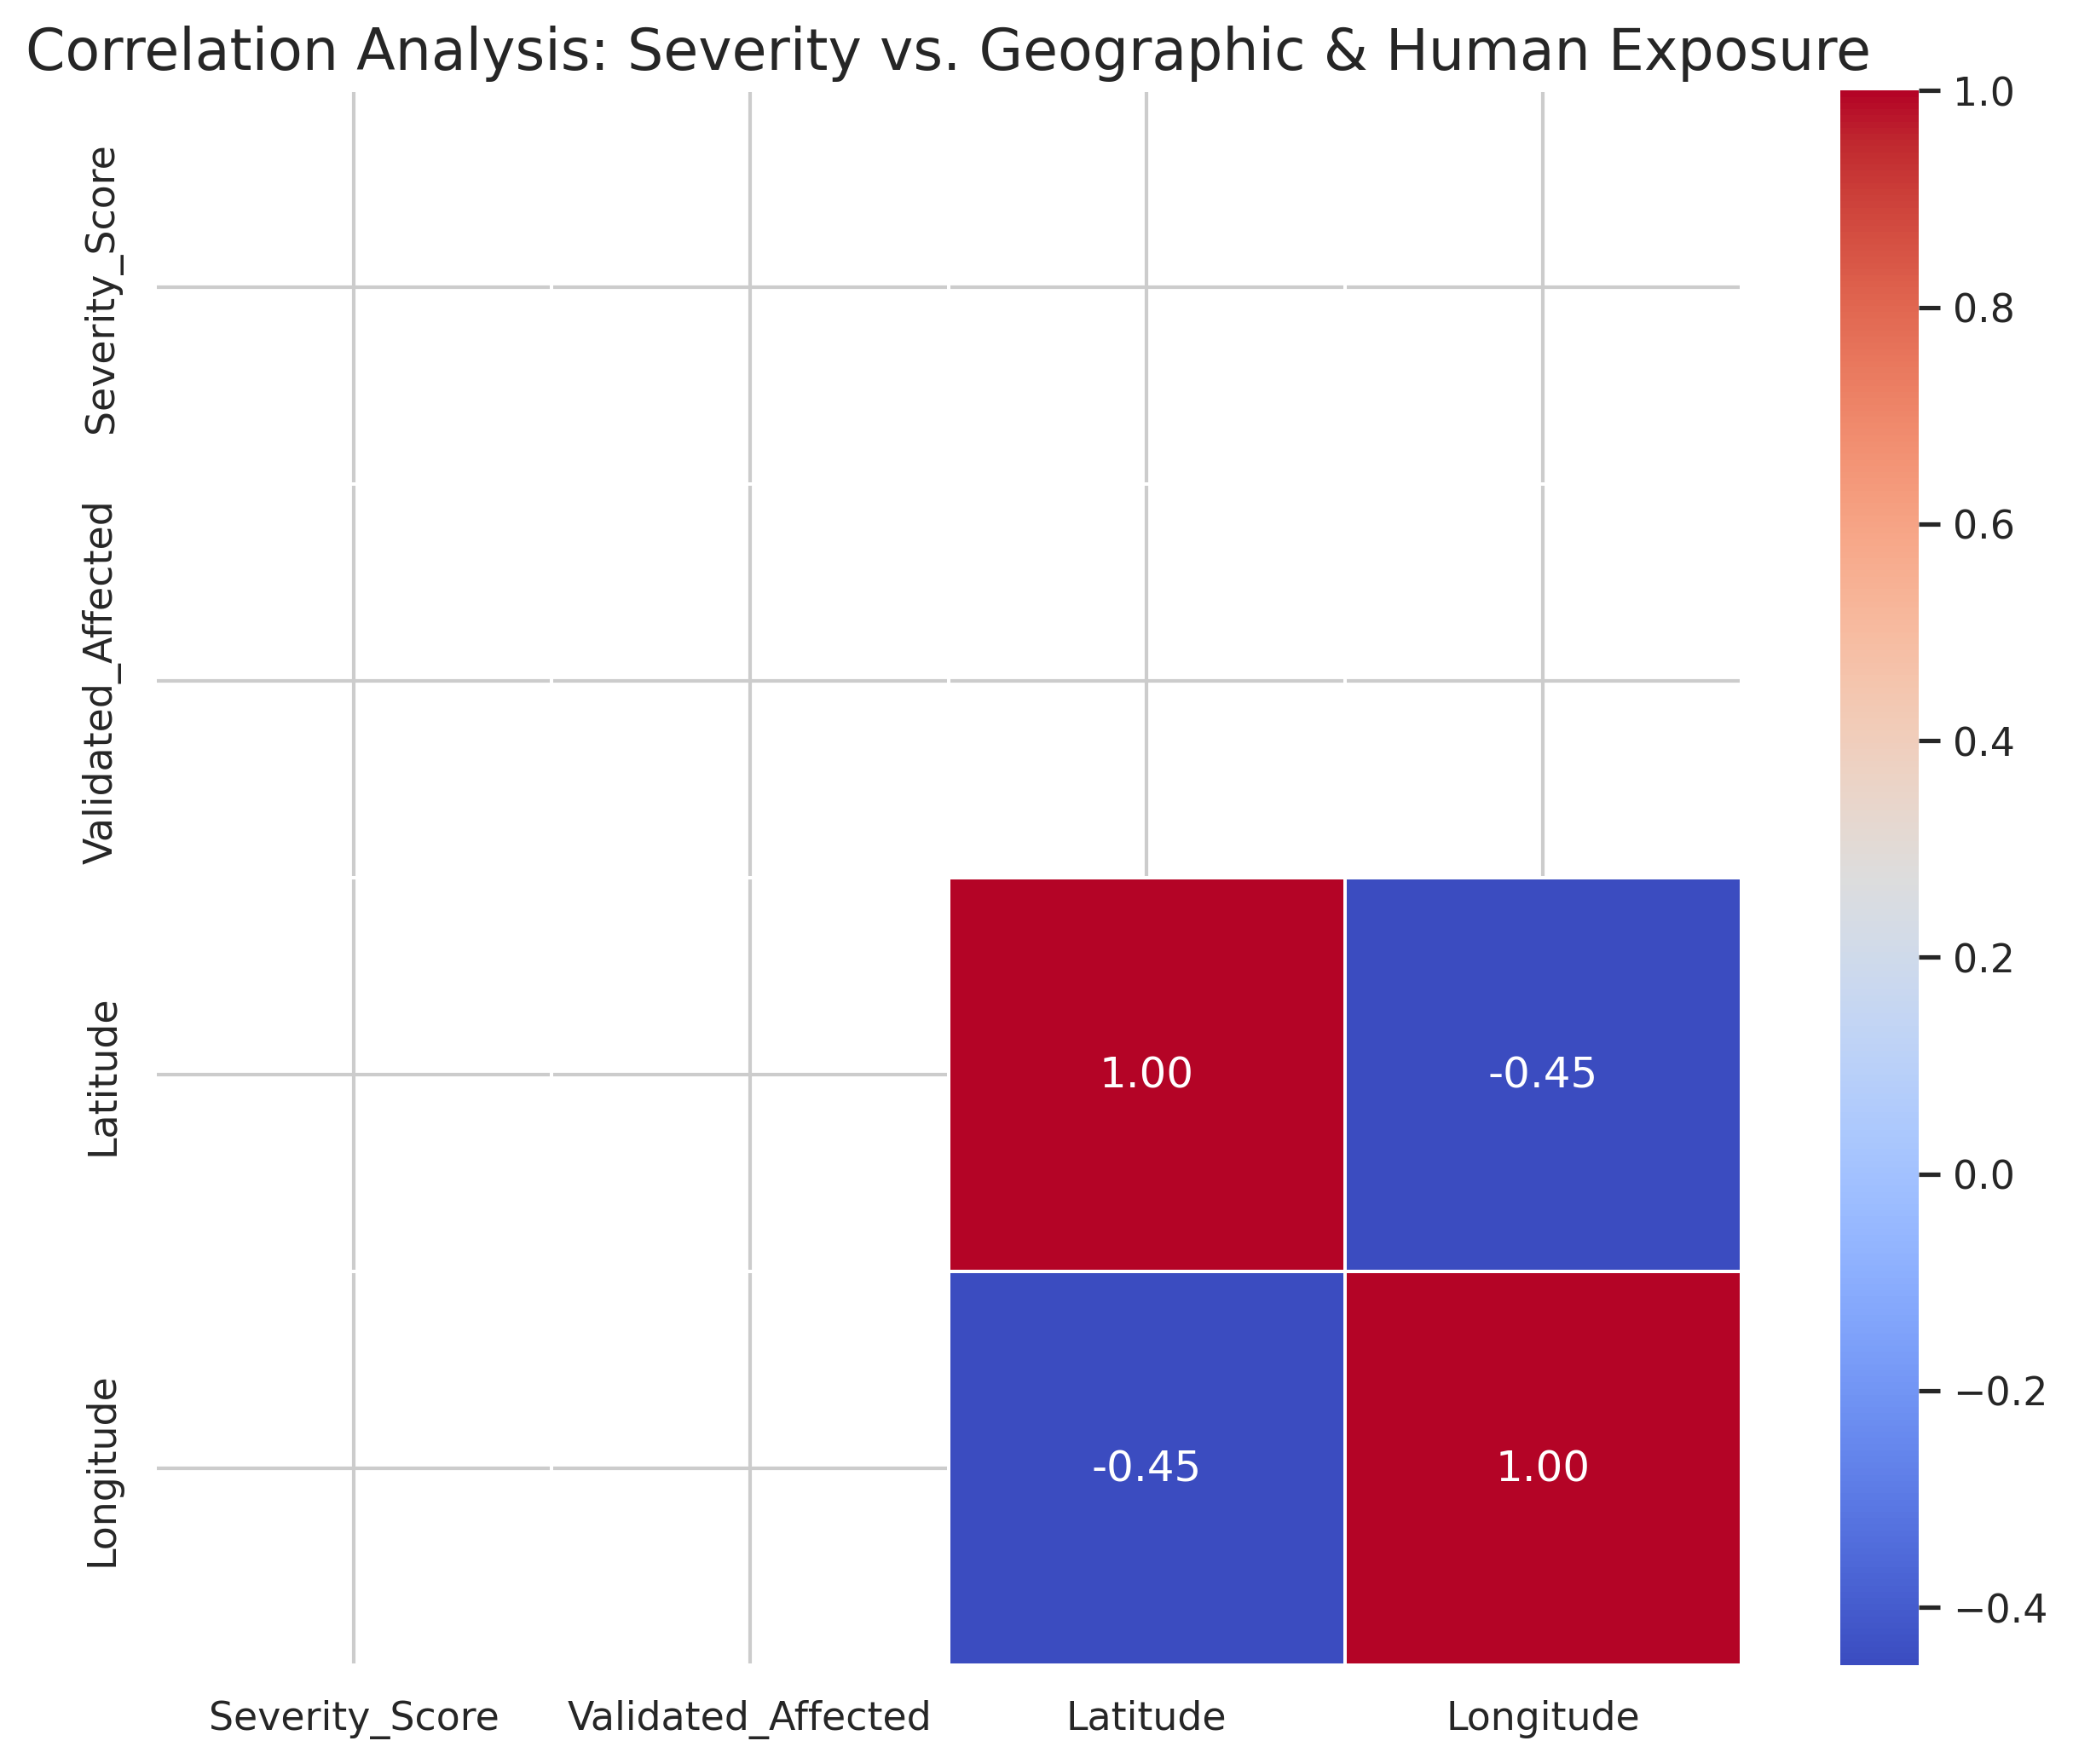

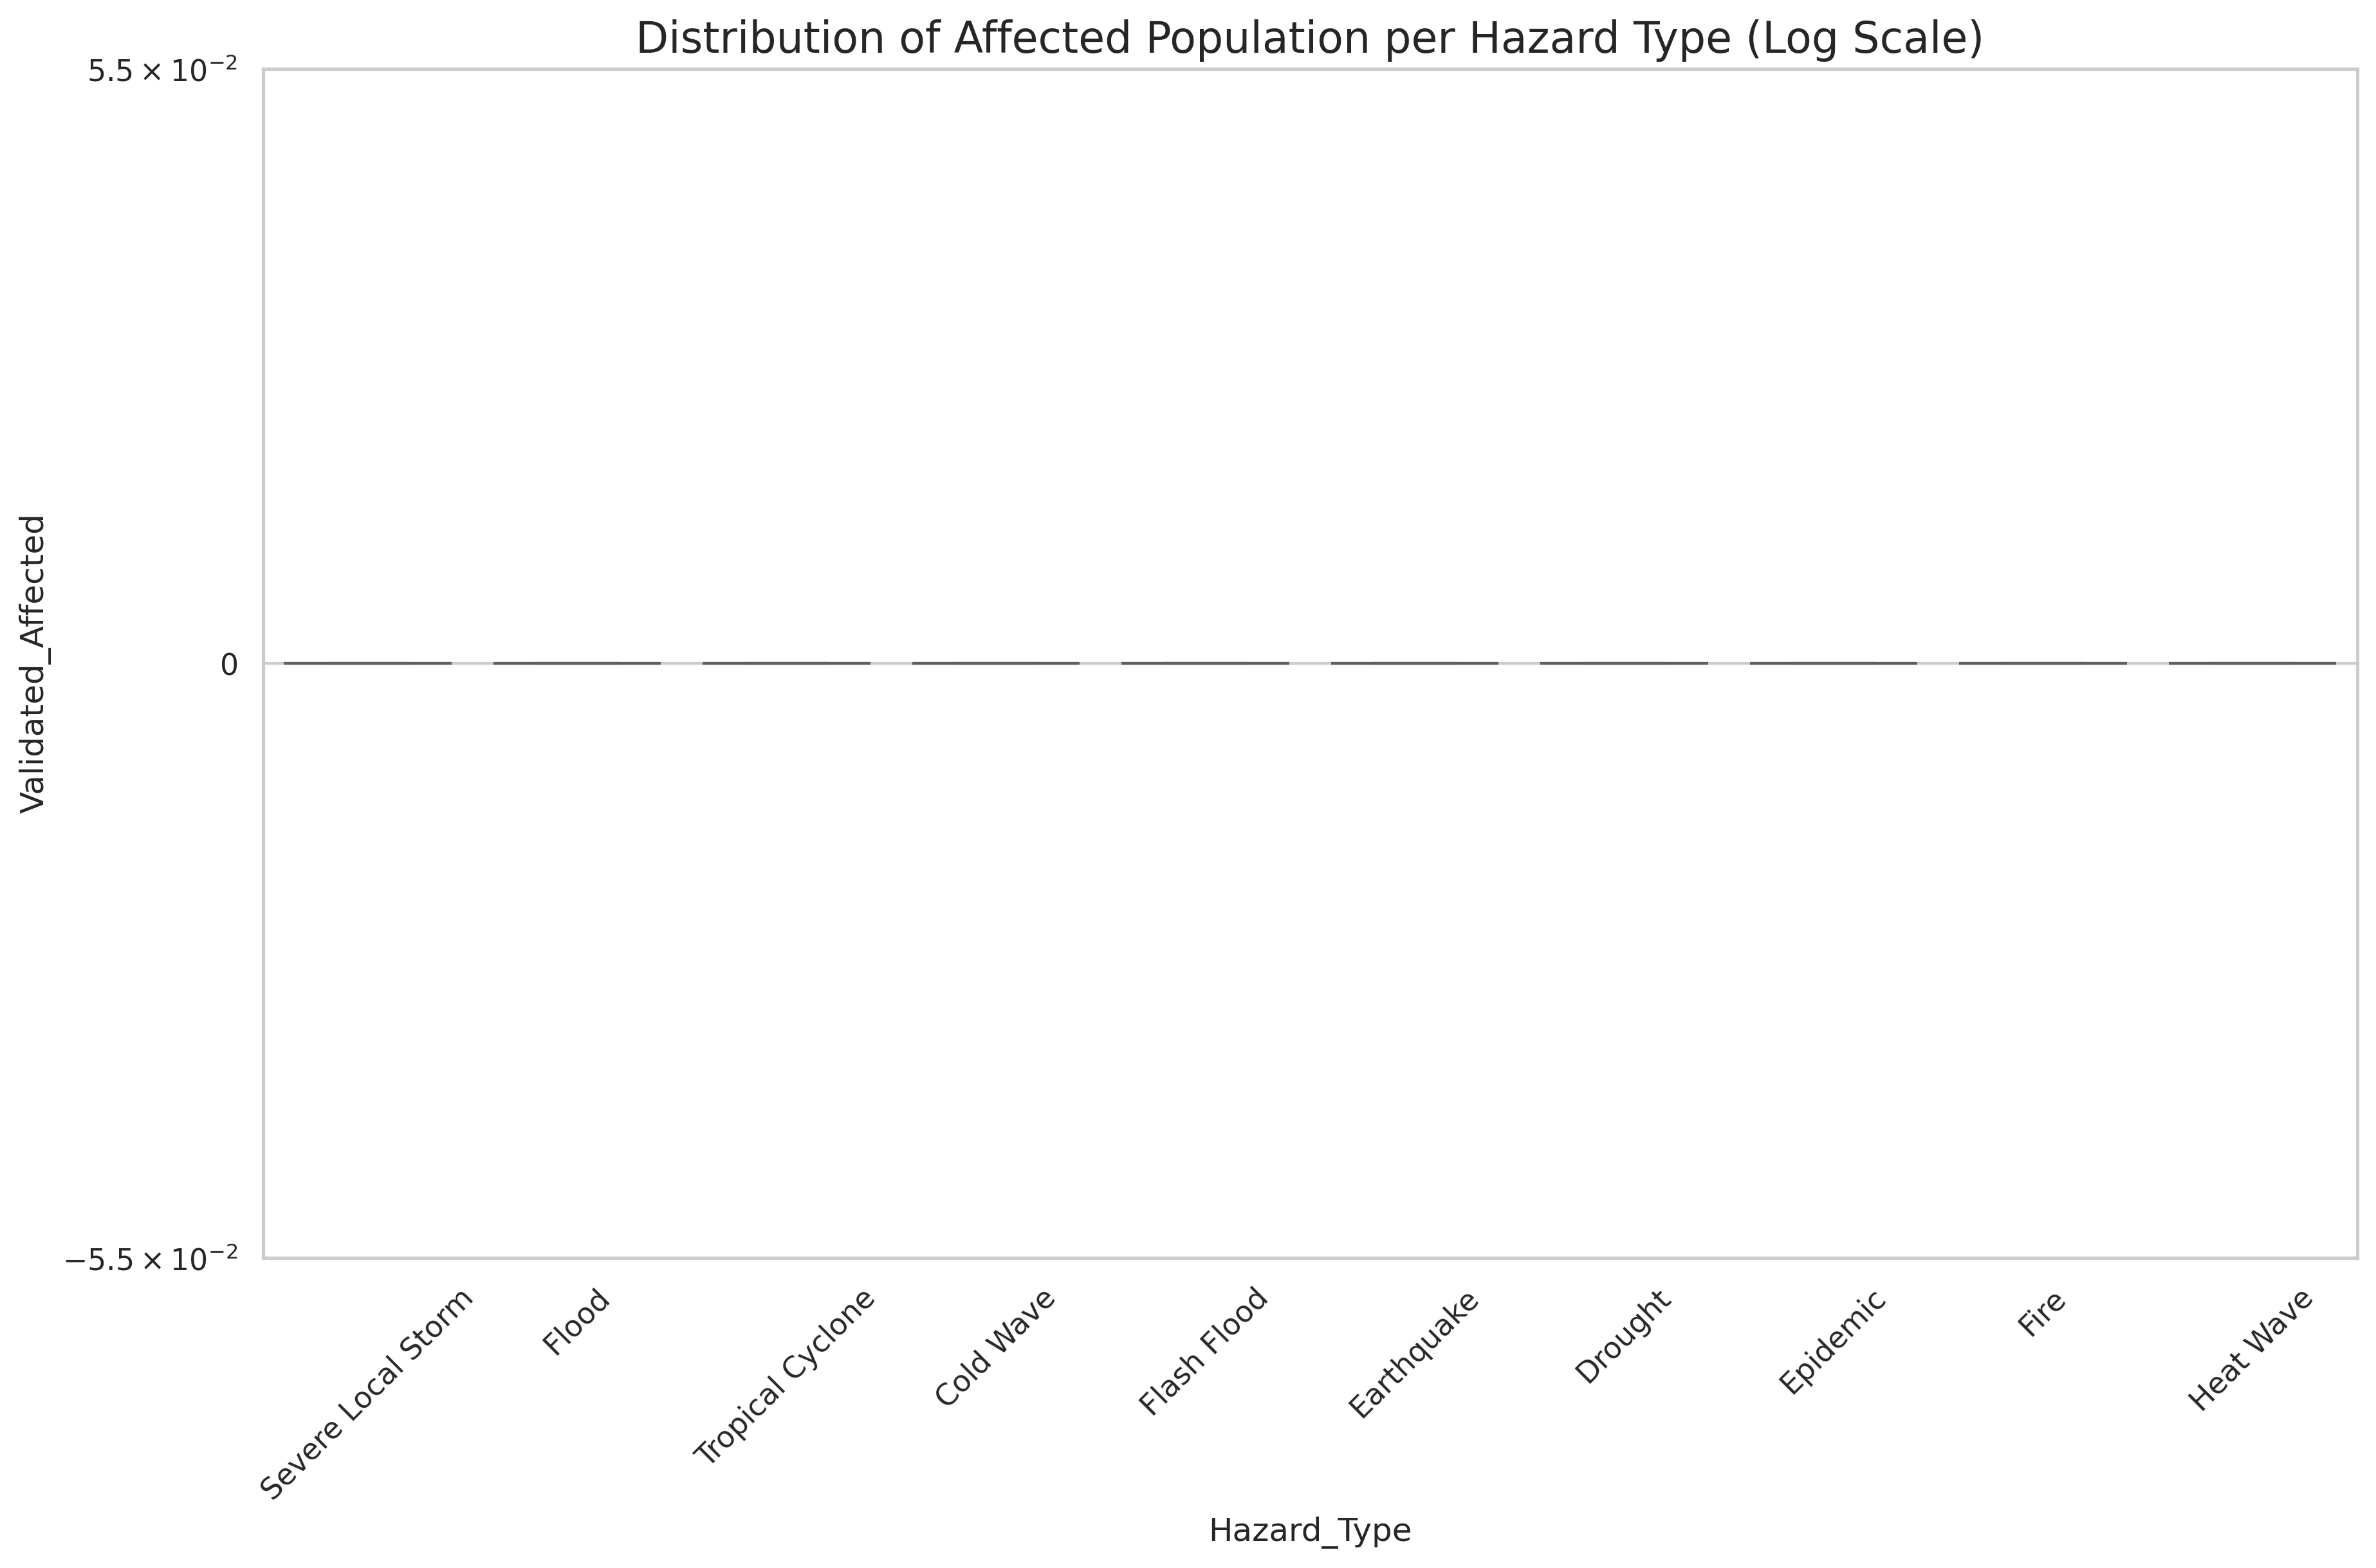

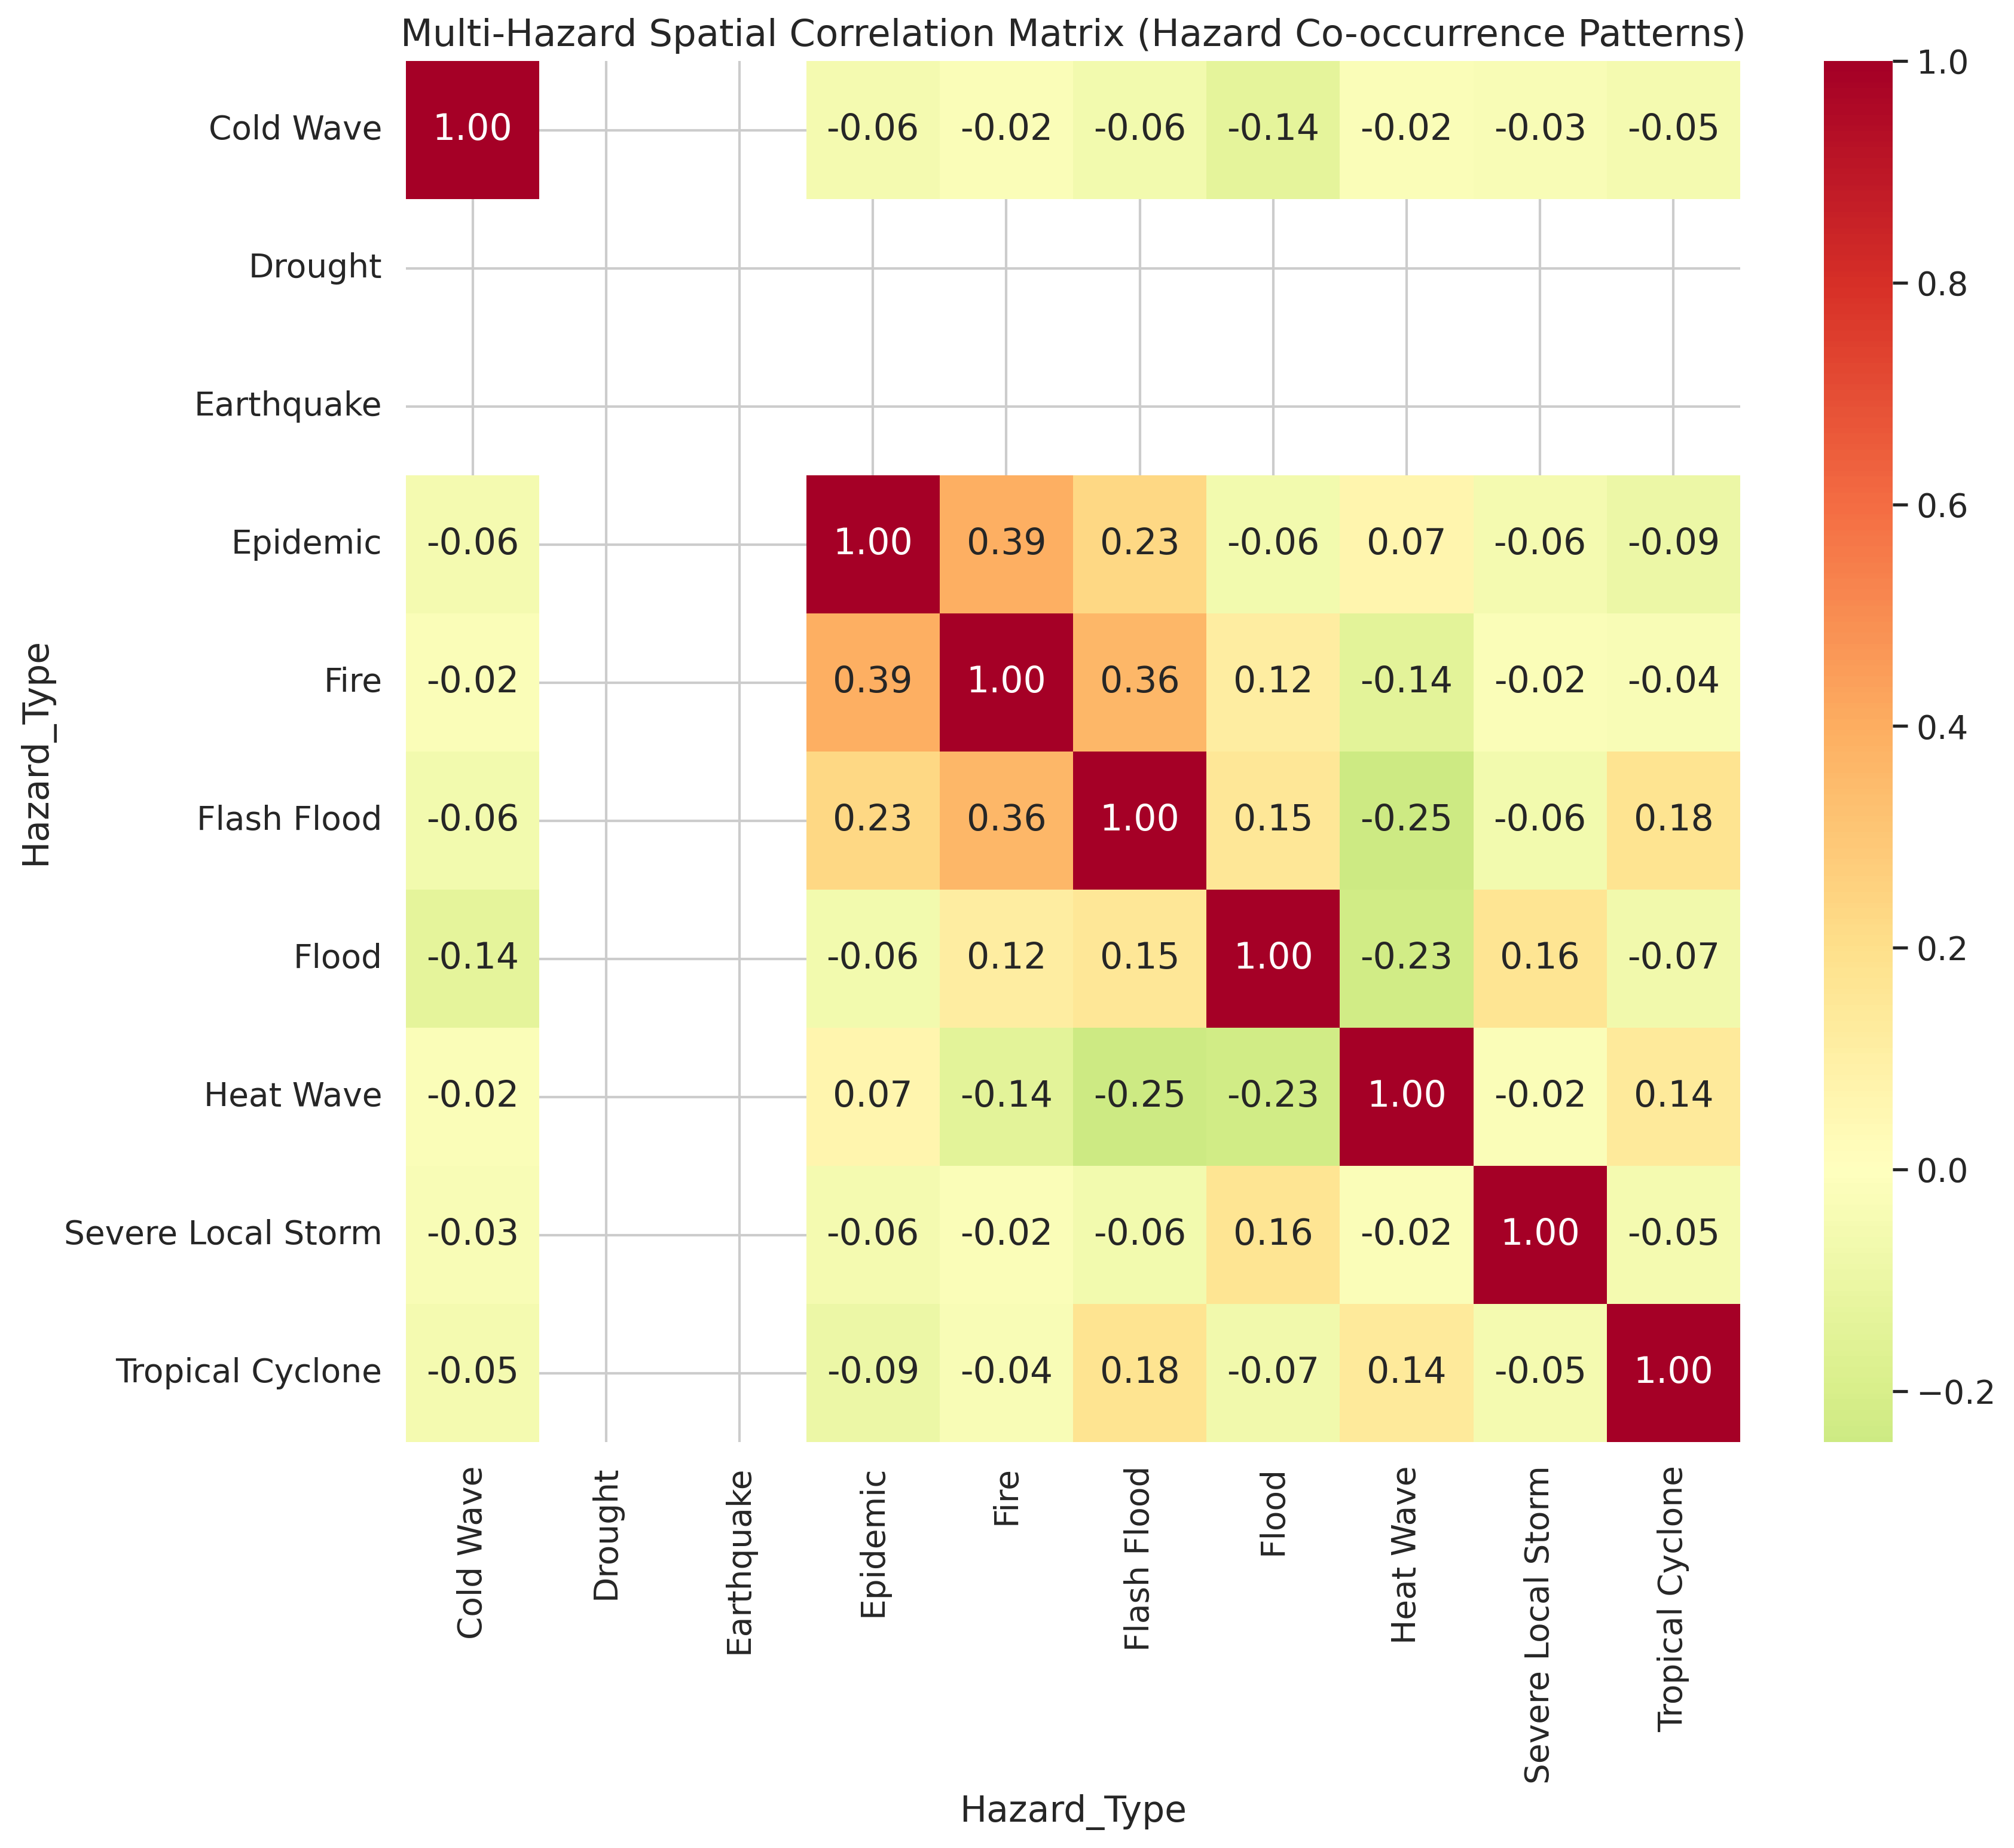

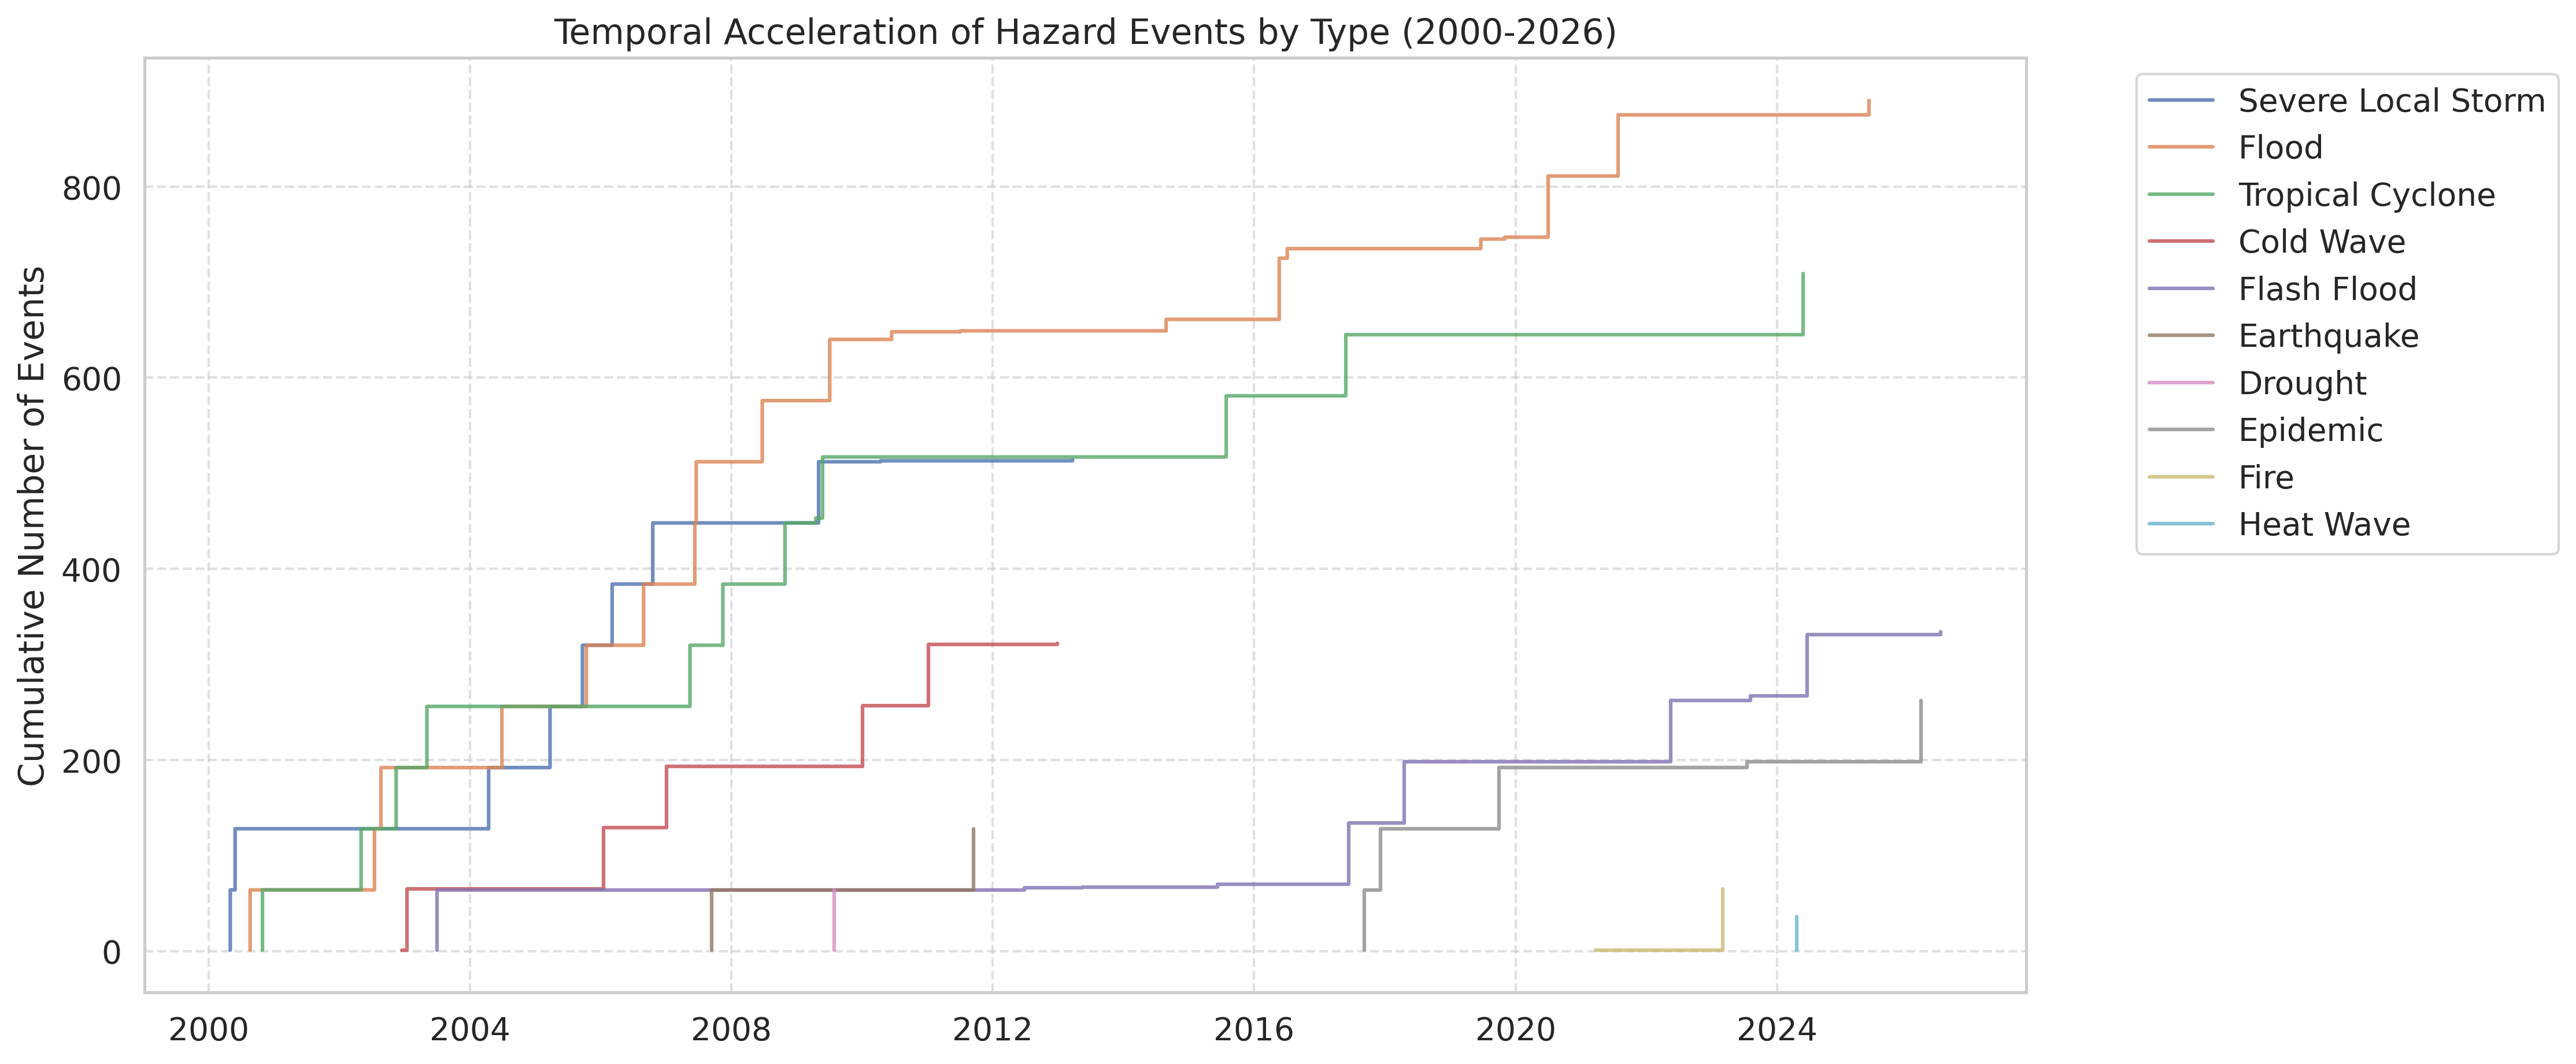

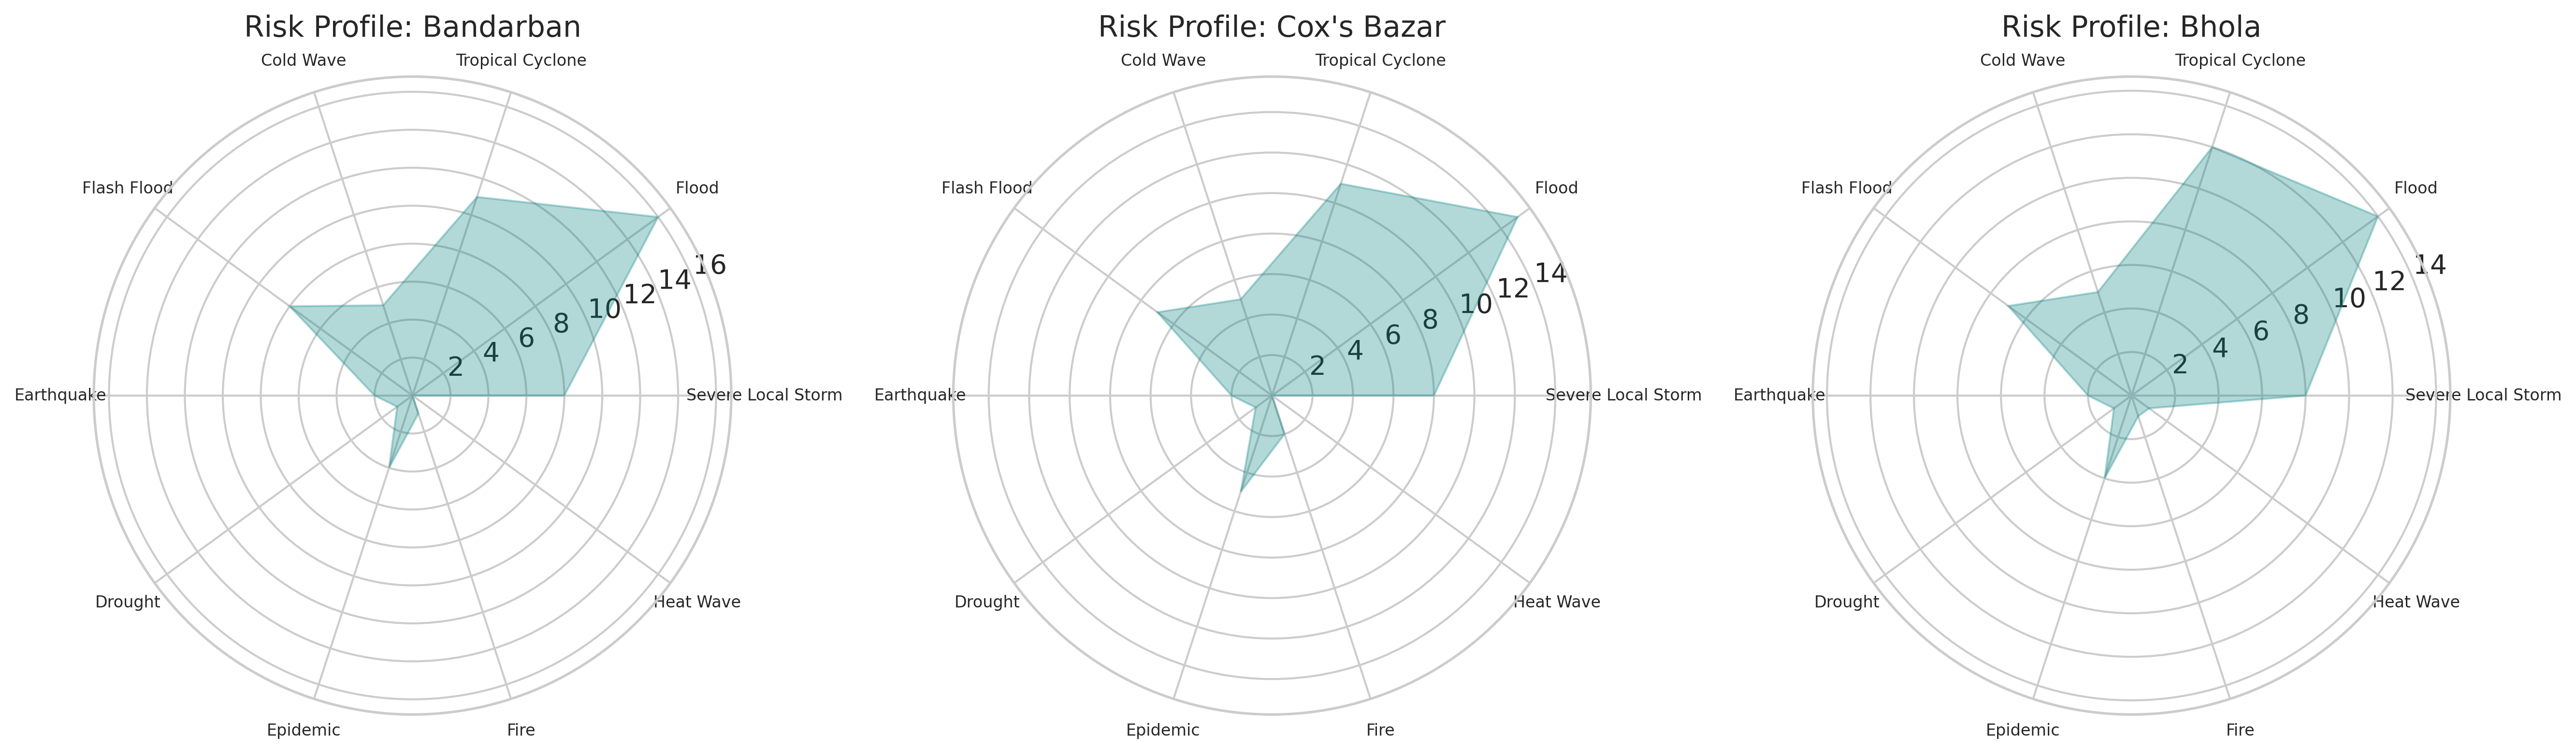

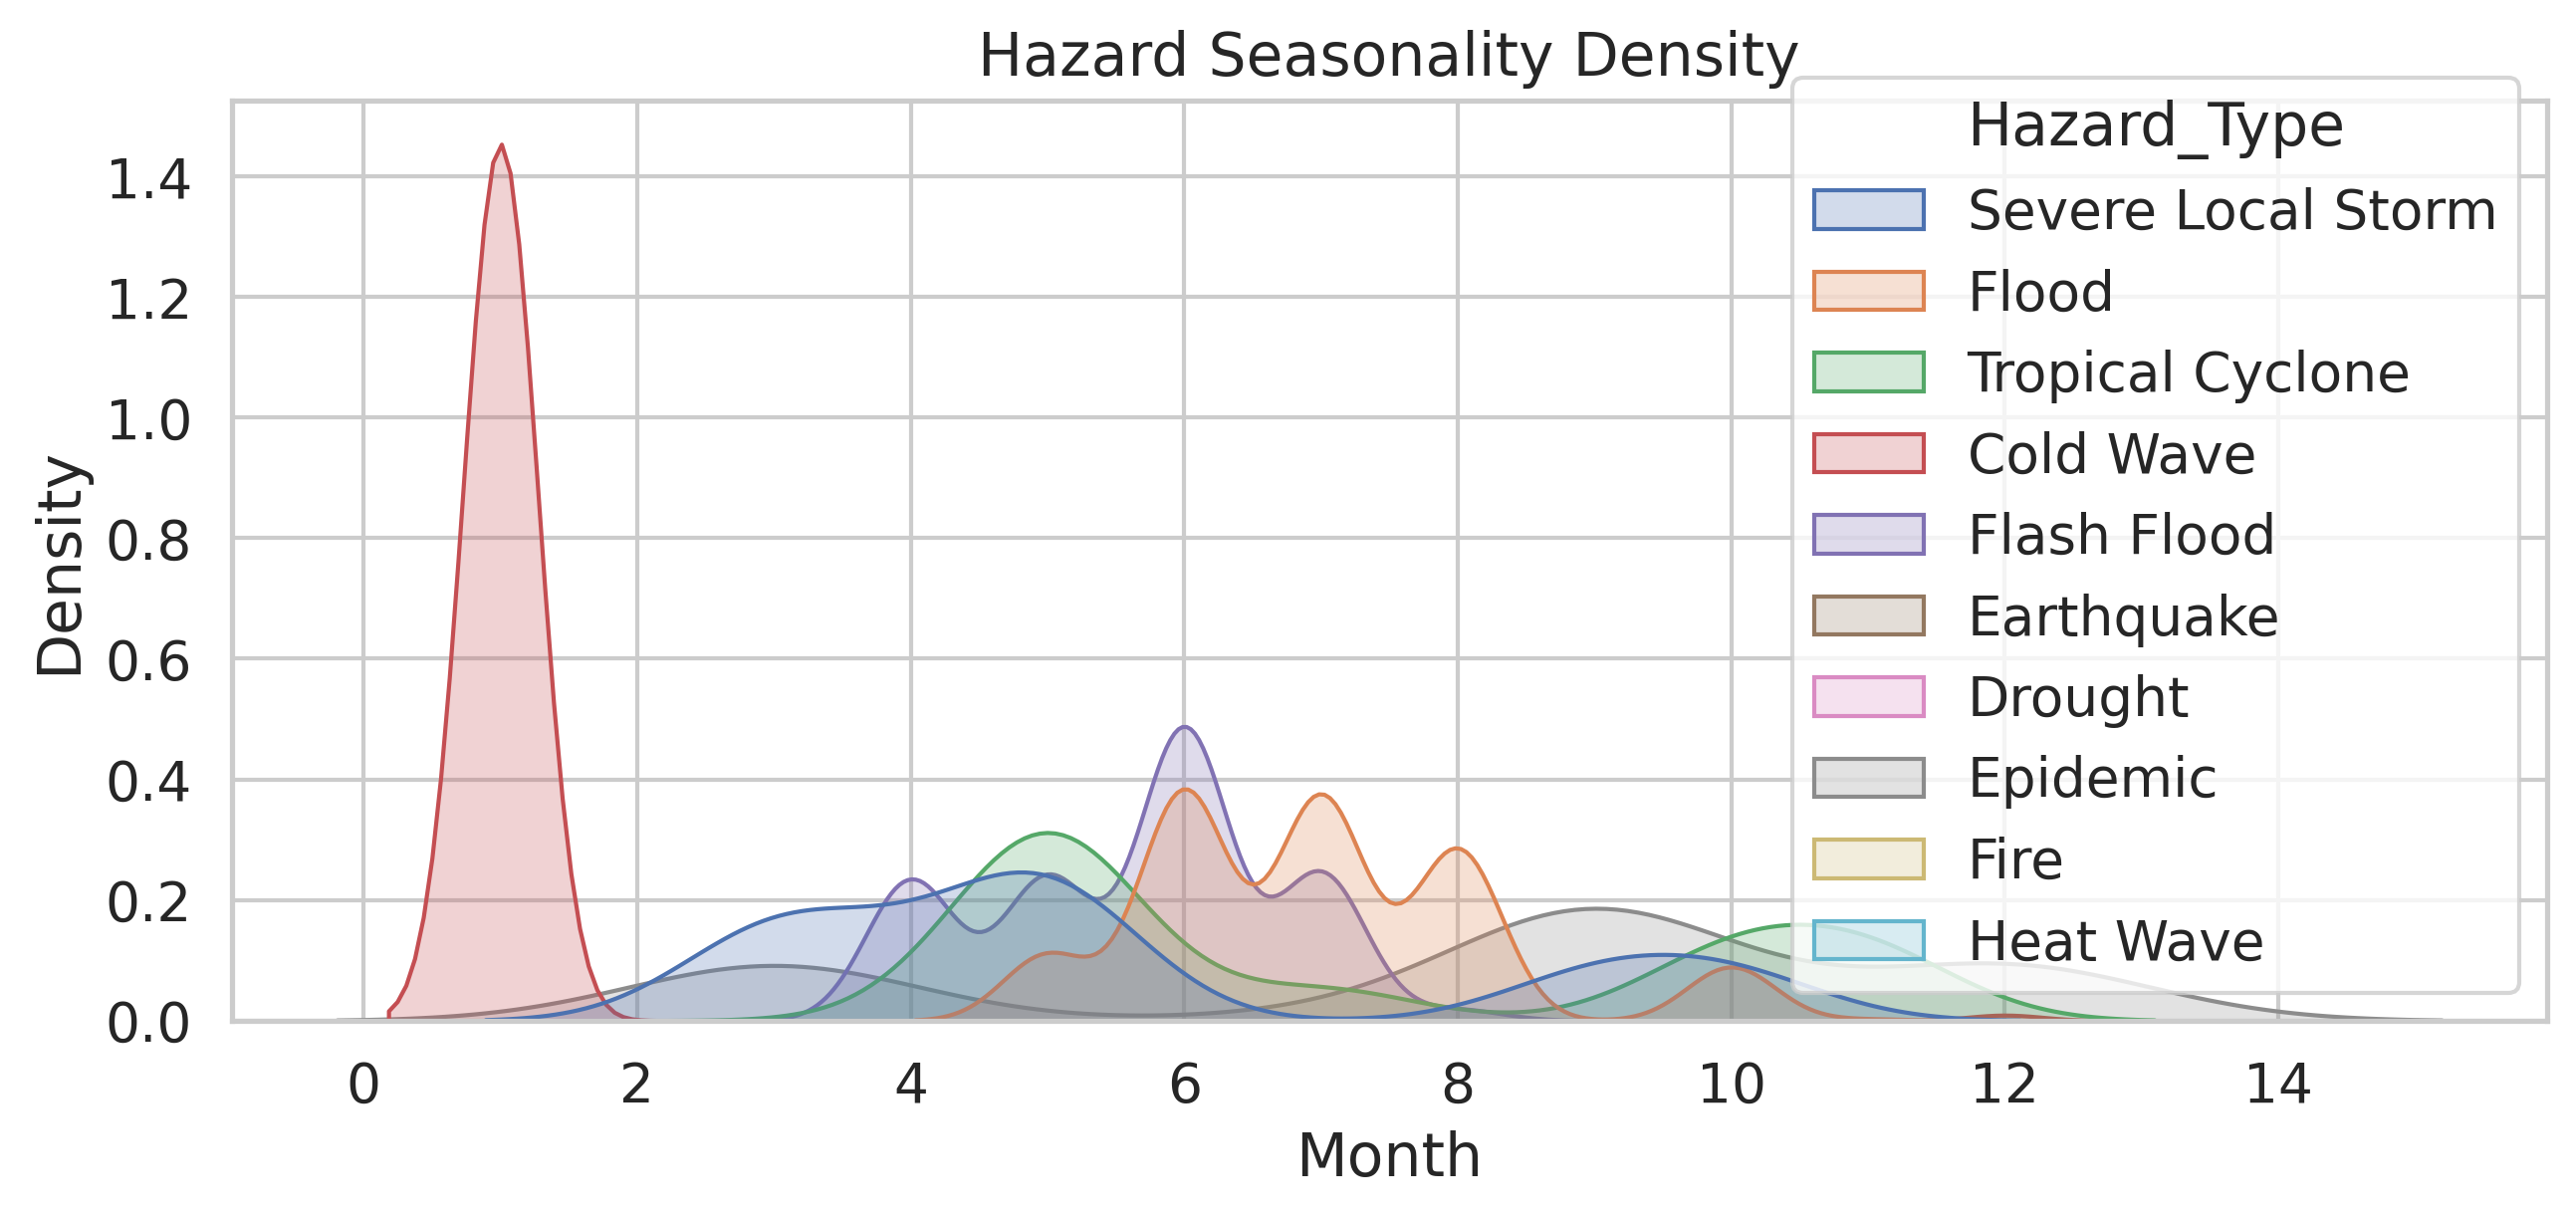

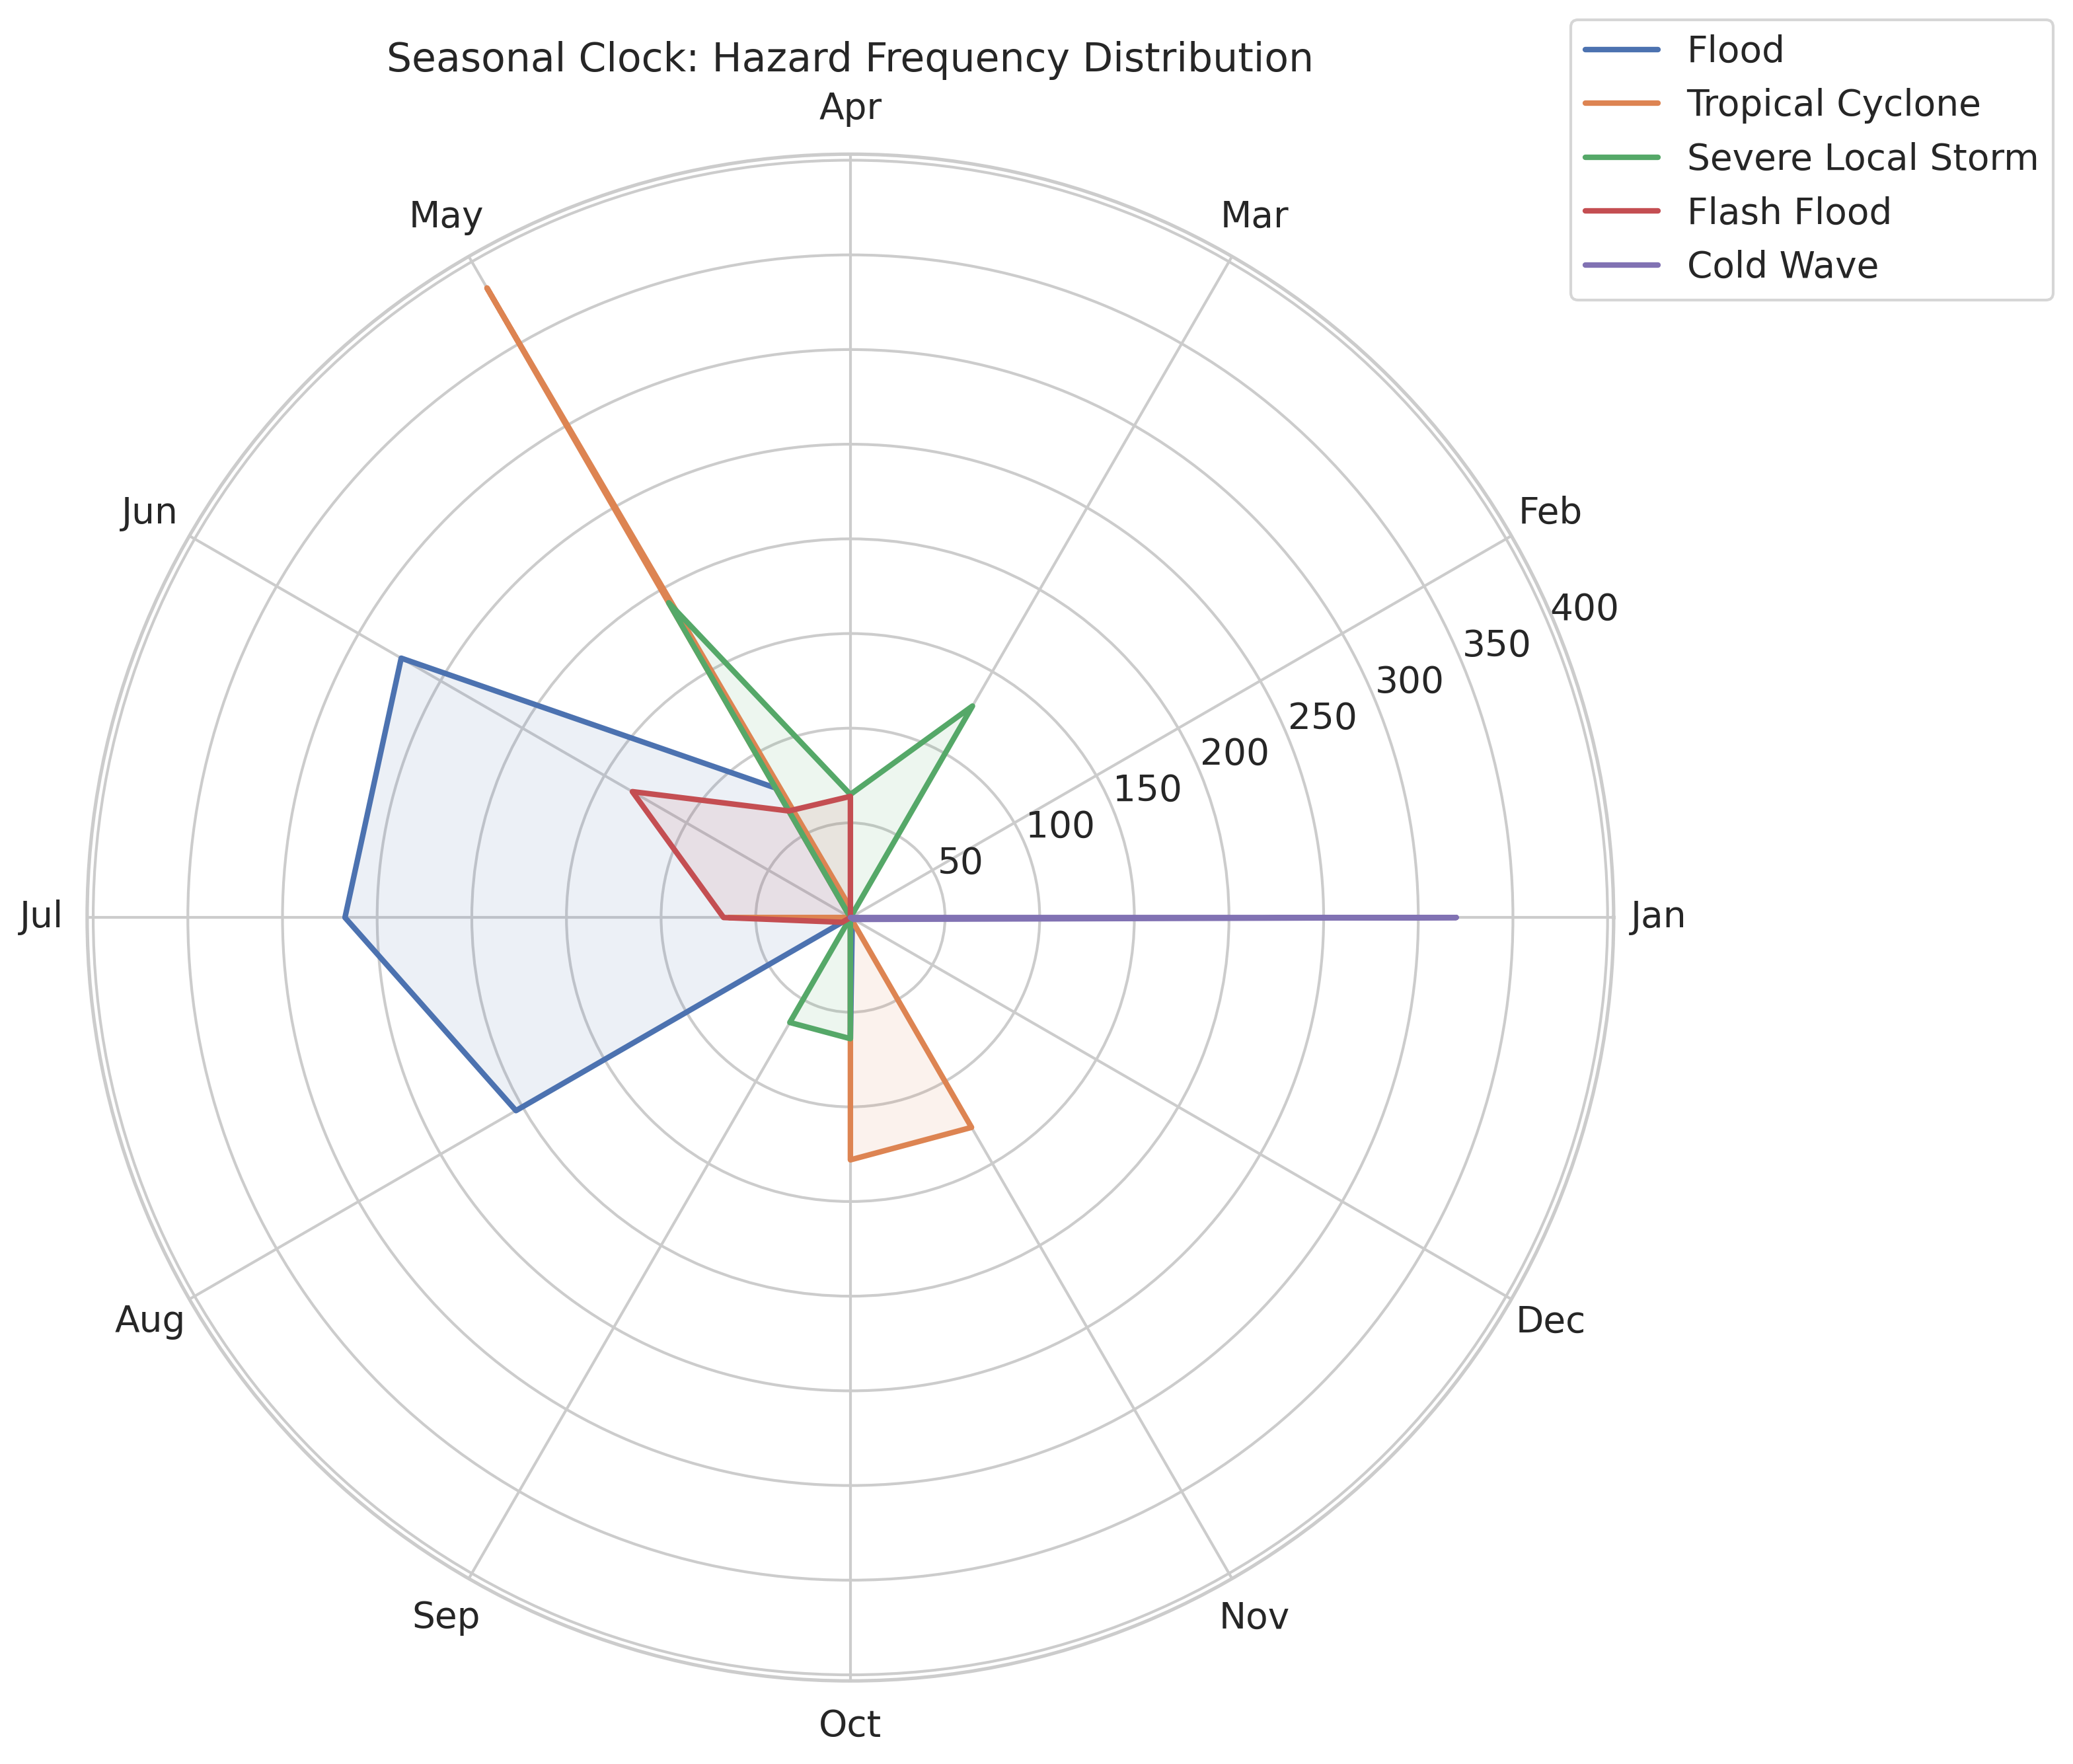

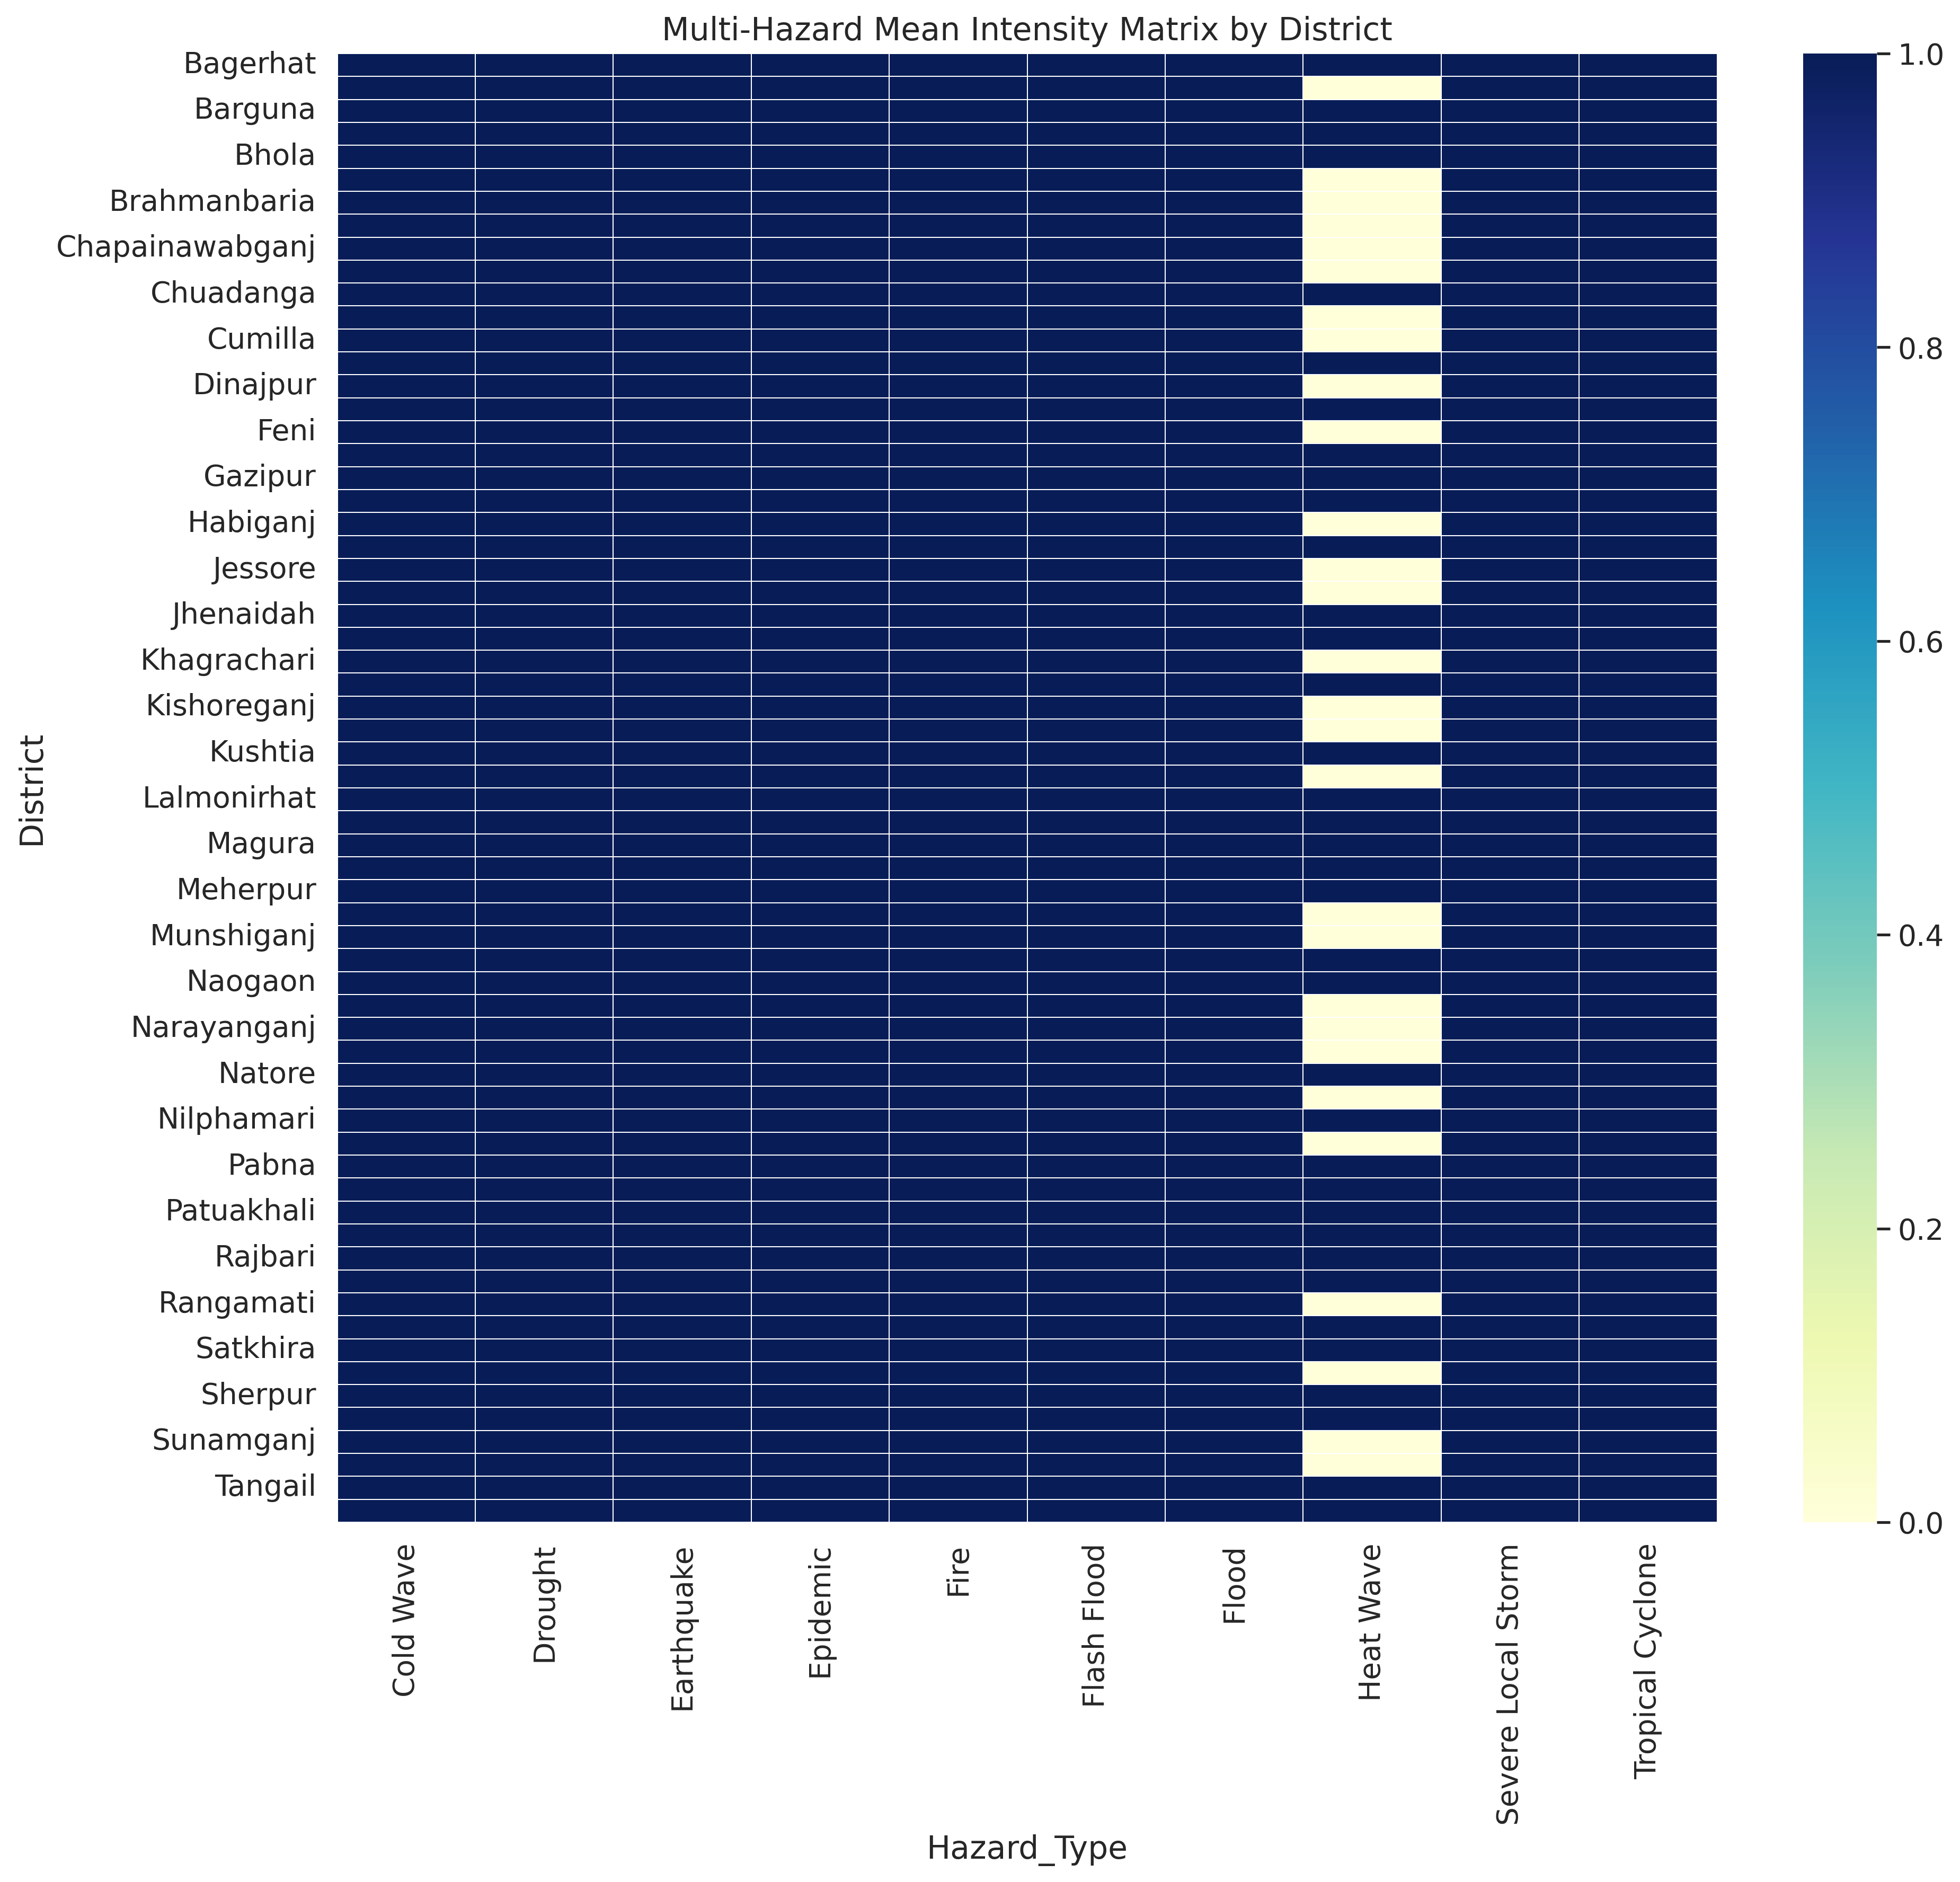

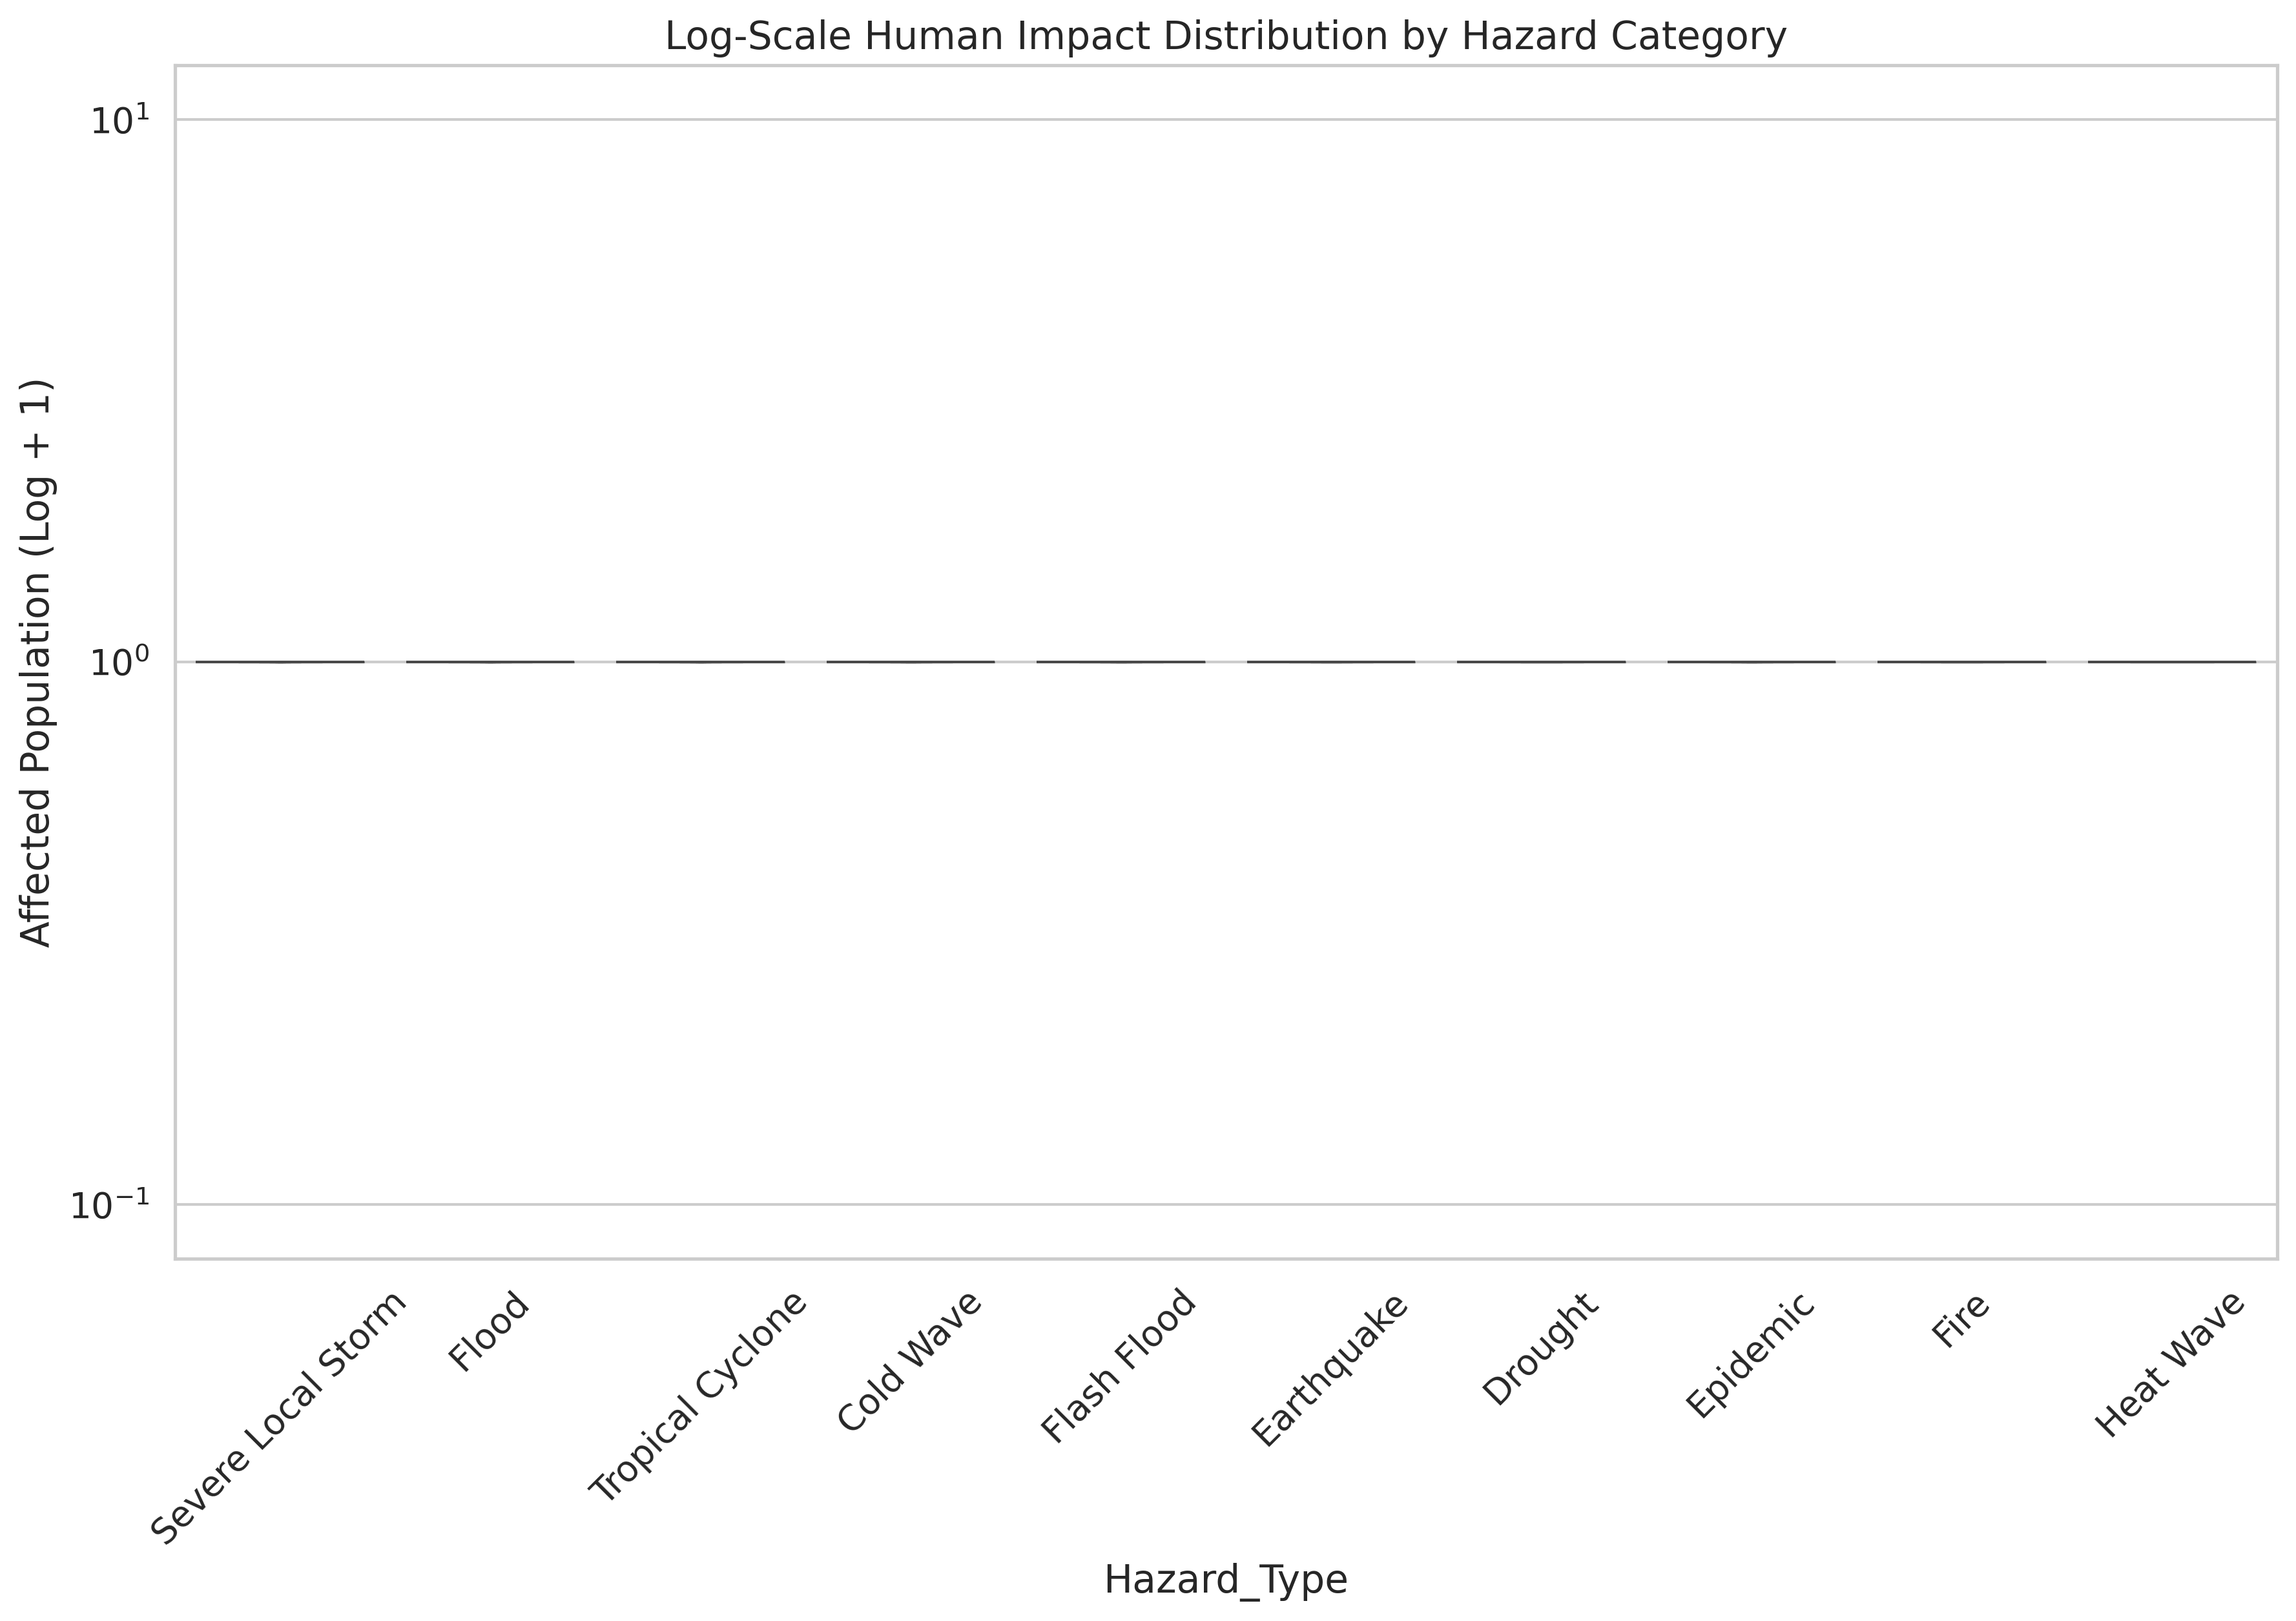

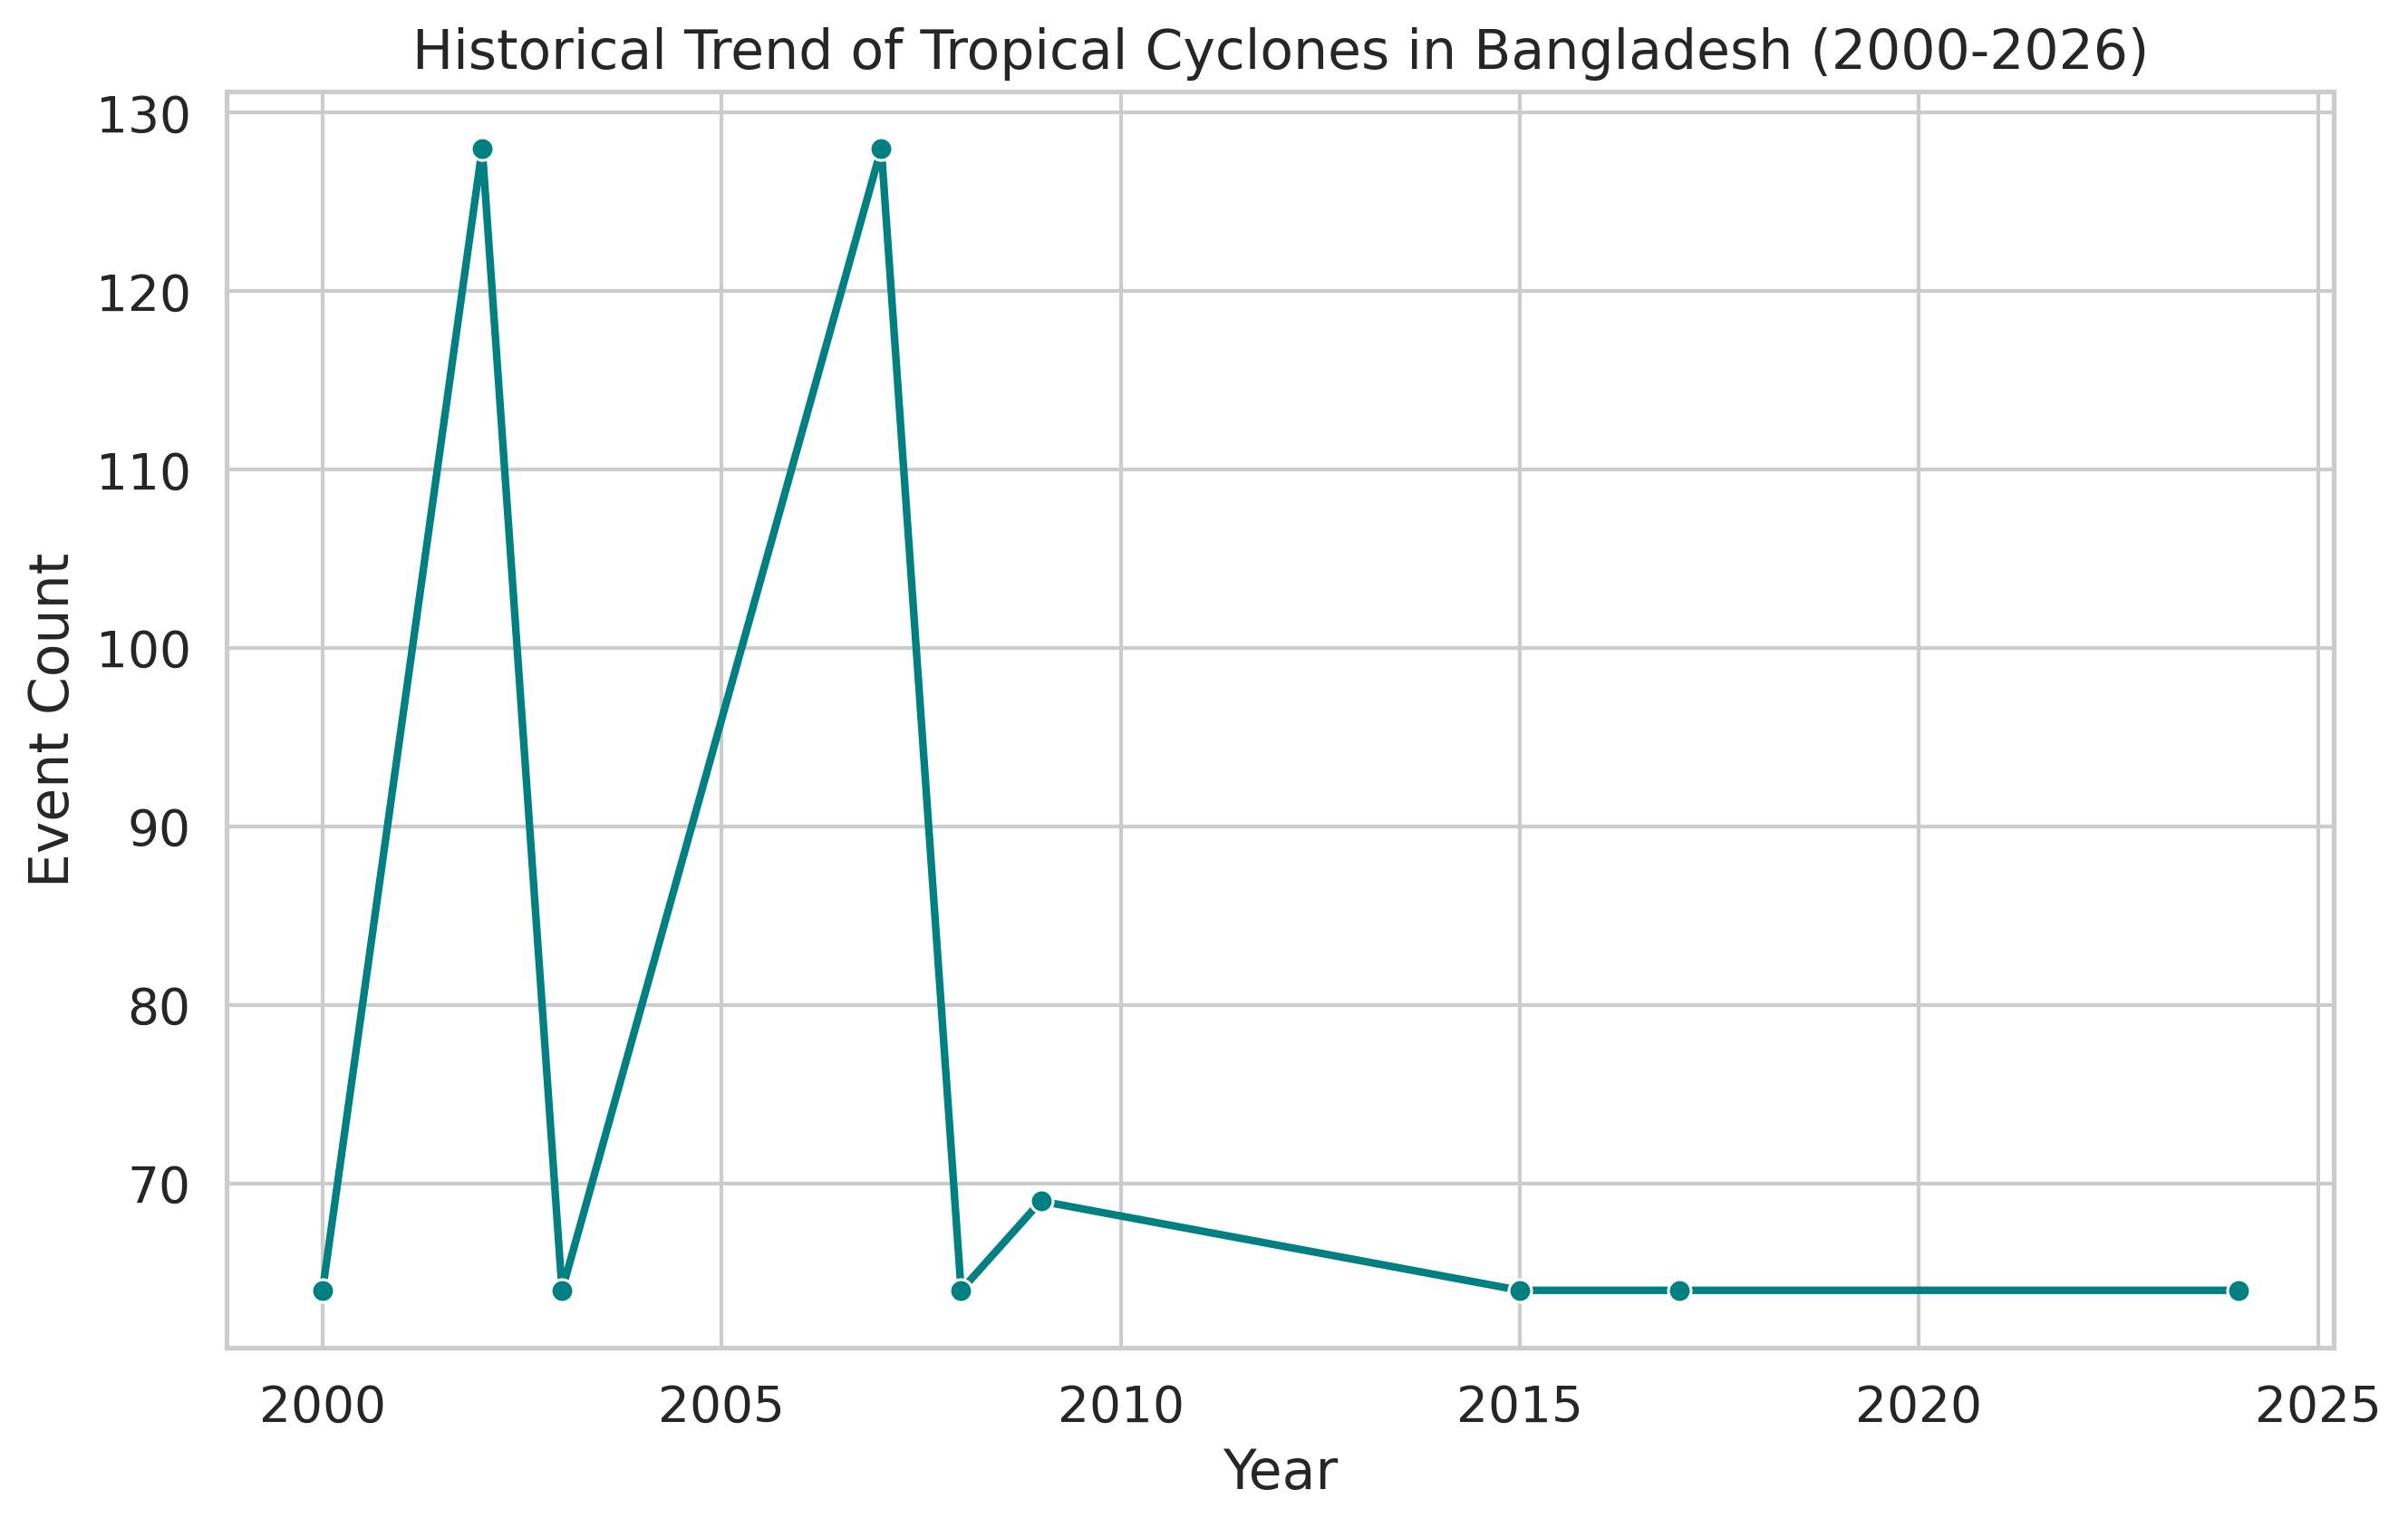

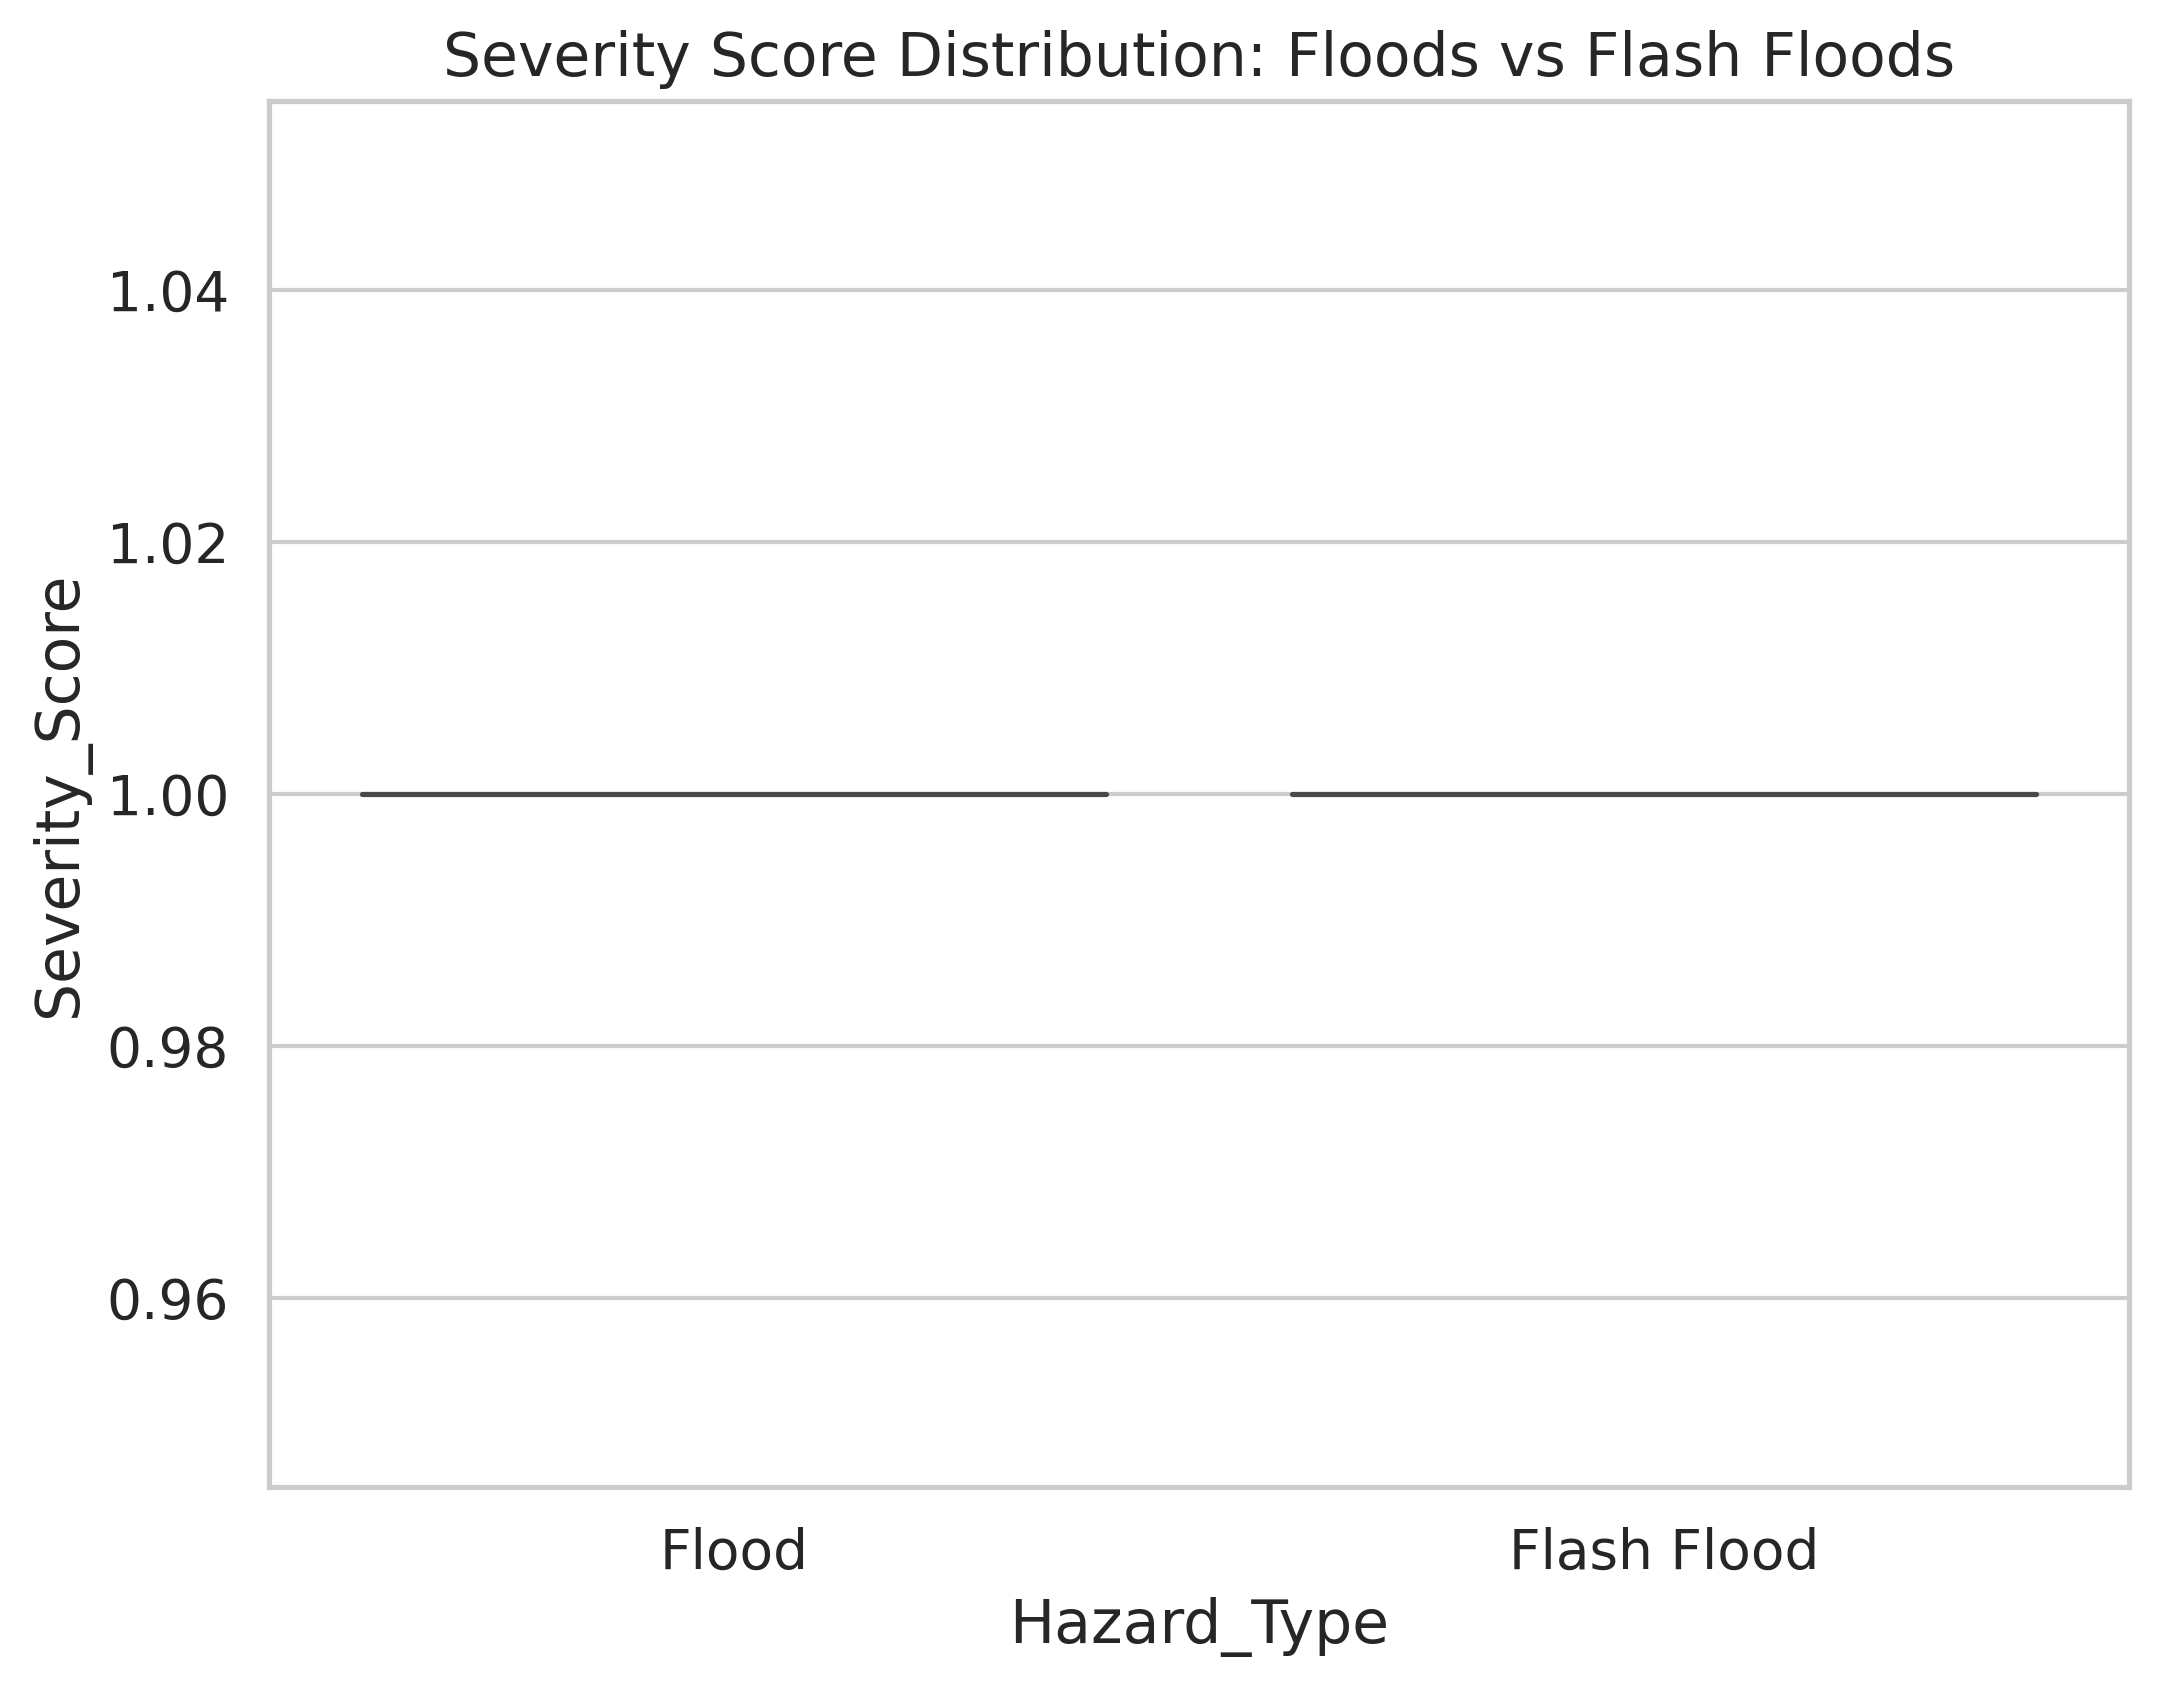

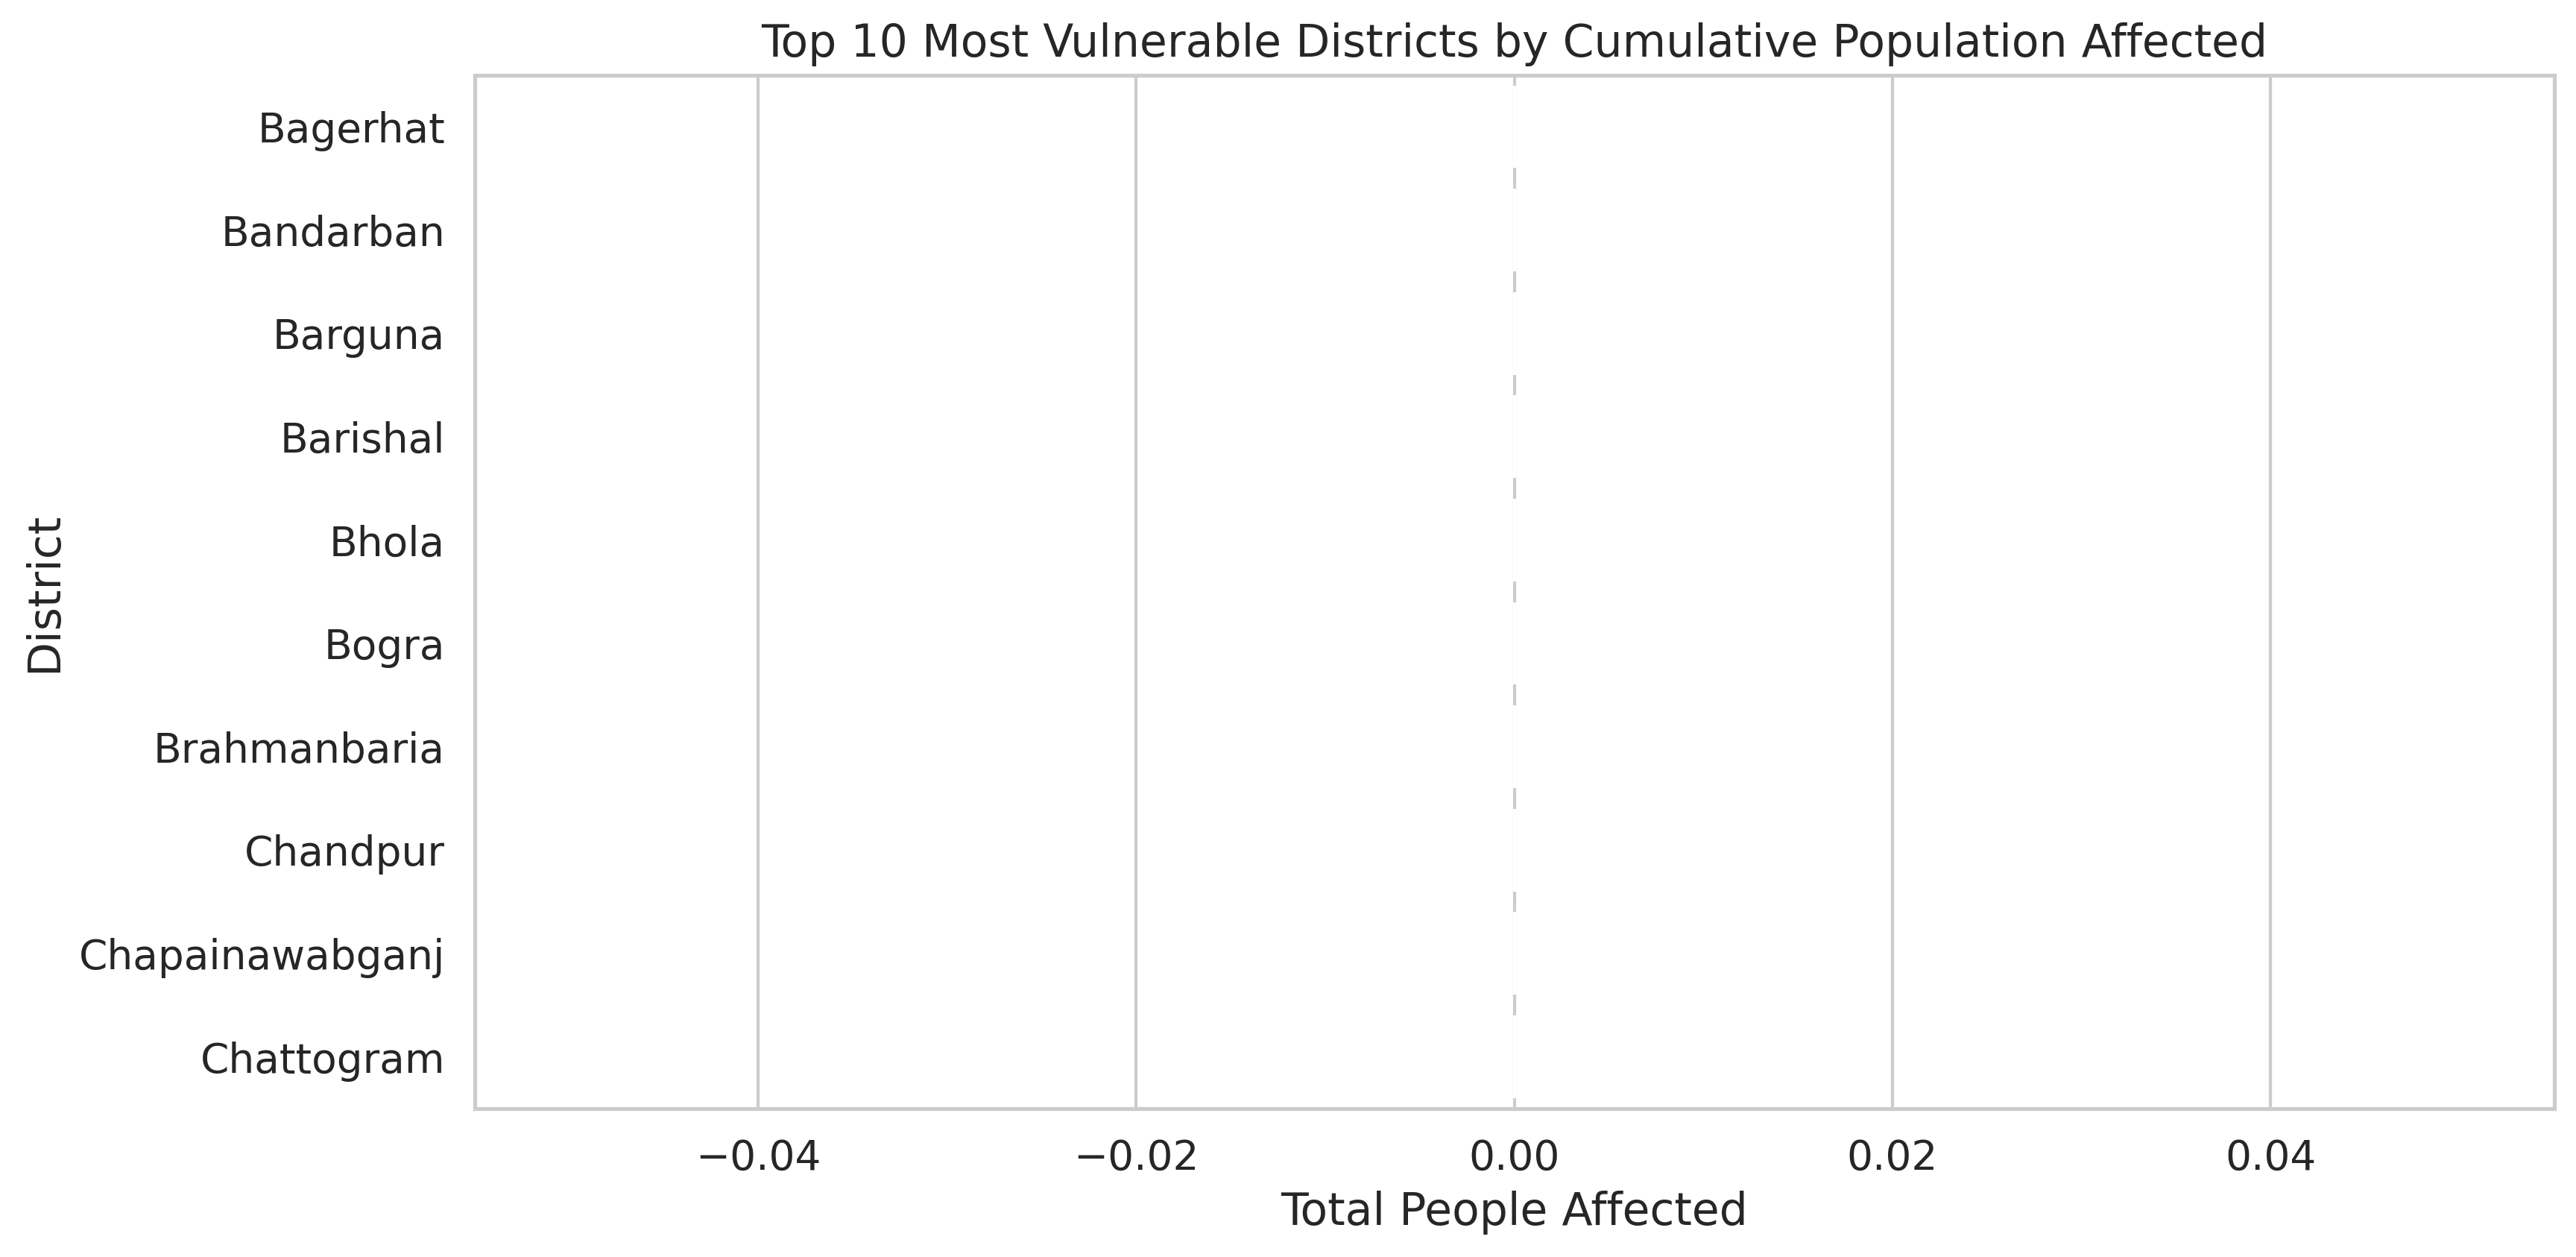

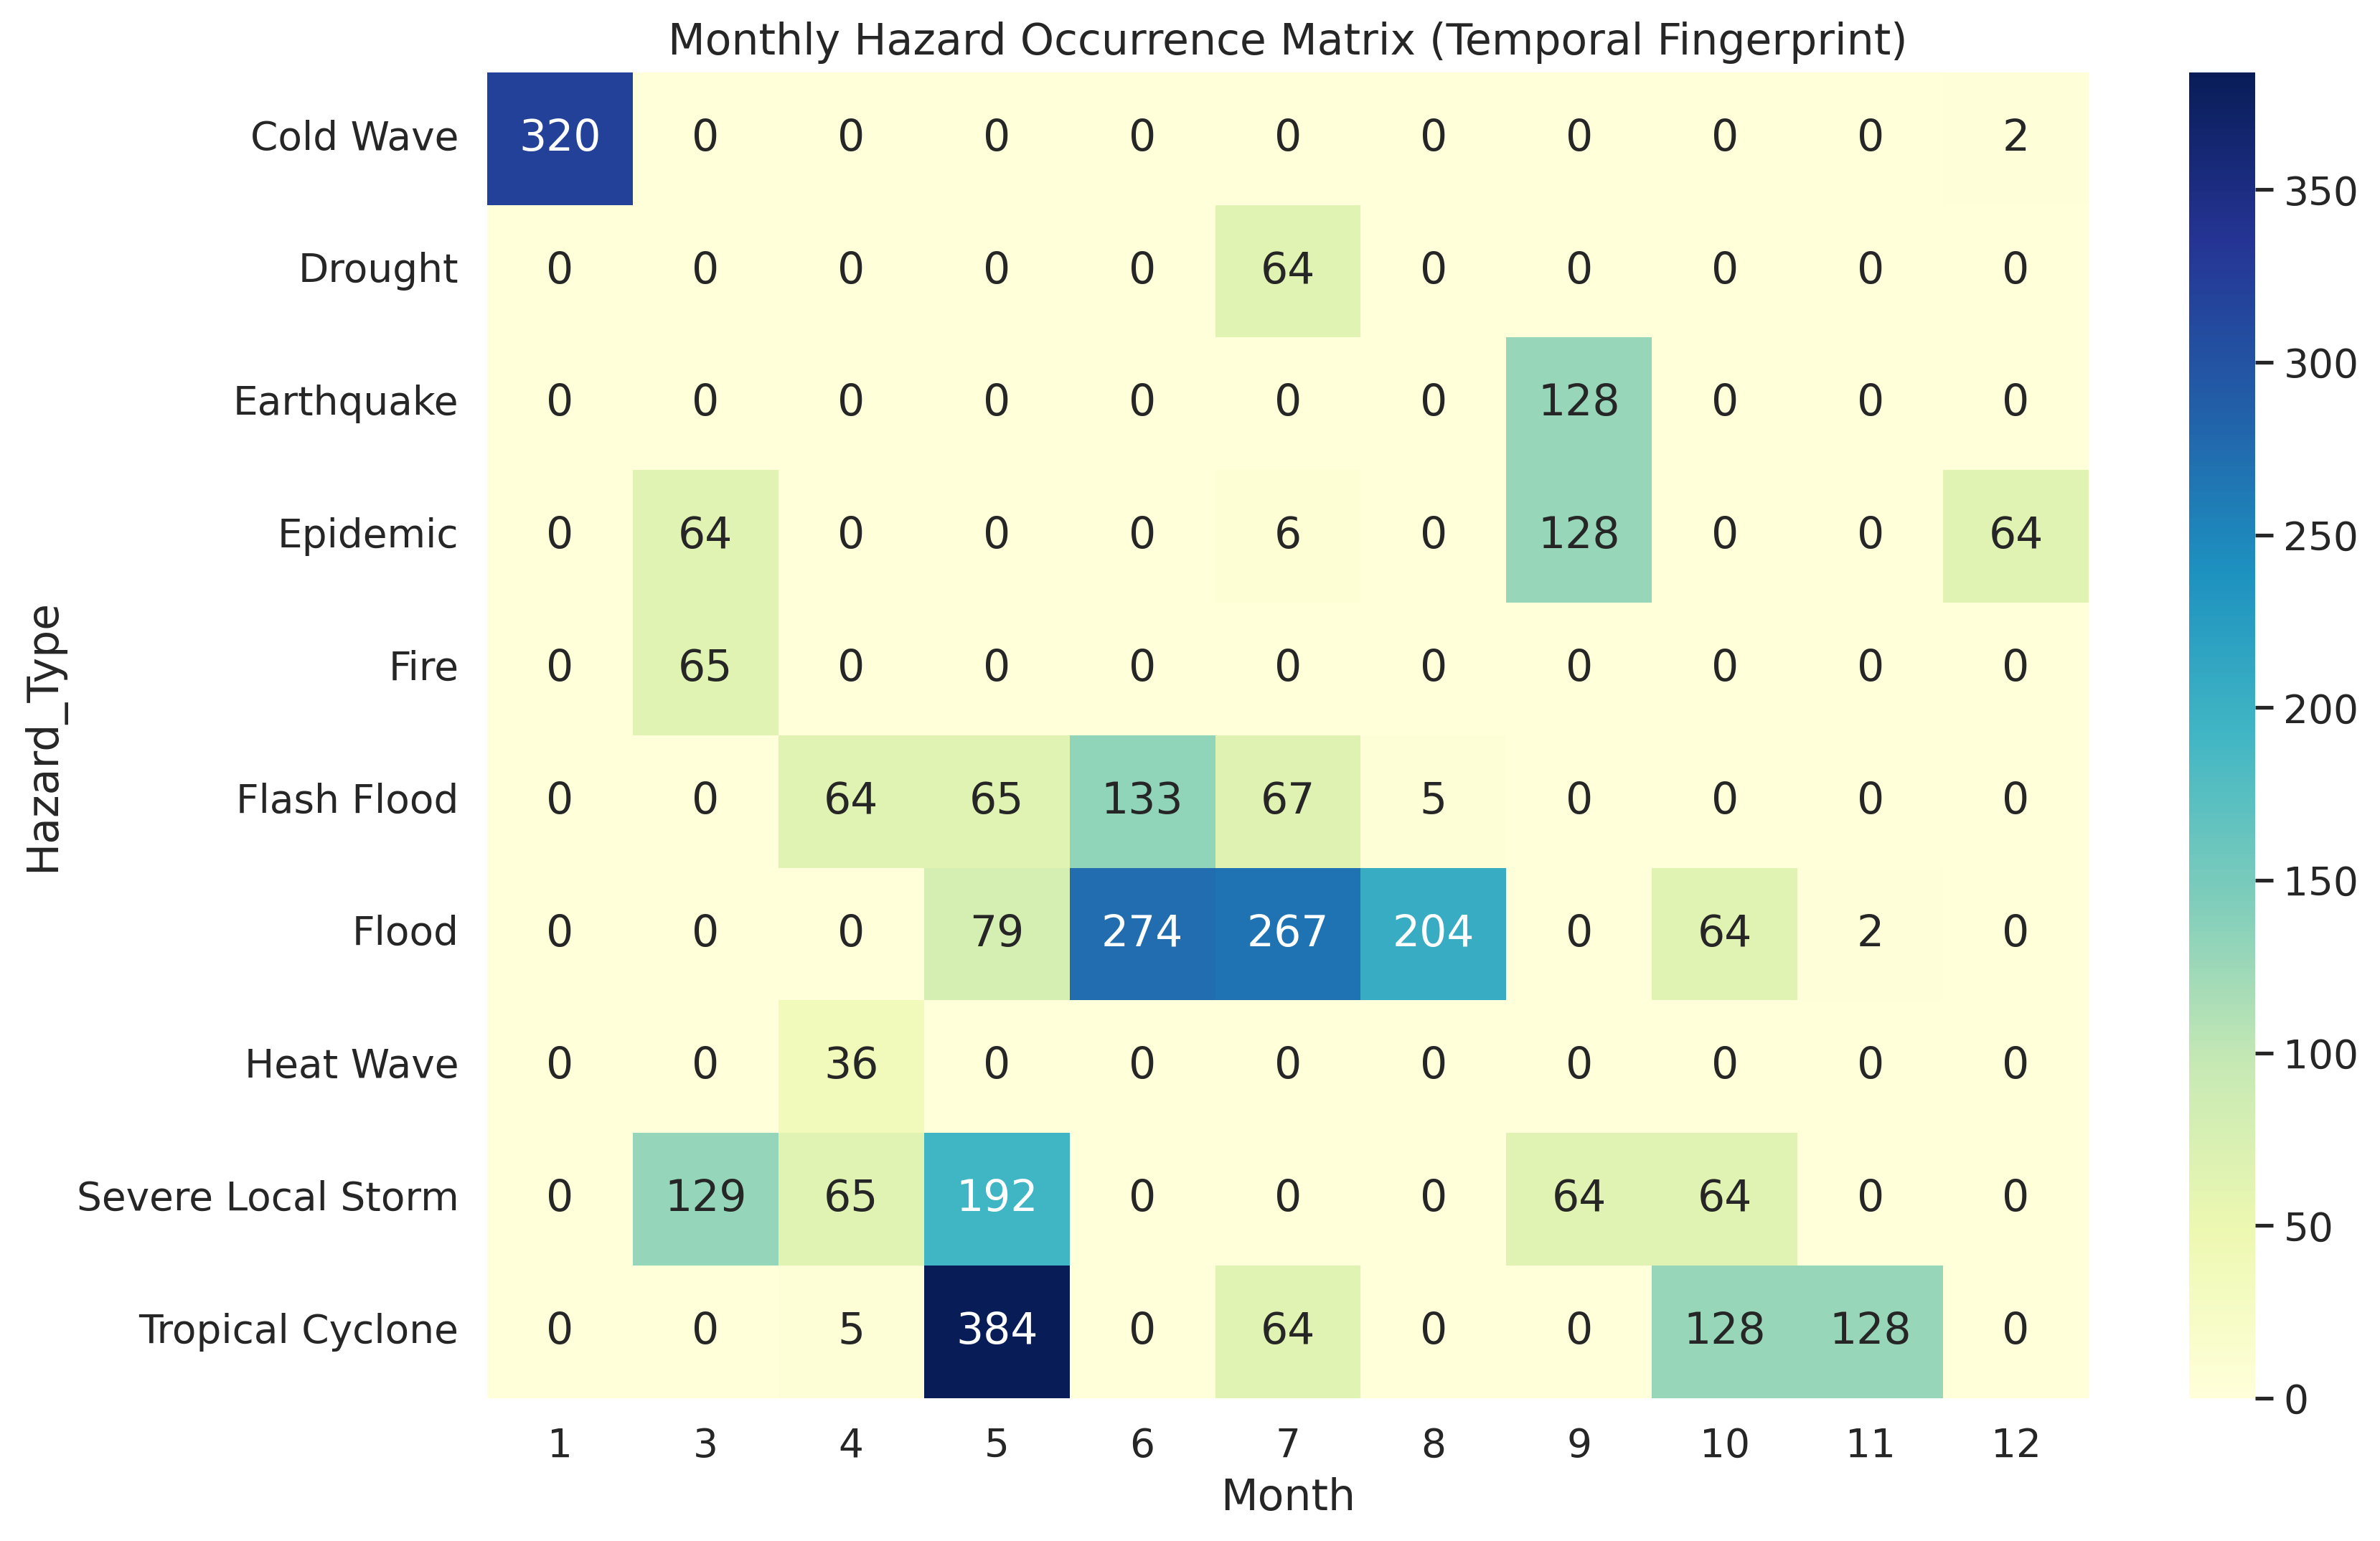

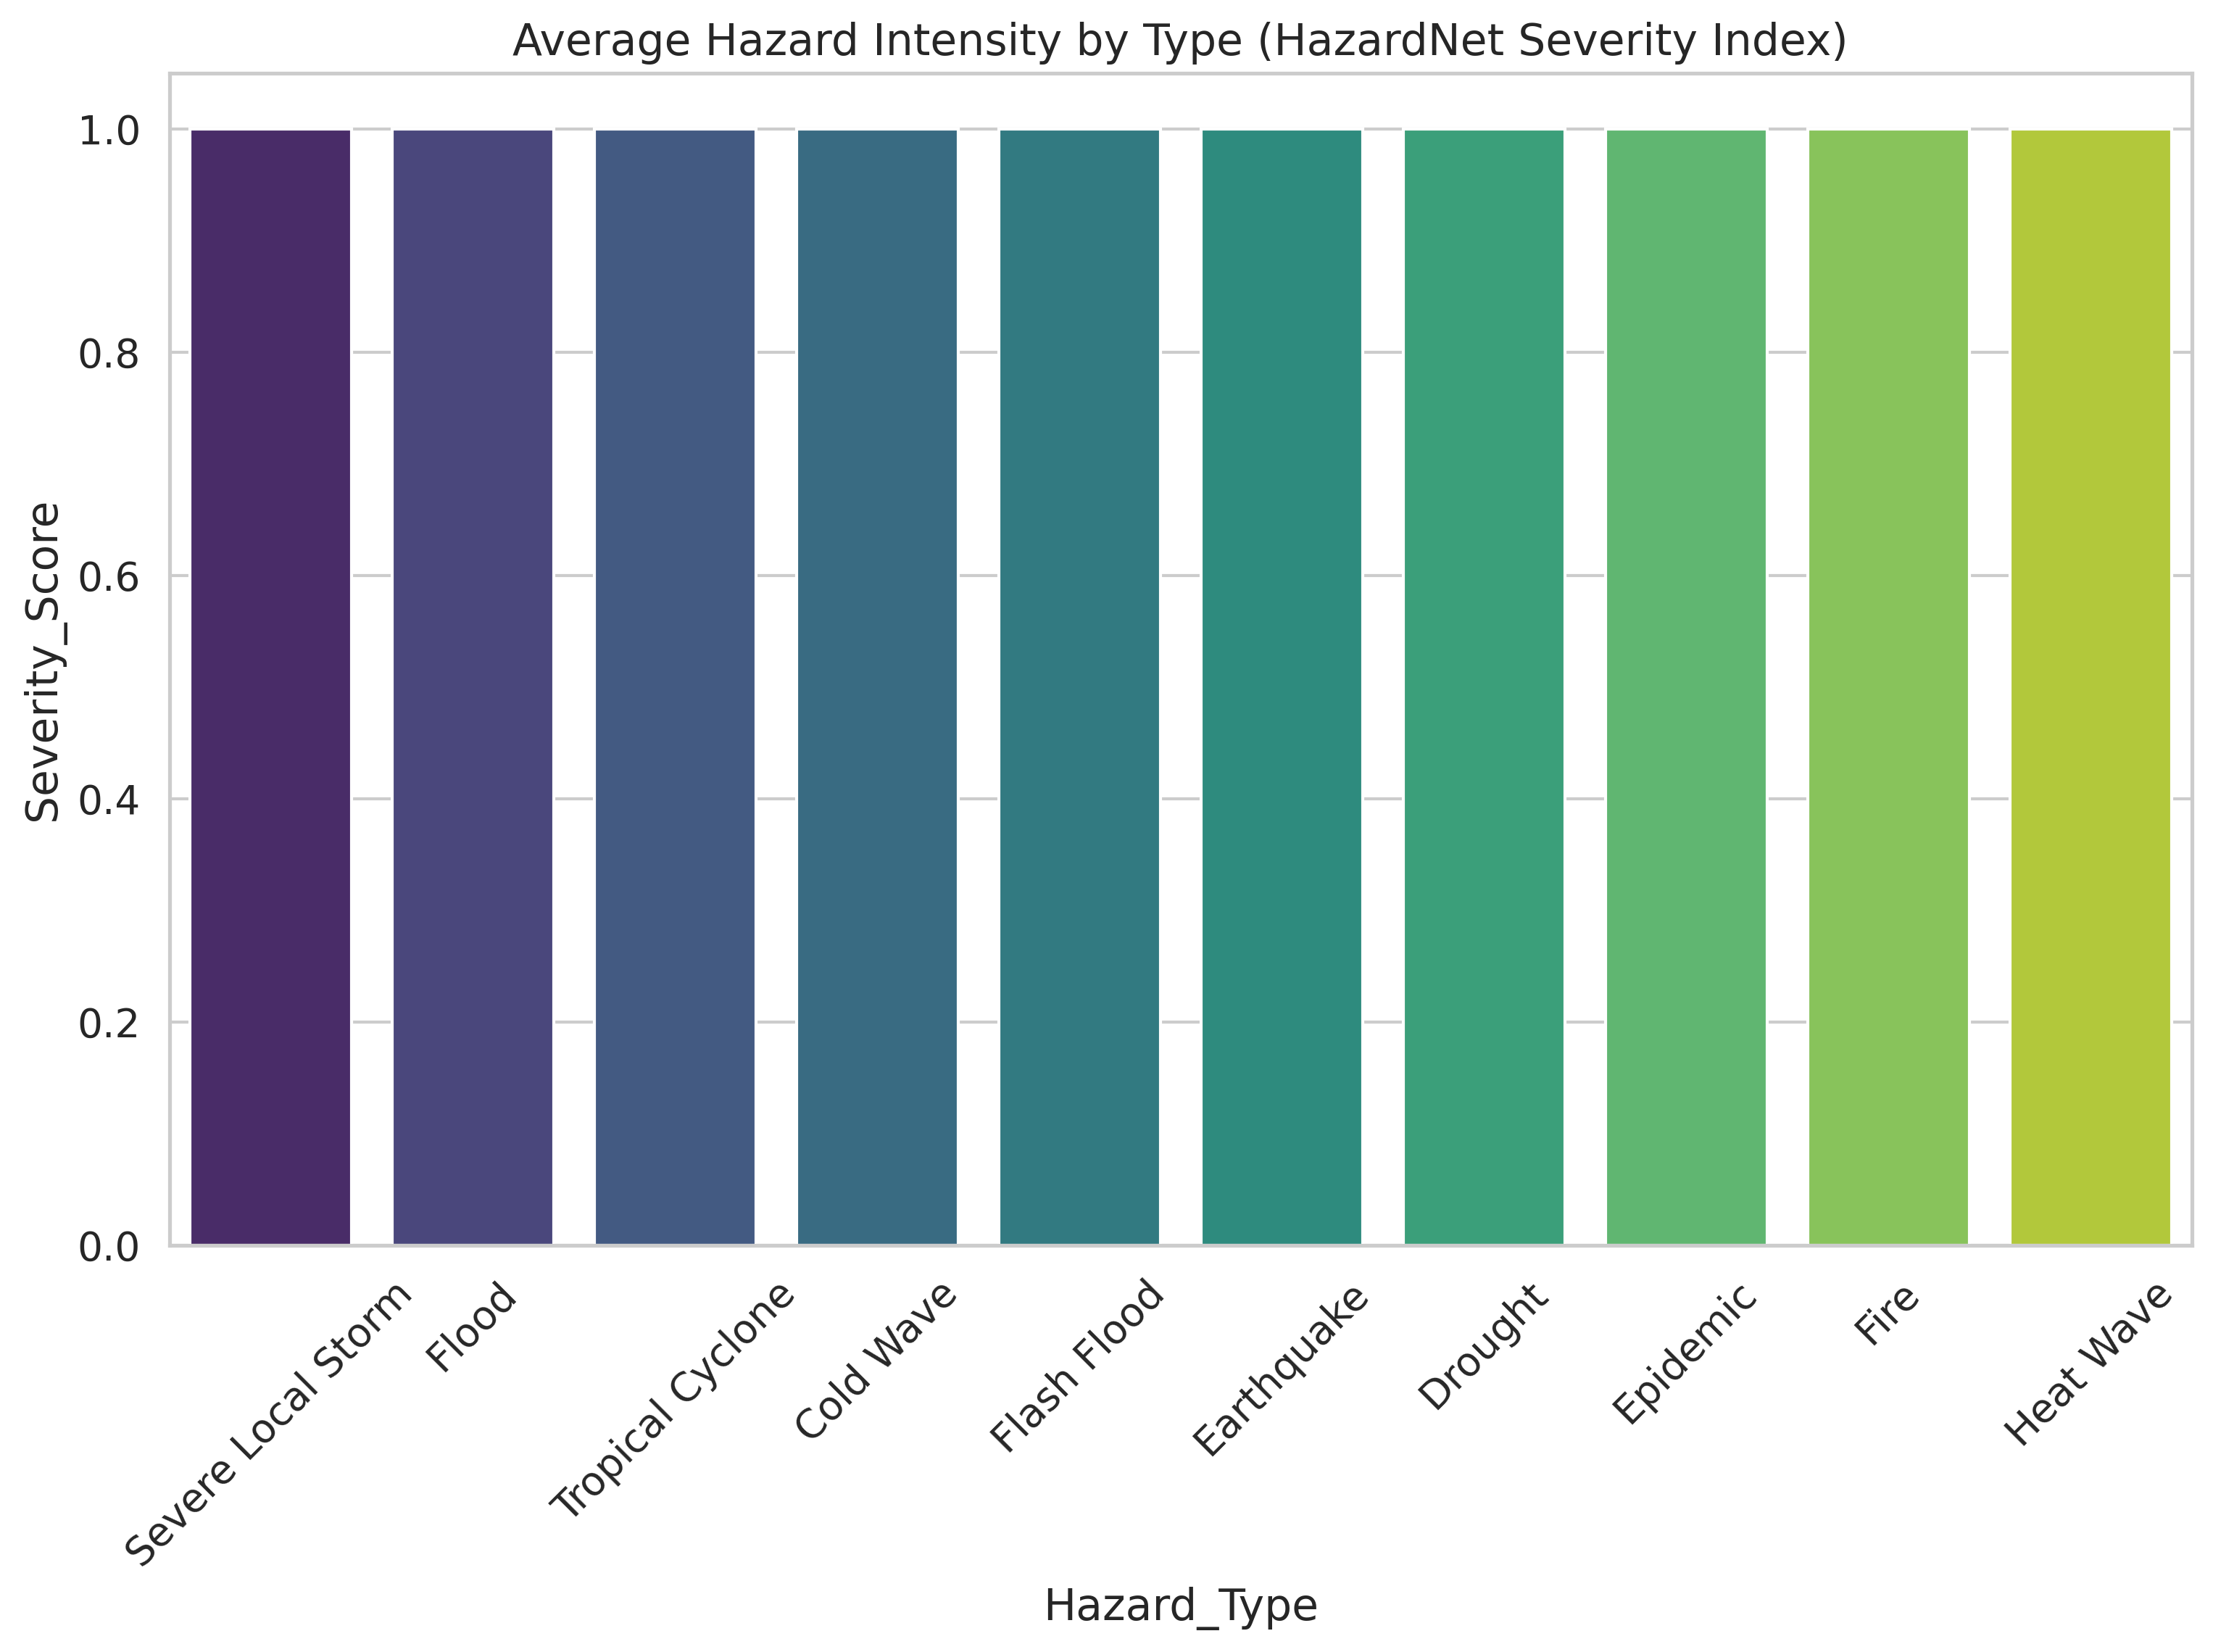

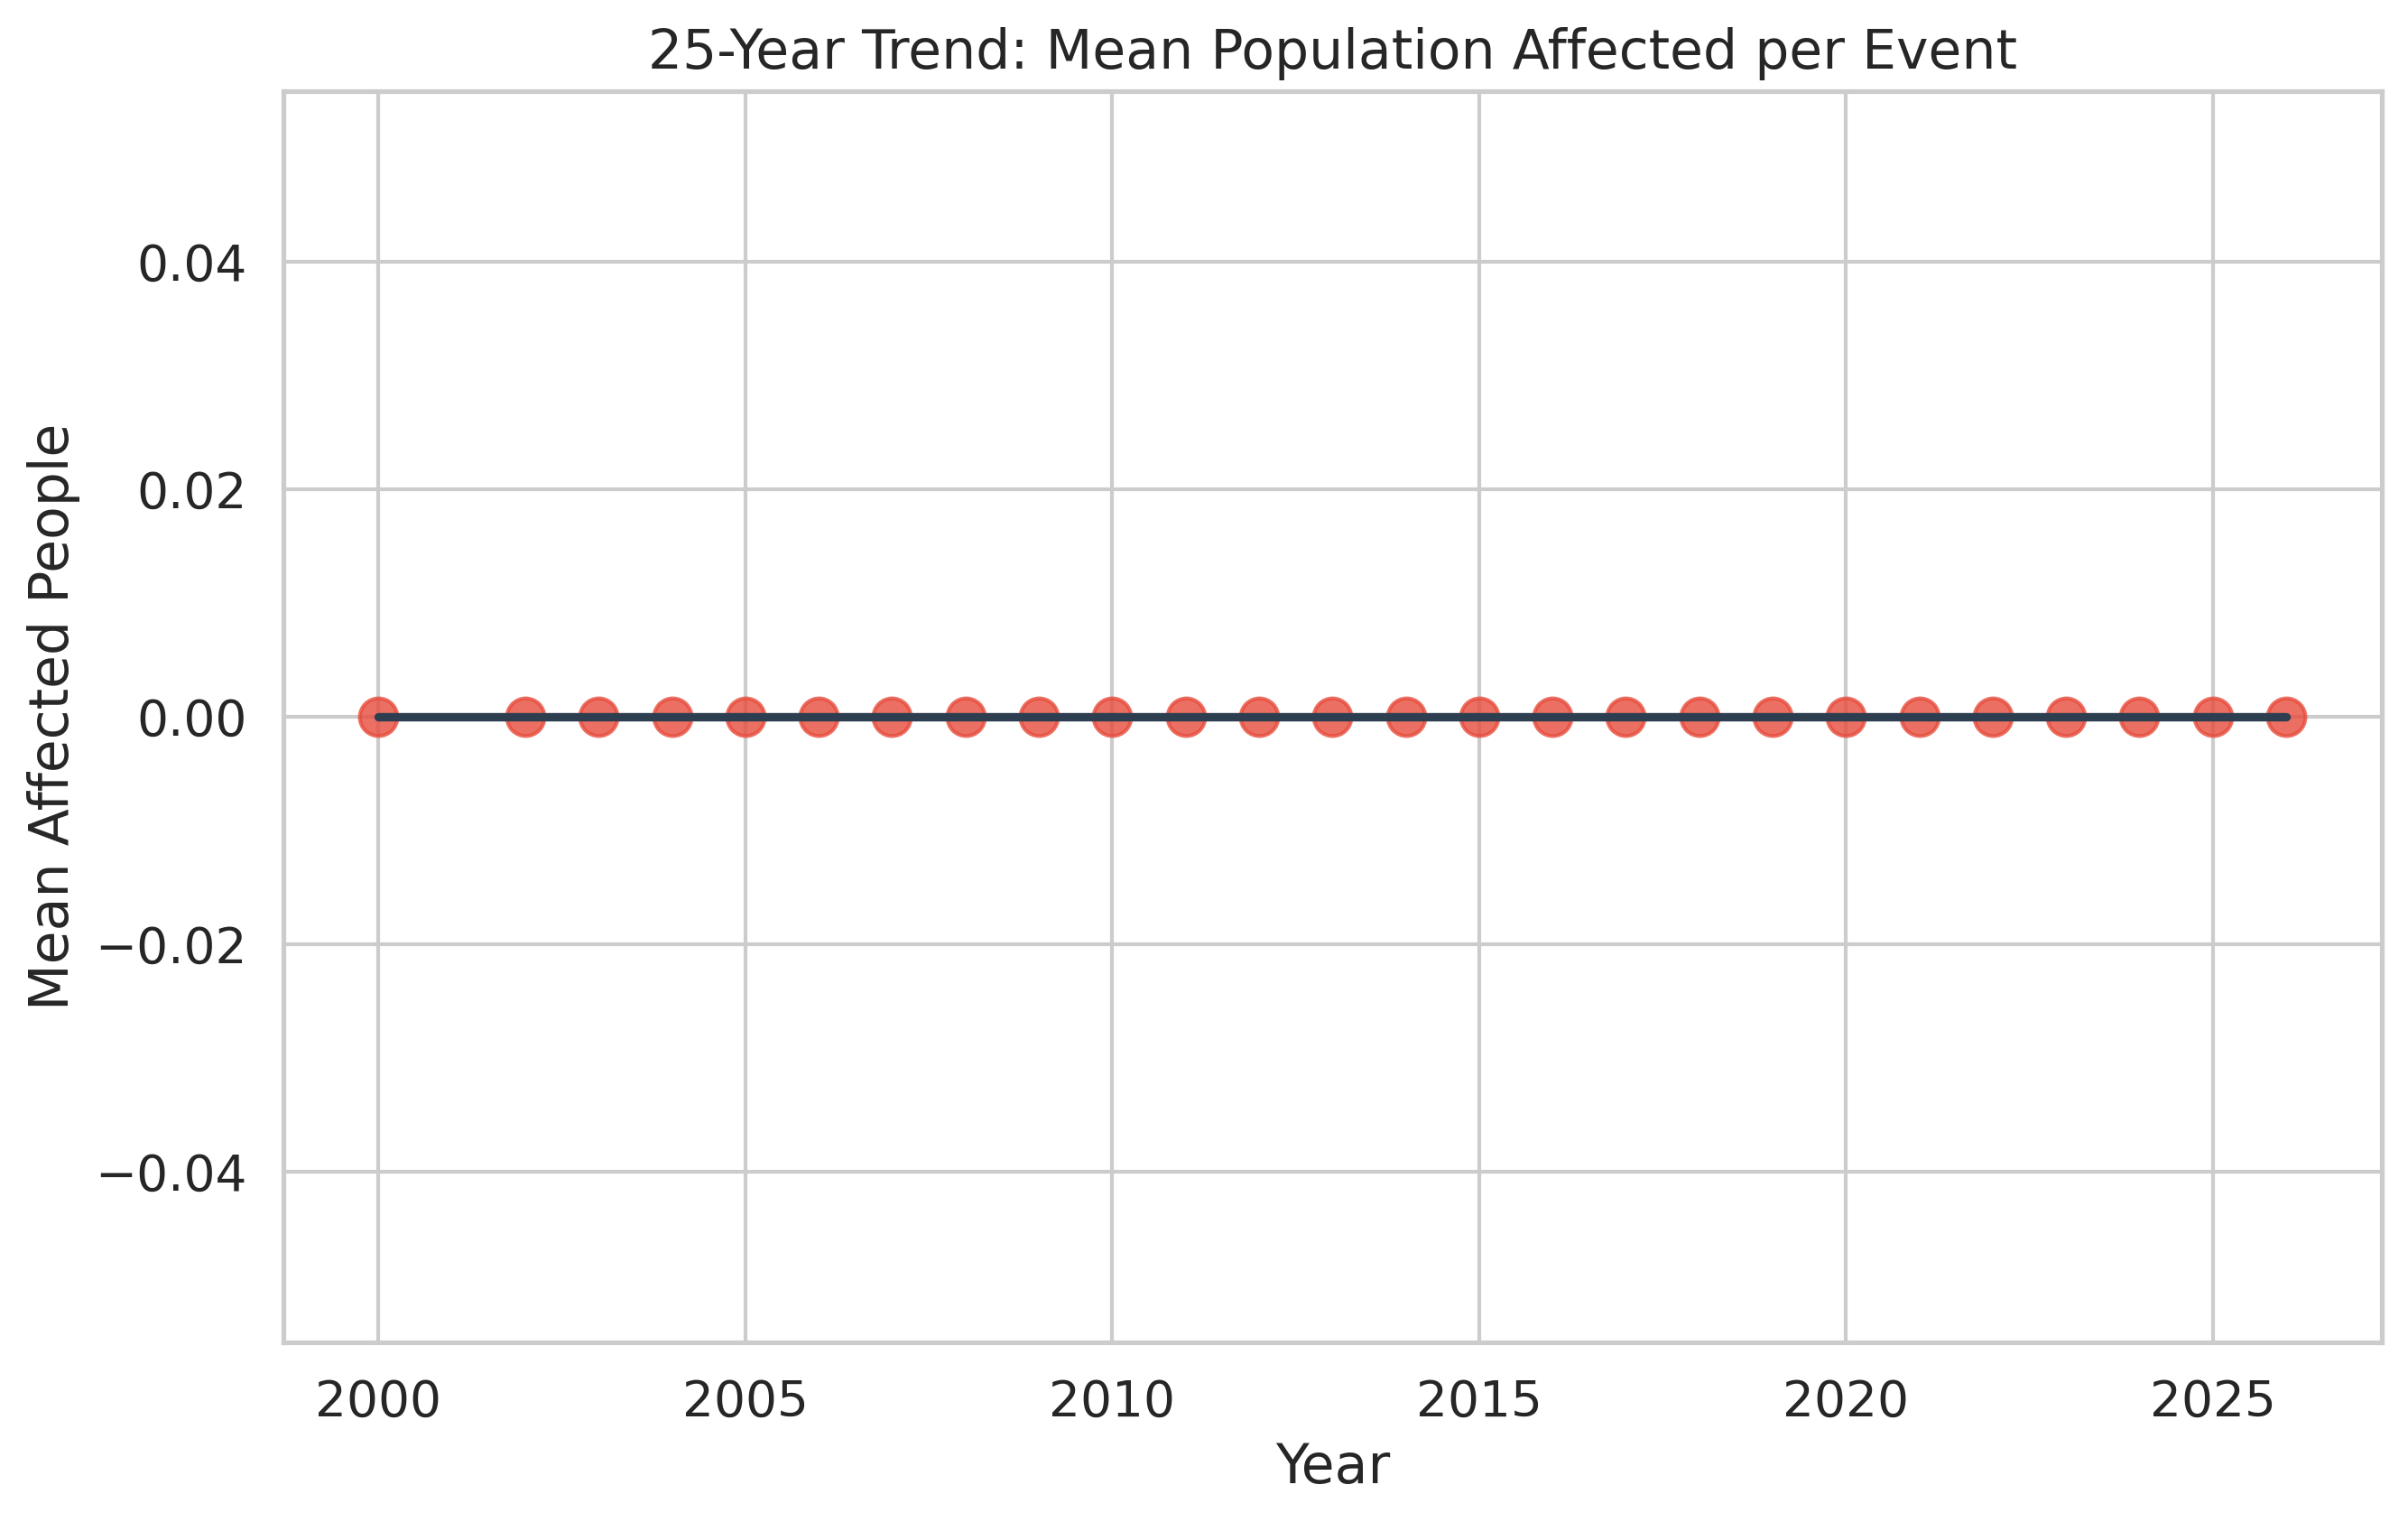

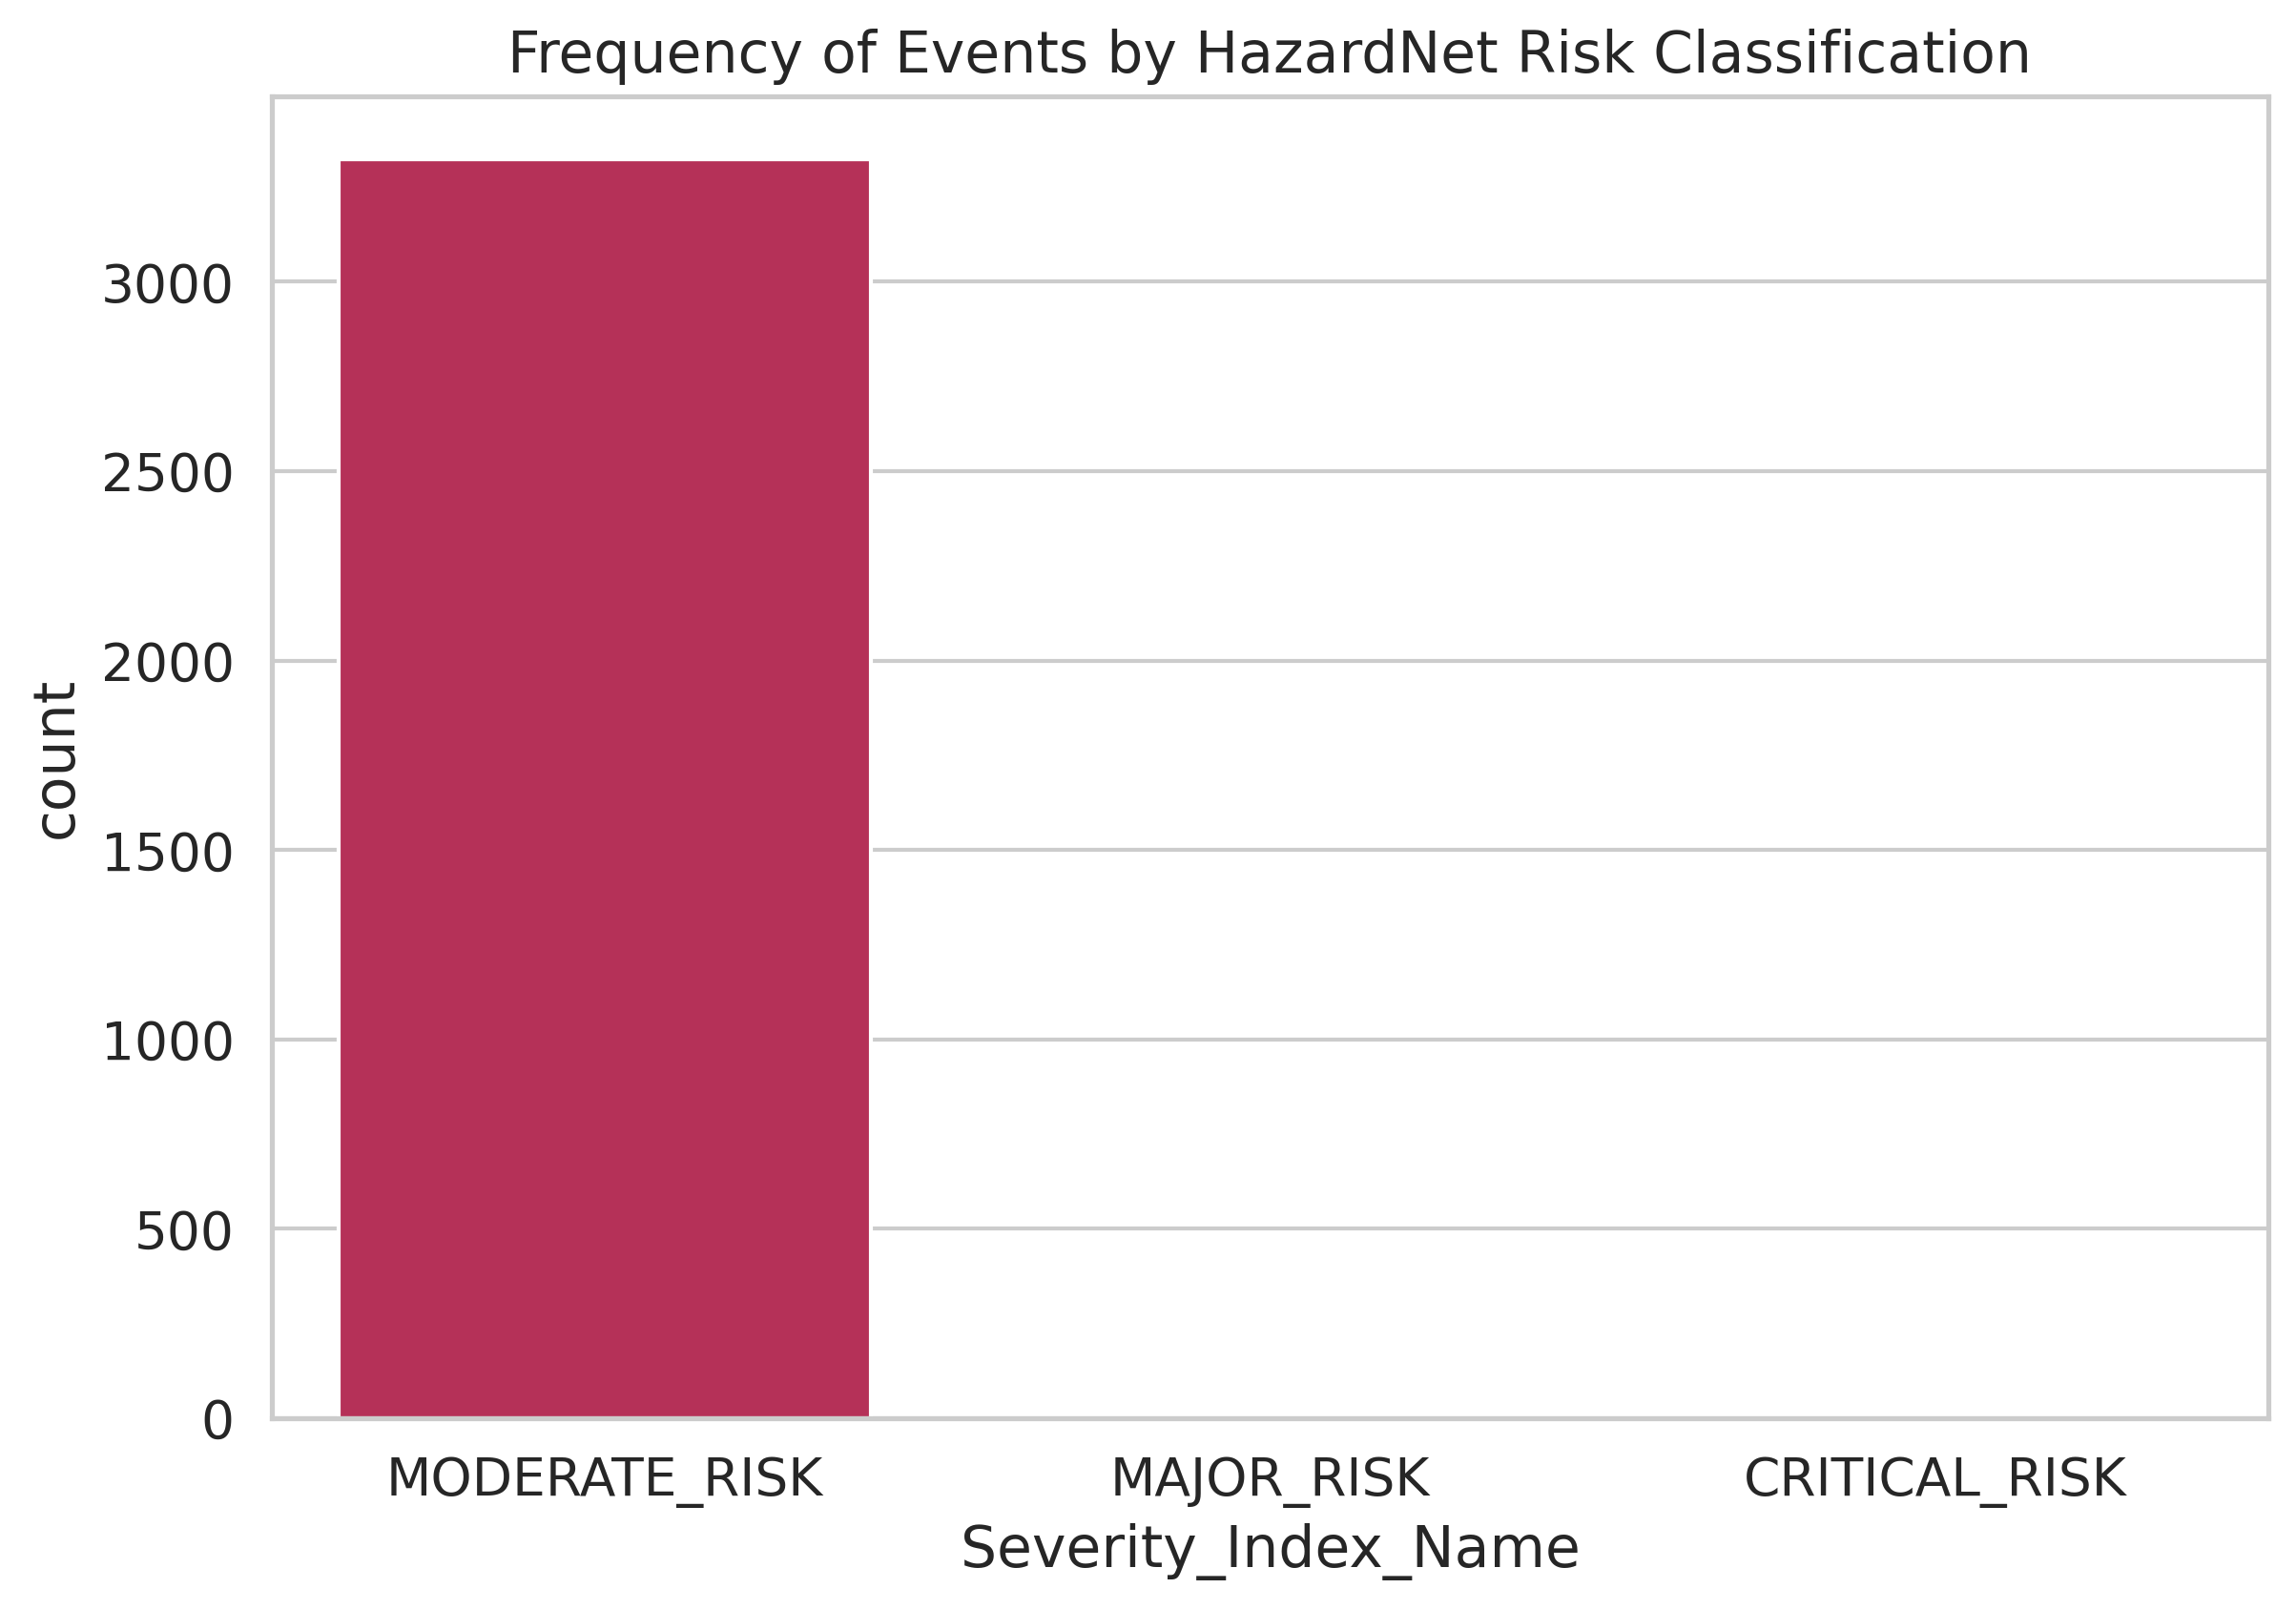

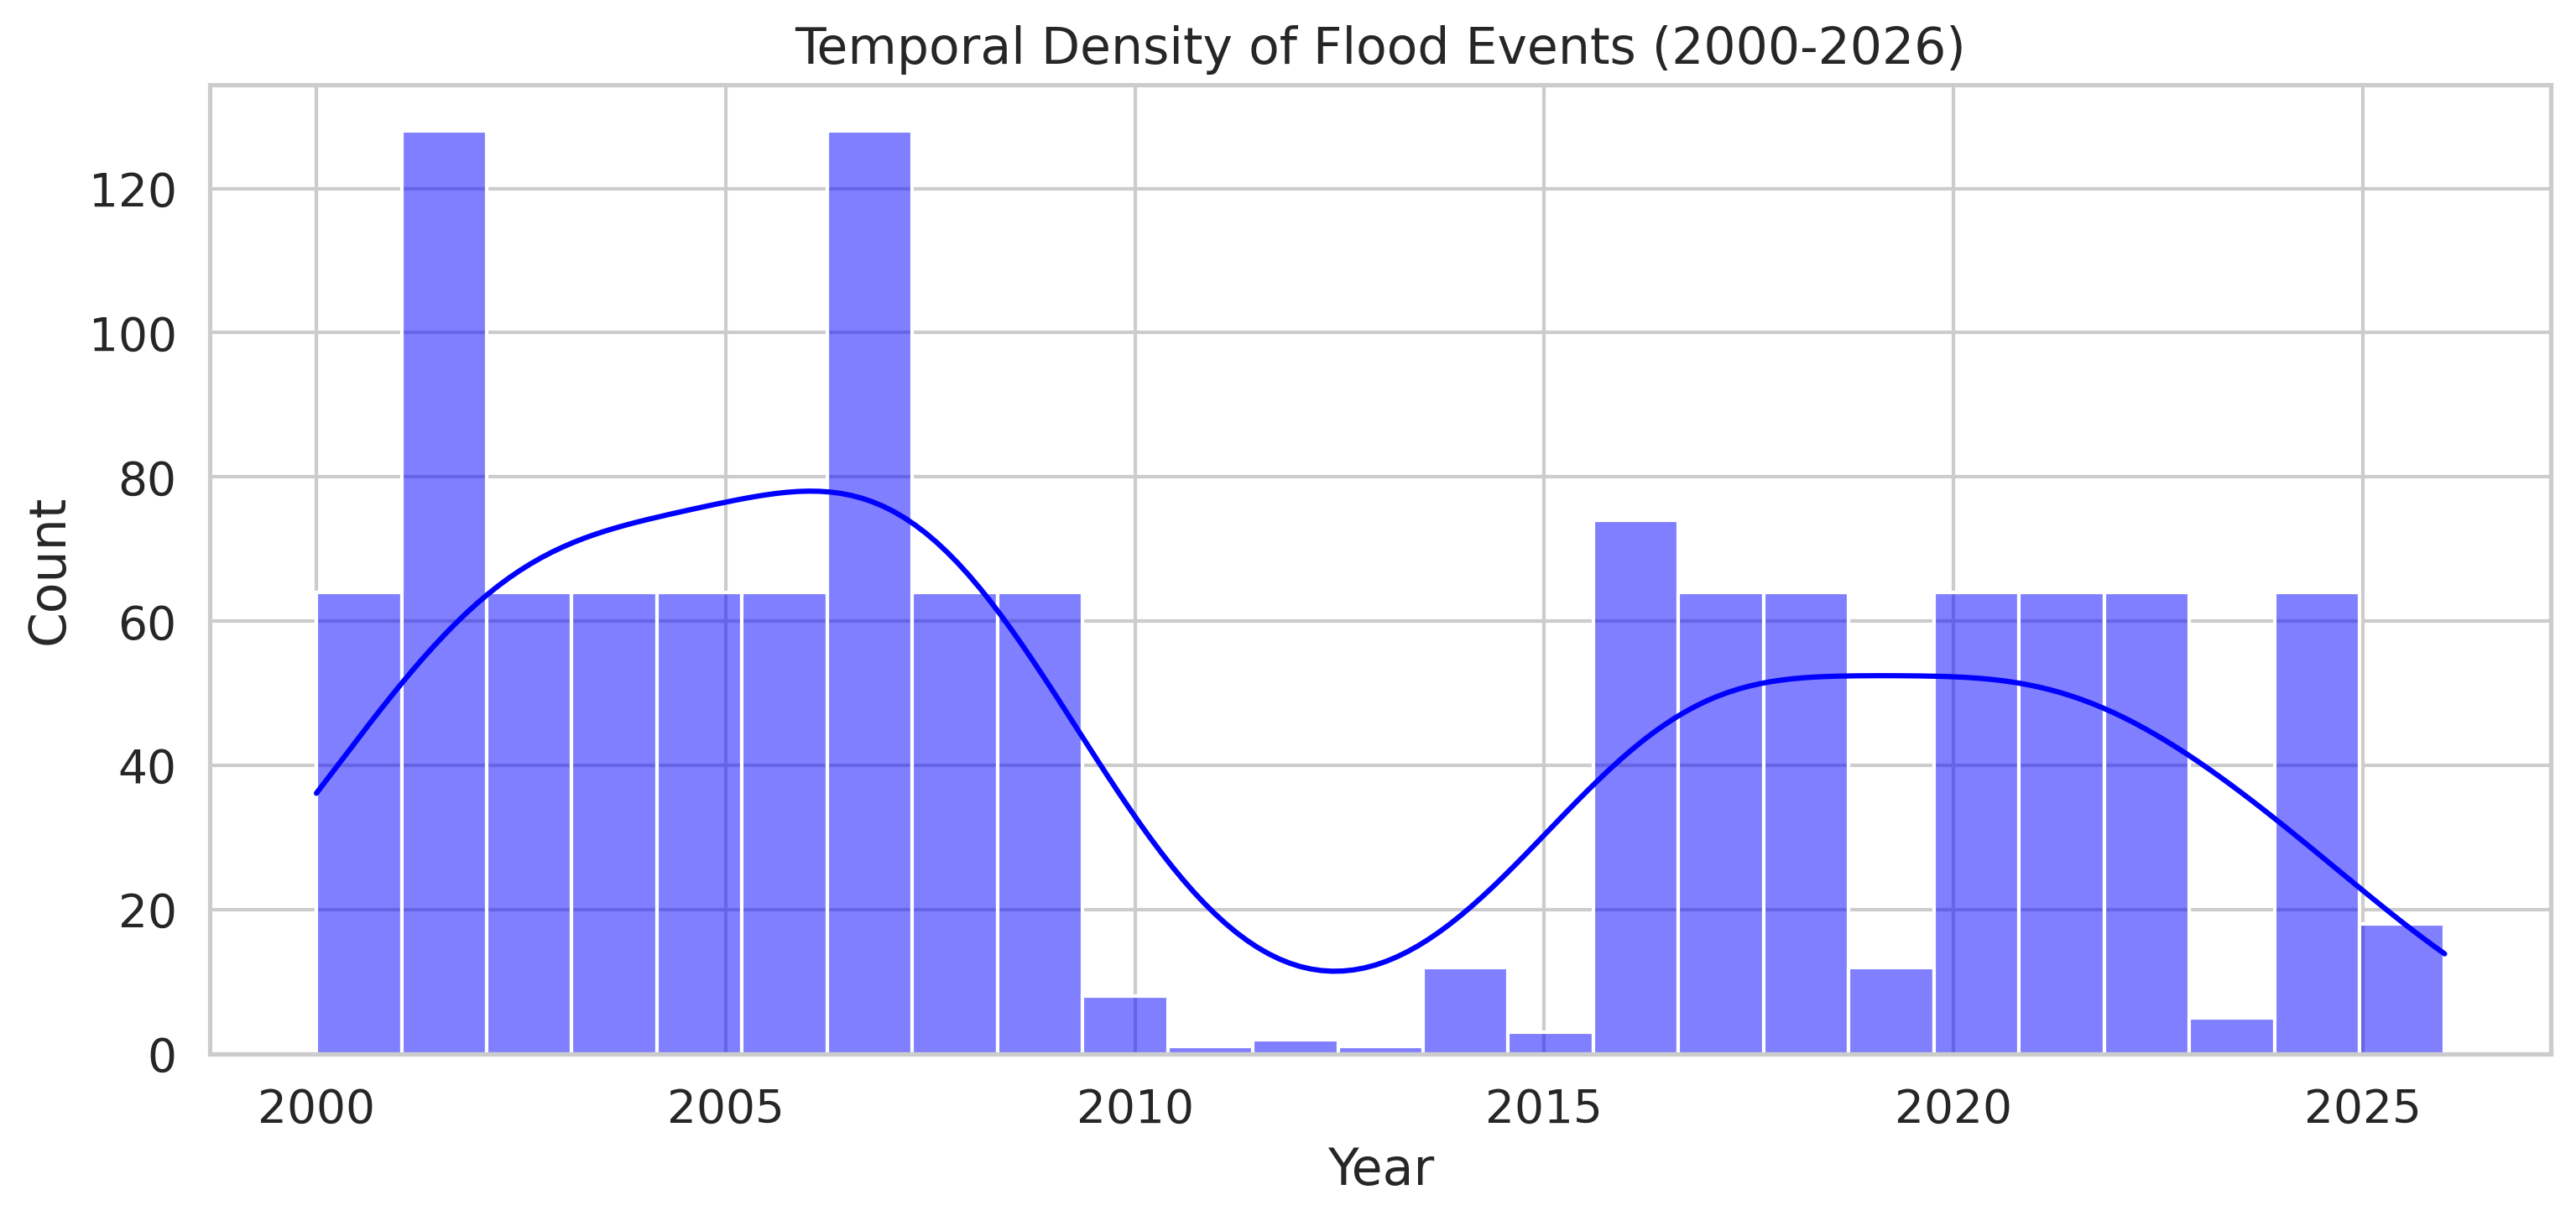


All visualizations generated.

All tasks completed. Output files: HazardNet_Final_Production_Dataset.csv, HazardNet_Events_For_GEE.csv, and various PNG/CSV files.


In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
import xml.etree.ElementTree as ET
import zipfile
from datetime import datetime, timedelta
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')


# ============================================================
# 0. GLOBAL CONFIGURATION
# ============================================================


CONFIG = {
    "APP_NAME": "BAU-HazardNetResearch-AAS7016",
    "RW_BASE_URL": "https://api.reliefweb.int/v2",
    "GDACS_RSS_URL": "https://www.gdacs.org/xml/rss.xml",
    "IFRC_API_BASE": "https://goadmin.ifrc.org/api/v2/",
    "EONET_URL": "https://eonet.gsfc.nasa.gov/api/v3/events",
    "HDX_RESOURCE_ID": "c5ce40d6-07b1-4f36-955a-d6196436ff6b",
    "COUNTRY_CODE": "BD",
    "GEE_WINDOW_DAYS": 50,
    "OUTPUT_FILE": "HazardNet_Master_Dataset_Final.csv",
    "DISTRICT_COORDS": {
        'Barguna': [22.1509, 90.1263], 'Barishal': [22.7010, 90.3535], 'Bhola': [22.6859, 90.6483],
        'Jhalokati': [22.6406, 90.1989], 'Patuakhali': [22.3596, 90.3297], 'Pirojpur': [22.5791, 89.9751],
        'Bandarban': [22.1953, 92.2184], 'Brahmanbaria': [23.9571, 91.1119], 'Chandpur': [23.2321, 90.6631],
        'Chattogram': [22.3569, 91.7832], 'Cumilla': [23.4607, 91.1809], "Cox's Bazar": [21.4272, 92.0058],
        'Feni': [23.0159, 91.3976], 'Khagrachari': [23.1192, 91.9847], 'Lakshmipur': [22.9447, 90.8282],
        'Noakhali': [22.8695, 91.0994], 'Rangamati': [22.6574, 92.1733], 'Dhaka': [23.8103, 90.4125],
        'Faridpur': [23.6071, 89.8429], 'Gazipur': [24.0023, 90.4264], 'Gopalganj': [23.0051, 89.8267],
        'Kishoreganj': [24.4260, 90.9821], 'Madaripur': [23.1641, 90.1833], 'Manikganj': [23.8644, 89.9967],
        'Munshiganj': [23.5435, 90.5354], 'Narayanganj': [23.6238, 90.5000], 'Narsingdi': [23.9322, 90.7154],
        'Rajbari': [23.7574, 89.6444], 'Shariatpur': [23.2423, 90.4348], 'Tangail': [24.2513, 89.9167],
        'Bagerhat': [22.6516, 89.7859], 'Chuadanga': [23.6401, 88.8504], 'Jessore': [23.1664, 89.2081],
        'Jhenaidah': [23.5450, 89.1726], 'Khulna': [22.8456, 89.5403], 'Kushtia': [23.9013, 89.1204],
        'Magura': [23.4873, 89.4199], 'Meherpur': [23.7622, 88.6318], 'Narail': [23.1725, 89.5126],
        'Satkhira': [22.7185, 89.0705], 'Jamalpur': [24.9375, 89.9311], 'Mymensingh': [24.7471, 90.4031],
        'Netrokona': [24.8700, 90.7275], 'Sherpur': [25.0205, 90.0154], 'Bogra': [24.8481, 89.3730],
        'Joypurhat': [25.0947, 89.0209], 'Naogaon': [24.7936, 88.9318], 'Natore': [24.4102, 88.9805],
        'Chapainawabganj': [24.5965, 88.2742], 'Pabna': [24.0063, 89.2493], 'Rajshahi': [24.3745, 88.6042],
        'Sirajganj': [24.4577, 89.7080], 'Dinajpur': [25.6217, 88.6354], 'Gaibandha': [25.3288, 89.5280],
        'Kurigram': [25.8054, 89.6361], 'Lalmonirhat': [25.9129, 89.4426], 'Nilphamari': [25.9317, 88.8560],
        'Panchagarh': [26.3411, 88.5541], 'Rangpur': [25.7439, 89.2752], 'Thakurgaon': [26.0337, 88.4616],
        'Habiganj': [24.3749, 91.4133], 'Moulvibazar': [24.4829, 91.7606], 'Sunamganj': [25.0658, 91.3950], 'Sylhet': [24.8949, 91.8687]
    }
}


BD_DISTRICTS = list(CONFIG['DISTRICT_COORDS'].keys())
REGIONAL_SYNONYMS = {
    "North Bengal": ["Dinajpur", "Gaibandha", "Kurigram", "Lalmonirhat", "Nilphamari", "Panchagarh", "Rangpur", "Thakurgaon"],
    "Coastal Belt": ["Barguna", "Bhola", "Patuakhali", "Satkhira", "Khulna", "Bagerhat"],
    "Barind Tract": ["Rajshahi", "Naogaon", "Chapai Nawabganj"]
}


HAZARD_MAPPER = {
    'Flood': 0, 'Flash Flood': 0, 'Tropical Cyclone': 1, 'Drought': 2,
    'Heat Wave': 3, 'Cold Wave': 4, 'Salinity': 5, 'Saltwater Intrusion': 5,
    'Epidemic': 6, 'Fire': 7, 'Earthquake': 8, 'Landslide': 9, 'Severe Local Storm': 10
}


SEVERITY_INDEX_MAP = {
    'Red': 'CRITICAL_RISK',
    'Orange': 'MAJOR_RISK',
    'Yellow': 'MODERATE_RISK'
}

current_year = datetime.now().year


# ============================================================
# 1. DATA AGGREGATION FUNCTIONS
# ============================================================


def robust_spatial_ner(text):
    """Extract districts; if 'national' appears, return 'National'."""
    if not text:
        return "National"
    if "national" in text.lower():
        return "National"
    found = [d for d in BD_DISTRICTS if d.lower() in text.lower()]
    for region, districts in REGIONAL_SYNONYMS.items():
        if region.lower() in text.lower():
            found.extend(districts)
    common_fixes = ["Sylhet", "Chattogram", "Cox's Bazar", "Rajshahi", "Khulna"]
    for d in common_fixes:
        if d.lower() in text.lower():
            found.append(d)
    found = list(set(found))
    return "|".join(found) if found else "National"


def fetch_emdat_from_hdx():
    try:
        url = f"https://data.humdata.org/api/3/action/resource_show?id={CONFIG['HDX_RESOURCE_ID']}"
        file_url = requests.get(url).json()['result']['url']
        df = pd.read_excel(BytesIO(requests.get(file_url).content))
        rename_logic = {
            'Glide': 'GLIDE', 'GLIDE': 'GLIDE', 'Disaster No.': 'GLIDE', 'Dis No': 'GLIDE',
            'Total Deaths': 'Deaths', 'Deaths': 'Deaths', 'Total affected': 'Affected',
            'Total Affected': 'Affected', 'Total damage (': 'Damage_USD'
        }
        new_cols = {}
        for col in df.columns:
            for key, val in rename_logic.items():
                if key in col:
                    new_cols[col] = val
        df.rename(columns=new_cols, inplace=True)
        return df
    except Exception as e:
        print(f"EM-DAT Fetch Error: {e}")
        return None


def get_eonet_data():
    try:
        res = requests.get(CONFIG["EONET_URL"], params={"status": "all", "days": 11000}, timeout=15)
        return res.json().get('events', [])
    except:
        return []


def match_eonet_proximity(date_str, districts, eonet_list):
    matches = 0
    try:
        if not isinstance(date_str, str): return 0
        row_date = datetime.strptime(date_str, '%Y-%m-%d')
        if not isinstance(districts, str): return 0
        district_list = districts.split('|')
        for e in eonet_list:
            if not isinstance(e, dict) or 'geometry' not in e or not isinstance(e['geometry'], list) or not e['geometry']:
                continue
            e_date_str = e['geometry'][0].get('date', '')[:10]
            if not e_date_str: continue
            try:
                e_date = datetime.strptime(e_date_str, '%Y-%m-%d')
            except:
                continue
            if abs((row_date - e_date).days) <= 5:
                e_title = e.get('title', '')
                if any(d.lower() in e_title.lower() for d in district_list):
                    matches += 1
    except Exception:
        return 0
    return matches


def get_crop_data_from_reports(glide_id):
    if not glide_id or glide_id == "N/A": return ""
    try:
        res = requests.post(f"{CONFIG['RW_BASE_URL']}/reports", json={
            "filter": {"field": "glide", "value": [glide_id]},
            "fields": {"include": ["body"]},
            "limit": 5
        }).json()
        return " ".join([item['fields'].get('body', '') for item in res.get('data', [])])
    except:
        return ""


def enrich_all_sources(df, eonet_events):
    if df.empty: return df
    try:
        ifrc = requests.get(f"{CONFIG['IFRC_API_BASE']}event/?countries__iso3=BGD&limit=200").json().get('results', [])
        ifrc_map = {e.get('glide'): e for e in ifrc if e.get('glide')}
        df['IFRC_Severity'] = df['GLIDE'].map(lambda x: ifrc_map.get(x, {}).get('ifrc_severity_level_display'))
        df['IFRC_Affected'] = df['GLIDE'].map(lambda x: ifrc_map.get(x, {}).get('num_affected', 0))
    except:
        pass
    try:
        root = ET.fromstring(requests.get(CONFIG['GDACS_RSS_URL']).content)
        gdacs_glides = []
        for item in root.findall('.//item'):
            title = item.find('title').text if item.find('title') is not None else ''
            match = re.search(r'GLIDE:\s*([A-Z0-9\-]+)', title)
            if match:
                gdacs_glides.append(match.group(1))
        df['GDACS_Active_Alert'] = df['GLIDE'].apply(lambda x: 1 if x in gdacs_glides else 0)
    except:
        pass
    try:
        resp = requests.get("https://www.desinventar.net/DesInventar/download/DI_export_bd.zip")
        with zipfile.ZipFile(BytesIO(resp.content)) as z:
            with z.open("DI_export_bd.xml") as f:
                di_map = {}
                for event in ET.parse(f).getroot().findall('.//fichas/TR'):
                    gl = event.find('glide').text if event.find('glide') is not None else None
                    if gl:
                        crops = sum([float(i.find('valor').text) for i in event.findall('impactos/IMPACTO') if 'crop' in i.find('tipo').text.lower()])
                        di_map[gl] = crops
                df['DesInventar_Crop_Loss_Ha'] = df['GLIDE'].map(di_map)
    except:
        pass
    df['EONET_Proximity_Matches'] = df.apply(lambda r: match_eonet_proximity(r['Date'], r['Location_Districts'], eonet_events), axis=1, result_type='reduce')
    return df


def run_hazardnet_unified_pipeline(start_date="2000-01-01T00:00:00+00:00", end_date=None):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Launching Unified Aggregator...")
    if end_date is None:
        end_date = datetime.now().strftime('%Y-%m-%dT%H:%M:%S+00:00')
    rw_res = requests.post(f"{CONFIG['RW_BASE_URL']}/disasters?appname={CONFIG['APP_NAME']}", json={
        "filter": {"operator": "AND", "conditions": [
            {"field": "primary_country", "value": ["Bangladesh"]},
            {"field": "date.event", "value": {"from": start_date, "to": end_date}}
        ]},
        "fields": {"include": ["id", "glide", "name", "date.event", "type", "profile", "description"]},
        "limit": 1000,
        "sort": ["date.event:desc"]
    }).json().get('data', [])
    emdat_df = fetch_emdat_from_hdx()
    eonet_events = get_eonet_data()
    ml_records = []
    for entry in rw_res:
        f = entry['fields']
        eid, glide = entry['id'], f.get('glide', 'N/A')
        date_str = f.get('date', {}).get('event', '2000-01-01')[:10]
        dt = datetime.strptime(date_str, '%Y-%m-%d')
        desc = f.get('description', '')
        locs = robust_spatial_ner(desc)
        hazard_raw = f.get('type', [{}])[0].get('name', 'Unknown')
        rep_txt = get_crop_data_from_reports(glide)
        full_description = (desc + " " + rep_txt).strip()
        if not full_description:
            full_description = "No detailed description available."
        crop_matches = re.findall(r'([\d,.]+)\s*(?:ha|hectares|acres)', (desc + " " + rep_txt).lower())
        total_ha = sum(float(c.replace(',', '')) for c in crop_matches if c.replace(',', '').replace('.', '').isdigit())
        ml_records.append({
            "Event_ID": eid, "GLIDE": glide, "Date": date_str, "Year": dt.year,
            "Hazard_Type": hazard_raw, "Hazard_Class": HAZARD_MAPPER.get(hazard_raw, 10),
            "Location_Districts": locs, "RW_Affected": f.get('profile', {}).get('affected', 0),
            "Text_Extracted_Crop_Ha": total_ha, "Full_Description": full_description,
            "GEE_Start": (dt - timedelta(days=CONFIG['GEE_WINDOW_DAYS'])).strftime('%Y-%m-%d'),
            "GEE_End": (dt + timedelta(days=CONFIG['GEE_WINDOW_DAYS'])).strftime('%Y-%m-%d')
        })
    df = pd.DataFrame(ml_records)
    if emdat_df is not None and 'GLIDE' in emdat_df.columns:
        merge_cols = [c for c in ['GLIDE', 'Deaths', 'Affected', 'Damage_USD'] if c in emdat_df.columns]
        df = pd.merge(df, emdat_df[merge_cols].dropna(subset=['GLIDE']), on='GLIDE', how='left')
    df = enrich_all_sources(df, eonet_events)
    affected_cols = [c for c in ['RW_Affected', 'IFRC_Affected', 'Affected'] if c in df.columns]
    df['Validated_Affected'] = df[affected_cols].max(axis=1).fillna(0)
    df['Last_Updated'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    df.to_csv(CONFIG['OUTPUT_FILE'], index=False)
    print(f"SUCCESS: Aggregated {len(df)} events into {CONFIG['OUTPUT_FILE']}")
    return df


# ============================================================
# 2. PRODUCTION PIPELINE (Dense Grid & GEE Export)
# ============================================================


class HazardNetPipeline:
    def __init__(self, start_year=2000, end_year=current_year, district_coords=None, severity_index_map=None):
        self.start_date = f"{start_year}-01-01"
        self.end_date = datetime.now().strftime("%Y-%m-%d")
        self.master_df = None
        self.dense_df = None
        self.district_coords = district_coords if district_coords is not None else {}
        self.severity_index_map = severity_index_map if severity_index_map is not None else {}


    def step1_fetch_and_aggregate(self):
        print("[Step 1] Fetching raw data from Multi-API sources...")
        self.master_df = run_hazardnet_unified_pipeline(
            start_date=f"{pd.to_datetime(self.start_date).year}-01-01T00:00:00+00:00",
            end_date=f"{pd.to_datetime(self.end_date).year}-12-31T23:59:59+00:00"
        )
        # Expand "National" to all districts
        national_rows = self.master_df['Location_Districts'] == 'National'
        if national_rows.any():
            all_districts_str = "|".join(BD_DISTRICTS)
            self.master_df.loc[national_rows, 'Location_Districts'] = all_districts_str


    def step2_localize_and_geocode(self):
        print("[Step 2] Exploding locations to District-level geodata...")
        df = self.master_df.copy()
        df['District'] = df['Location_Districts'].str.split('|')
        df = df.explode('District')
        df = df[df['District'].isin(self.district_coords.keys())]
        # Remove duplicates (same date, same district)
        df = df.drop_duplicates(subset=['Date', 'District'], keep='first')
        df['Latitude'] = df['District'].map(lambda d: self.district_coords[d][0])
        df['Longitude'] = df['District'].map(lambda d: self.district_coords[d][1])
        self.localized_df = df


    def step3_apply_severity_indexing(self):
        print("[Step 3] Mapping API metadata to Unique HazardNet Indices...")
        def get_sev(row):
            ifrc = row.get('IFRC_Severity')
            if ifrc in ['Red', 'Orange', 'Yellow']:
                return ifrc
            return 'Red' if row.get('GDACS_Active_Alert') == 1 else 'Yellow'
        self.localized_df['API_Severity_Level'] = self.localized_df.apply(get_sev, axis=1)
        self.localized_df['Severity_Index_Name'] = self.localized_df['API_Severity_Level'].map(self.severity_index_map)
        self.localized_df['Severity_Score'] = self.localized_df['API_Severity_Level'].map({'Red': 3, 'Orange': 2, 'Yellow': 1})


    def step4_generate_dense_history(self):
        print(f"[Step 4] Generating dense {self.start_date[:4]}-{self.end_date[:4]} time-series grid...")
        dates = pd.date_range(start=self.start_date, end=self.end_date)
        districts = list(self.district_coords.keys())
        grid = pd.DataFrame(pd.MultiIndex.from_product([dates, districts], names=['Date', 'District']).to_flat_index().tolist(), columns=['Date', 'District'])
        grid['Date'] = grid['Date'].dt.strftime('%Y-%m-%d')
        final = pd.merge(grid, self.localized_df, on=['Date', 'District'], how='left')
        fill_cols = {'Hazard_Type': 'Baseline/None', 'Severity_Index_Name': 'NO_RISK', 'Severity_Score': 0, 'Validated_Affected': 0, 'Full_Description': ''}
        for col, val in fill_cols.items():
            final[col] = final[col].fillna(val)
        final['Latitude'] = final['District'].map(lambda d: self.district_coords[d][0])
        final['Longitude'] = final['District'].map(lambda d: self.district_coords[d][1])
        self.dense_df = final
        self.dense_df.to_csv('HazardNet_Final_Production_Dataset.csv', index=False)
        print(f"Pipeline Complete. Final Dataset: {len(self.dense_df)} rows.")


    def run_full_pipeline(self):
        self.step1_fetch_and_aggregate()
        self.step2_localize_and_geocode()
        self.step3_apply_severity_indexing()
        self.step4_generate_dense_history()
        return self.dense_df


def prepare_gee_dataset(df, start_yr=2000, end_yr=current_year, window=50):
    print(f"[Prep] Filtering for events between {start_yr} and {end_yr}...")
    df_prep = df.copy()
    df_prep['Date'] = pd.to_datetime(df_prep['Date'])
    df_prep = df_prep[(df_prep['Date'].dt.year >= start_yr) & (df_prep['Date'].dt.year <= end_yr)]
    df_events = df_prep[df_prep['Hazard_Type'] != 'Baseline/None'].copy()
    df_unique = df_events.reset_index(drop=True)
    df_unique['Event_ID_Internal'] = [f"Event_{i:04d}" for i in range(len(df_unique))]
    df_unique['GEE_Start'] = (df_unique['Date'] - timedelta(days=window)).dt.strftime('%Y-%m-%d')
    df_unique['GEE_End'] = (df_unique['Date'] + timedelta(days=window)).dt.strftime('%Y-%m-%d')
    output_cols = ['Event_ID_Internal', 'GLIDE', 'Date', 'District', 'Latitude', 'Longitude', 'Hazard_Type',
                   'GEE_Start', 'GEE_End', 'Severity_Index_Name', 'Severity_Score', 'Validated_Affected']
    if 'Full_Description' in df_unique.columns:
        output_cols.append('Full_Description')
    return df_unique[output_cols]


# ============================================================
# 3. CONSOLIDATED ANALYSIS FUNCTIONS
# ============================================================


plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style='whitegrid')


def _display(obj):
    """Helper to display DataFrames in notebooks or print in terminals."""
    try:
        from IPython.display import display
        display(obj)
    except ImportError:
        if isinstance(obj, pd.DataFrame):
            print(obj.to_string())
        else:
            print(obj)


def run_all_analysis(df_events, df_dense):
    """One function for all statistical summaries and CSV exports."""
    print("\n" + "="*60)
    print("STATISTICAL ANALYSIS & EXPORTS")
    print("="*60)


    # 1. General descriptive statistics
    general_stats = pd.DataFrame({
        'Metric': ['Total Unique Events', 'Unique Districts', 'Date Range Start', 'Date Range End',
                   'Mean Severity Score', 'Total Validated Affected'],
        'Value': [len(df_events), df_events['District'].nunique(),
                  df_events['Date'].min(), df_events['Date'].max(),
                  df_events['Severity_Score'].mean(), df_events['Validated_Affected'].sum()]
    })
    general_stats.to_csv('hazardnet_general_summary_stats.csv', index=False)
    _display(general_stats)


    # 2. Hazard‑specific analysis
    hazard_stats = df_events.groupby('Hazard_Type').agg({
        'Event_ID_Internal': 'count',
        'Severity_Score': ['mean', 'std', 'max'],
        'Validated_Affected': ['sum', 'mean', 'max']
    }).reset_index()
    hazard_stats.columns = ['Hazard_Type', 'Event_Count', 'Mean_Severity', 'Std_Severity',
                            'Max_Severity', 'Total_Affected', 'Mean_Affected', 'Max_Affected']
    hazard_stats.to_csv('hazardnet_hazard_type_analysis.csv', index=False)


    # 3. District vulnerability index
    district_stats = df_events.groupby('District').agg({
        'Hazard_Type': 'nunique',
        'Event_ID_Internal': 'count',
        'Severity_Score': 'mean',
        'Validated_Affected': 'sum'
    }).reset_index()
    district_stats.columns = ['District', 'Unique_Hazard_Types', 'Total_Events',
                              'Avg_Severity', 'Cumulative_Affected']
    district_stats['Vulnerability_Score'] = (district_stats['Total_Events'] * district_stats['Avg_Severity']).rank(pct=True)
    district_stats.sort_values('Vulnerability_Score', ascending=False, inplace=True)
    district_stats.to_csv('hazardnet_district_vulnerability_index.csv', index=False)


    # 4. Correlation matrix
    corr_matrix = df_events[['Severity_Score', 'Validated_Affected', 'Latitude', 'Longitude']].corr()
    corr_matrix.to_csv('hazardnet_statistical_correlations.csv')


    # 5. Yearly trends
    yearly_trends = df_events.groupby(pd.to_datetime(df_events['Date']).dt.year).agg({
        'Event_ID_Internal': 'count',
        'Validated_Affected': 'sum'
    }).reset_index()
    yearly_trends.columns = ['Year', 'Event_Frequency', 'Annual_Affected_Population']
    yearly_trends.to_csv('hazardnet_yearly_temporal_trends.csv', index=False)


    # 6. Descriptive summary (printed)
    print("\n--- HazardNet Descriptive Statistics Summary ---")
    stats_summary = pd.DataFrame({
        'Metric': ['Total Events (2000-2026)', 'Unique Districts Affected', 'Avg Events Per Year',
                   'Primary Hazard Type', 'Most Frequent District'],
        'Value': [len(df_events), df_events['District'].nunique(),
                  round(len(df_events)/25, 2),
                  df_events['Hazard_Type'].mode()[0] if not df_events.empty else "N/A",
                  df_events['District'].mode()[0] if not df_events.empty else "N/A"]
    })
    _display(stats_summary)
    print("\nAll statistical CSVs saved.")


def generate_all_visualizations(df_events, df_dense):
    """One function that produces ALL plots (previously scattered)."""
    print("\n" + "="*60)
    print("GENERATING ALL VISUALIZATIONS")
    print("="*60)


    # ---- 1. Temporal trends ----
    df_events['Year'] = pd.to_datetime(df_events['Date']).dt.year
    yearly_counts = df_events.groupby('Year').size()
    plt.figure(figsize=(14,6))
    sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='#d62728', linewidth=2.5)
    plt.title('25-Year Hazard Frequency Trend in Bangladesh (2000-2026)', fontsize=16)
    plt.xlabel('Year')
    plt.ylabel('Number of Events')
    plt.xticks(range(2000,2026,2))
    plt.tight_layout()
    plt.show()


    # ---- 2. Hazard type distribution ----
    plt.figure(figsize=(12,7))
    hazard_order = df_events['Hazard_Type'].value_counts().index
    sns.countplot(data=df_events, y='Hazard_Type', order=hazard_order, palette='viridis', hue='Hazard_Type', legend=False)
    plt.title('Distribution of Hazard Types (Total Occurrences)')
    plt.tight_layout()
    plt.show()


    # ---- 3. Top 15 districts by frequency ----
    top_districts = df_events['District'].value_counts().head(15)
    plt.figure(figsize=(12,6))
    sns.barplot(x=top_districts.values, y=top_districts.index, palette='magma', hue=top_districts.index, legend=False)
    plt.title('Top 15 Districts by Hazard Frequency')
    plt.tight_layout()
    plt.show()


    # ---- 4. Severity index pie ----
    if 'Severity_Index_Name' in df_events.columns:
        severity_data = df_events['Severity_Index_Name'].value_counts()
        colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
        plt.figure(figsize=(8,8))
        plt.pie(severity_data, labels=severity_data.index, autopct='%1.1f%%', startangle=140,
                colors=colors[:len(severity_data)], explode=[0.05]*len(severity_data), shadow=True)
        plt.title('Breakdown of Event Severity (HazardNet Index)')
        plt.tight_layout()
        plt.show()


    # ---- 5. Impact analysis (area plot, diversity, correlation, boxplot) ----
    if 'Validated_Affected' in df_dense.columns:
        yearly_impact = df_dense.groupby(pd.to_datetime(df_dense['Date']).dt.year)['Validated_Affected'].sum().reset_index()
        plt.figure(figsize=(14,7))
        plt.fill_between(yearly_impact['Date'], yearly_impact['Validated_Affected'], color="skyblue", alpha=0.4)
        plt.plot(yearly_impact['Date'], yearly_impact['Validated_Affected'], color="Slateblue", alpha=0.6, linewidth=2)
        plt.title('Total Population Affected by Hazard Events (2000-2026)', fontsize=18, fontweight='bold')
        plt.ylabel('Total People Affected')
        plt.xlabel('Year')
        plt.show()


    diversity = df_events.groupby('District')['Hazard_Type'].nunique().sort_values(ascending=False).head(20)
    plt.figure(figsize=(12,8))
    sns.barplot(x=diversity.values, y=diversity.index, palette='rocket', hue=diversity.index, legend=False)
    plt.title('Top 20 Districts by Hazard Diversity (Multi-Hazard Vulnerability Index)', fontsize=16)
    plt.xlabel('Count of Unique Hazard Types')
    plt.show()


    corr_cols = ['Severity_Score', 'Validated_Affected', 'Latitude', 'Longitude']
    avail_cols = [c for c in corr_cols if c in df_events.columns]
    if len(avail_cols) > 1:
        plt.figure(figsize=(10,8))
        sns.heatmap(df_events[avail_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
        plt.title('Correlation Analysis: Severity vs. Geographic & Human Exposure', fontsize=16)
        plt.show()


    if 'Validated_Affected' in df_events.columns:
        plt.figure(figsize=(14,8))
        sns.boxplot(data=df_events, x='Hazard_Type', y='Validated_Affected', palette='Set3', hue='Hazard_Type', legend=False)
        plt.yscale('symlog')
        plt.title('Distribution of Affected Population per Hazard Type (Log Scale)', fontsize=16)
        plt.xticks(rotation=45)
        plt.show()


    # ---- 6. Clustering: correlation matrix, step chart, polar profiles ----
    sns.set_context('notebook', font_scale=1.2)
    district_hazard_matrix = df_events.pivot_table(index='District', columns='Hazard_Type', values='Event_ID_Internal', aggfunc='count').fillna(0)
    hazard_corr = district_hazard_matrix.corr()
    plt.figure(figsize=(12,10))
    sns.heatmap(hazard_corr, annot=True, cmap='RdYlGn_r', center=0, fmt='.2f')
    plt.title('Multi-Hazard Spatial Correlation Matrix (Hazard Co-occurrence Patterns)', fontsize=15)
    plt.show()


    plt.figure(figsize=(14,7))
    df_events['Date'] = pd.to_datetime(df_events['Date'])
    df_sorted = df_events.sort_values('Date')
    for h_type in df_sorted['Hazard_Type'].unique():
        subset = df_sorted[df_sorted['Hazard_Type'] == h_type]
        plt.step(subset['Date'], np.arange(1, len(subset)+1), label=h_type, where='post', alpha=0.8)
    plt.title('Temporal Acceleration of Hazard Events by Type (2000-2026)')
    plt.ylabel('Cumulative Number of Events')
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


    top_3 = df_events['District'].value_counts().head(3).index
    hazards = df_events['Hazard_Type'].unique()
    fig, axes = plt.subplots(1,3, figsize=(18,6), subplot_kw=dict(polar=True))
    for i, dist in enumerate(top_3):
        dist_data = df_events[df_events['District']==dist]['Hazard_Type'].value_counts().reindex(hazards, fill_value=0)
        values = dist_data.values.tolist()
        values += values[:1]
        angles = [n / float(len(hazards)) * 2*np.pi for n in range(len(hazards))]
        angles += angles[:1]
        axes[i].fill(angles, values, color='teal', alpha=0.3)
        axes[i].set_xticks(angles[:-1])
        axes[i].set_xticklabels(hazards, fontsize=8)
        axes[i].set_title(f'Risk Profile: {dist}', pad=20)
    plt.tight_layout()
    plt.show()


    # ---- 7. Seasonality density (KDE) ----
    df_events['Month'] = pd.to_datetime(df_events['Date']).dt.month
    plt.figure(figsize=(10,4))
    sns.kdeplot(data=df_events, x='Month', hue='Hazard_Type', fill=True, common_norm=False)
    plt.title('Hazard Seasonality Density')
    plt.show()


    # ---- 8. Seasonal radar (circular) ----
    months = np.arange(1,13)
    df_events['Month_Num'] = pd.to_datetime(df_events['Date']).dt.month
    top_hazards = df_events['Hazard_Type'].value_counts().head(5).index
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111, polar=True)
    for h_type in top_hazards:
        monthly_counts = df_events[df_events['Hazard_Type']==h_type]['Month_Num'].value_counts().reindex(months, fill_value=0)
        values = monthly_counts.values.tolist()
        values += values[:1]
        angles = [n/12 * 2*np.pi for n in range(12)]
        angles += angles[:1]
        ax.plot(angles, values, label=h_type, linewidth=2)
        ax.fill(angles, values, alpha=0.1)
    ax.set_xticks([n/12 * 2*np.pi for n in range(12)])
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.title('Seasonal Clock: Hazard Frequency Distribution', pad=30)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))
    plt.show()


    # ---- 9. District intensity matrix (heatmap) ----
    pivot_intensity = df_events.pivot_table(index='District', columns='Hazard_Type', values='Severity_Score', aggfunc='mean').fillna(0)
    plt.figure(figsize=(14,12))
    sns.heatmap(pivot_intensity, cmap='YlGnBu', annot=False, linewidths=.1)
    plt.title('Multi-Hazard Mean Intensity Matrix by District')
    plt.show()


    # ---- 10. Log-scale impact boxen plot ----
    plot_df = df_events.copy()
    plot_df['Impact_Adj'] = plot_df['Validated_Affected'] + 1
    plt.figure(figsize=(14,8))
    sns.boxenplot(data=plot_df, x='Hazard_Type', y='Impact_Adj', palette='Spectral', hue='Hazard_Type', legend=False)
    plt.yscale('log')
    plt.title('Log-Scale Human Impact Distribution by Hazard Category')
    plt.ylabel('Affected Population (Log + 1)')
    plt.xticks(rotation=45)
    plt.show()


    # ---- 11. Individual plots: cyclone trend, flood severity, top affected districts, monthly heatmap ----
    # Cyclone trend
    cyclone_df = df_events[df_events['Hazard_Type']=='Tropical Cyclone'].groupby(pd.to_datetime(df_events['Date']).dt.year).size()
    if not cyclone_df.empty:
        plt.figure(figsize=(10,6))
        sns.lineplot(x=cyclone_df.index, y=cyclone_df.values, marker='o', color='teal', linewidth=2)
        plt.title('Historical Trend of Tropical Cyclones in Bangladesh (2000-2026)')
        plt.xlabel('Year')
        plt.ylabel('Event Count')
        plt.savefig('cyclone_frequency_trend_2000_2026.png', bbox_inches='tight')
        plt.show()


    # Flood severity violin
    flood_df = df_events[df_events['Hazard_Type'].str.contains('Flood')].copy()
    if not flood_df.empty:
        plt.figure(figsize=(8,6))
        sns.violinplot(data=flood_df, x='Hazard_Type', y='Severity_Score', hue='Hazard_Type', palette='Blues', inner='quartile', legend=False)
        plt.title('Severity Score Distribution: Floods vs Flash Floods')
        plt.savefig('flood_severity_distribution_comparison.png', bbox_inches='tight')
        plt.show()


    # Top 10 districts by affected population
    dist_impact = df_events.groupby('District')['Validated_Affected'].sum().sort_values(ascending=False).head(10).reset_index()
    plt.figure(figsize=(12,6))
    sns.barplot(data=dist_impact, x='Validated_Affected', y='District', hue='District', palette='Reds_r', legend=False)
    plt.title('Top 10 Most Vulnerable Districts by Cumulative Population Affected')
    plt.xlabel('Total People Affected')
    plt.savefig('top_10_districts_affected_population.png', bbox_inches='tight')
    plt.show()


    # Monthly occurrence heatmap
    df_copy = df_events.copy()
    df_copy['Month'] = pd.to_datetime(df_copy['Date']).dt.month
    seasonal_matrix = df_copy.groupby(['Hazard_Type','Month']).size().unstack(fill_value=0)
    plt.figure(figsize=(12,8))
    sns.heatmap(seasonal_matrix, cmap='YlGnBu', annot=True, fmt='d')
    plt.title('Monthly Hazard Occurrence Matrix (Temporal Fingerprint)')
    plt.savefig('hazard_monthly_occurrence_heatmap.png', bbox_inches='tight')
    plt.show()


    # ---- 12. Batch 2 plots: mean severity bar, yearly affected trend, severity class count, flood density ----
    # Mean severity bar
    plt.figure(figsize=(12,7))
    sns.barplot(data=df_events, x='Hazard_Type', y='Severity_Score', hue='Hazard_Type', palette='viridis', legend=False)
    plt.title('Average Hazard Intensity by Type (HazardNet Severity Index)')
    plt.xticks(rotation=45)
    plt.savefig('mean_hazard_severity_by_type.png', bbox_inches='tight')
    plt.show()


    # Yearly mean affected trend
    yearly_avg = df_events.groupby(pd.to_datetime(df_events['Date']).dt.year)['Validated_Affected'].mean().reset_index()
    plt.figure(figsize=(10,6))
    sns.regplot(data=yearly_avg, x='Date', y='Validated_Affected', scatter_kws={'s':100,'color':'#e74c3c'}, line_kws={'color':'#2c3e50'})
    plt.title('25-Year Trend: Mean Population Affected per Event')
    plt.xlabel('Year')
    plt.ylabel('Mean Affected People')
    plt.savefig('yearly_mean_affected_trend.png', bbox_inches='tight')
    plt.show()


    # Severity class count
    if 'Severity_Index_Name' in df_events.columns:
        plt.figure(figsize=(9,6))
        sns.countplot(data=df_events, x='Severity_Index_Name', hue='Severity_Index_Name', palette='rocket', legend=False,
                      order=['MODERATE_RISK','MAJOR_RISK','CRITICAL_RISK'])
        plt.title('Frequency of Events by HazardNet Risk Classification')
        plt.savefig('hazard_frequency_by_risk_class.png', bbox_inches='tight')
        plt.show()


    # Flood density histogram
    flood_events = df_events[df_events['Hazard_Type'].str.contains('Flood')].copy()
    if not flood_events.empty:
        flood_events['Year'] = pd.to_datetime(flood_events['Date']).dt.year
        plt.figure(figsize=(12,5))
        sns.histplot(data=flood_events, x='Year', bins=25, kde=True, color='blue')
        plt.title('Temporal Density of Flood Events (2000-2026)')
        plt.savefig('flood_event_temporal_density.png', bbox_inches='tight')
        plt.show()


    # ---- 13. Interactive spatial maps (Plotly) ----
    district_risk = df_dense.groupby('District').agg({'Severity_Score':'mean','Latitude':'first','Longitude':'first'}).reset_index()
    fig1 = px.scatter_mapbox(district_risk, lat='Latitude', lon='Longitude', color='Severity_Score',
                             size='Severity_Score', hover_name='District', zoom=6,
                             mapbox_style='carto-positron', title='Mean Hazard Severity Index by District (2000-2026)',
                             color_continuous_scale=px.colors.sequential.OrRd)
    fig1.show()


    # Interactive density map
    dist_totals = df_events.groupby(['District','Latitude','Longitude']).size().reset_index(name='Total_Events')
    fig2 = px.density_mapbox(dist_totals, lat='Latitude', lon='Longitude', z='Total_Events', radius=30,
                             center=dict(lat=23.8, lon=90.3), zoom=6,
                             mapbox_style="carto-positron", title="Historical Hazard Density Map")
    fig2.show()


    # Area plot of affected population (interactive)
    if 'Validated_Affected' in df_dense.columns:
        yearly_impact = df_dense.groupby(pd.to_datetime(df_dense['Date']).dt.year)['Validated_Affected'].sum().reset_index()
        fig3 = px.area(yearly_impact, x='Date', y='Validated_Affected',
                       title='Longitudinal Human Impact: Total Affected Population Trends',
                       labels={'Date':'Year','Validated_Affected':'Total People Affected'})
        fig3.update_traces(line_color='#FF4B4B')
        fig3.show()


    print("\nAll visualizations generated.")


# ============================================================
# 4. MAIN EXECUTION
# ============================================================


if __name__ == "__main__":
    print("="*70)
    print("HAZARDNET FULL PRODUCTION PIPELINE")
    print("="*70)


    # Step 1: Run the production pipeline (data aggregation → dense grid)
    pipeline = HazardNetPipeline(start_year=2000, end_year=current_year,
                                 district_coords=CONFIG['DISTRICT_COORDS'],
                                 severity_index_map=SEVERITY_INDEX_MAP)
    dense_df = pipeline.run_full_pipeline()


    # Step 2: Generate GEE-ready events dataset
    gee_events_df = prepare_gee_dataset(dense_df, start_yr=2000, end_yr=current_year, window=CONFIG['GEE_WINDOW_DAYS'])
    gee_events_df.to_csv('HazardNet_Events_For_GEE.csv', index=False)
    print(f"GEE-ready events dataset saved: {len(gee_events_df)} events.")


    # Step 3: Run all statistical analysis (CSV exports)
    run_all_analysis(gee_events_df, dense_df)


    # Step 4: Generate all visualizations
    generate_all_visualizations(gee_events_df, dense_df)


    print("\nAll tasks completed. Output files: HazardNet_Final_Production_Dataset.csv, HazardNet_Events_For_GEE.csv, and various PNG/CSV files.")

In [3]:
#!/usr/bin/env python3
"""
================================================================================
HazardNet Comprehensive Duplication Detector (±7 Days Window) + SAVE FILTERED CSV
================================================================================
 
CHECKS:
  1. Exact duplicates: (Date, Hazard_Type, District) - same day, same type, same place
  2. Near duplicates: (Date ±7, Hazard_Type, District) - within 7 days, same type & place
  3. Temporal duplicates: Multiple same hazard in same district (any date)
  4. Event clustering: Multiple events in same district on same date
  5. National vs Regional: National events that overlap with specific regions
 
FILTERS:
  - Excludes: Epidemic (non-meteorological hazards)
  
OUTPUT:
  - BGD_climatic_hazards_dataset_2000_2026.csv (after removing near duplicates, keeping first per group)
================================================================================
"""
 
import pandas as pd
import numpy as np
from datetime import timedelta
from pathlib import Path
import logging
 
logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s: %(message)s'
)
logger = logging.getLogger(__name__)
 
# ============================================================================
# CONFIGURATION
# ============================================================================
 
# Hazard types to EXCLUDE from analysis
EXCLUDED_HAZARDS = ['Epidemic']
 
# ============================================================================
# MAIN ANALYSIS
# ============================================================================
 
def load_and_prepare(csv_path):
    """Load dataset and prepare for analysis"""
    logger.info(f"Loading dataset: {csv_path}")
    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Store original counts
    original_count = len(df)
    original_hazards = df['Hazard_Type'].value_counts().to_dict()
    
    # Filter out excluded hazards
    logger.info(f"\nApplying Hazard Type Filter...")
    logger.info(f"   Excluding: {', '.join(EXCLUDED_HAZARDS)}")
    
    df_filtered = df[~df['Hazard_Type'].isin(EXCLUDED_HAZARDS)].copy()
    df_filtered = df_filtered.reset_index(drop=True)
    
    removed_count = original_count - len(df_filtered)
    
    logger.info(f"\nFiltering Results:")
    logger.info(f"   Original rows: {original_count}")
    for hazard in EXCLUDED_HAZARDS:
        count = original_hazards.get(hazard, 0)
        logger.info(f"   - Removed {hazard}: {count}")
    logger.info(f"   Total removed: {removed_count}")
    logger.info(f"   Remaining rows: {len(df_filtered)}")
    logger.info(f"   Reduction: {(removed_count / original_count) * 100:.1f}%")
    
    return df_filtered
 
def check_exact_duplicates(df):
    """Find exact duplicates (same date, hazard, district)"""
    logger.info("\n" + "=" * 80)
    logger.info("CHECK 1: EXACT DUPLICATES (Same Date, Hazard, District)")
    logger.info("=" * 80)
    
    exact_dups = df.duplicated(
        subset=['Date', 'Hazard_Type', 'District'], 
        keep=False
    )
    
    exact_dup_count = exact_dups.sum()
    
    if exact_dup_count > 0:
        logger.warning(f"Found {exact_dup_count} exact duplicates")
        exact_dup_df = df[exact_dups].sort_values(['Date', 'Hazard_Type', 'District'])
        logger.info(f"\nExact Duplicate Groups:")
        print(exact_dup_df[['Date', 'District', 'Hazard_Type']].to_string())
    else:
        logger.info(f"No exact duplicates found")
    
    return exact_dup_count
 
def check_near_duplicates_7days(df):
    """Find near duplicates within ±7 days and return groups for deduplication"""
    logger.info("\n" + "=" * 80)
    logger.info("CHECK 2: NEAR DUPLICATES (±7 Days, Same Hazard, Same District)")
    logger.info("=" * 80)
    
    duplications = []
    visited_groups = set()
    
    for idx, row in df.iterrows():
        if idx in visited_groups:
            continue
        
        date = row['Date']
        district = row['District']
        hazard = row['Hazard_Type']
        
        # Find all events with same district and hazard within ±7 days
        date_min = date - timedelta(days=7)
        date_max = date + timedelta(days=7)
        
        similar_mask = (
            (df['Date'] >= date_min) &
            (df['Date'] <= date_max) &
            (df['District'] == district) &
            (df['Hazard_Type'] == hazard)
        )
        
        similar_indices = df[similar_mask].index.tolist()
        
        if len(similar_indices) > 1:
            # Mark all in group as visited
            for i in similar_indices:
                visited_groups.add(i)
            
            duplications.append({
                'district': district,
                'hazard_type': hazard,
                'count': len(similar_indices),
                'dates': df.loc[similar_indices, 'Date'].tolist(),
                'indices': similar_indices
            })
    
    logger.info(f"Found {len(duplications)} duplication groups within ±7 days")
    
    if len(duplications) > 0:
        # Sort by count
        duplications.sort(key=lambda x: x['count'], reverse=True)
        
        logger.info(f"\nTop 15 Duplication Groups:")
        for i, dup in enumerate(duplications[:15]):
            logger.info(f"\n{i+1}. {dup['district']} | {dup['hazard_type']}")
            logger.info(f"   Count: {dup['count']}")
            logger.info(f"   Dates: {[d.strftime('%Y-%m-%d') for d in sorted(dup['dates'])]}")
            logger.info(f"   Indices: {dup['indices']}")
        
        total_in_dups = sum(dup['count'] for dup in duplications)
        duplicate_to_remove = total_in_dups - len(duplications)
        
        logger.info(f"\nSummary:")
        logger.info(f"   Groups: {len(duplications)}")
        logger.info(f"   Events in groups: {total_in_dups}")
        logger.info(f"   Duplicates to remove: {duplicate_to_remove}")
        logger.info(f"   Reduction potential: {(duplicate_to_remove / len(df)) * 100:.1f}%")
    else:
        logger.info(f"No near duplicates within ±7 days")
    
    return duplications
 
def check_temporal_clusters(df):
    """Find districts with multiple same-hazard events (any date)"""
    logger.info("\n" + "=" * 80)
    logger.info("CHECK 3: TEMPORAL CLUSTERS (Multiple Same-Hazard Events per District)")
    logger.info("=" * 80)
    
    clusters = []
    
    for district in df['District'].unique():
        district_df = df[df['District'] == district]
        
        for hazard in district_df['Hazard_Type'].unique():
            hazard_events = district_df[district_df['Hazard_Type'] == hazard]
            
            if len(hazard_events) > 1:
                clusters.append({
                    'district': district,
                    'hazard_type': hazard,
                    'count': len(hazard_events),
                    'dates': sorted(hazard_events['Date'].tolist()),
                    'year_range': f"{hazard_events['Date'].min().year} - {hazard_events['Date'].max().year}"
                })
    
    # Sort by count
    clusters.sort(key=lambda x: x['count'], reverse=True)
    
    logger.info(f"Found {len(clusters)} district-hazard pairs with multiple events")
    
    if len(clusters) > 0:
        logger.info(f"\nTop 20 Temporal Clusters:")
        for i, cluster in enumerate(clusters[:20]):
            logger.info(f"\n{i+1}. {cluster['district']:15} | {cluster['hazard_type']:20} = {cluster['count']} events")
            logger.info(f"   Years: {cluster['year_range']}")
            logger.info(f"   Dates: {[d.strftime('%Y-%m-%d') for d in cluster['dates']]}")
    
    return clusters
 
def check_date_clusters(df):
    """Find dates with multiple events in same district"""
    logger.info("\n" + "=" * 80)
    logger.info("CHECK 4: DATE CLUSTERS (Multiple Events Same District, Same Date)")
    logger.info("=" * 80)
    
    clusters = []
    
    for date in df['Date'].unique():
        date_df = df[df['Date'] == date]
        
        for district in date_df['District'].unique():
            district_date_df = date_df[date_df['District'] == district]
            
            if len(district_date_df) > 1:
                clusters.append({
                    'date': date,
                    'district': district,
                    'count': len(district_date_df),
                    'hazards': district_date_df['Hazard_Type'].tolist()
                })
    
    logger.info(f"Found {len(clusters)} date-district combinations with multiple events")
    
    if len(clusters) > 0:
        # Sort by count
        clusters.sort(key=lambda x: x['count'], reverse=True)
        
        logger.info(f"\nTop 15 Date Clusters:")
        for i, cluster in enumerate(clusters[:15]):
            logger.info(f"\n{i+1}. {cluster['date'].strftime('%Y-%m-%d')} | {cluster['district']}")
            logger.info(f"   Count: {cluster['count']}")
            logger.info(f"   Hazards: {cluster['hazards']}")
    
    return clusters
 
def check_national_events(df):
    """Check National events"""
    logger.info("\n" + "=" * 80)
    logger.info("CHECK 5: NATIONAL EVENTS")
    logger.info("=" * 80)
    
    national_mask = df['District'].str.contains('National|national', case=False, na=False)
    national_count = national_mask.sum()
    
    logger.info(f"National events: {national_count}")
    
    if national_count > 0:
        national_df = df[national_mask].sort_values('Date')
        logger.info(f"\nNational Events by Hazard Type:")
        print(national_df.groupby('Hazard_Type').size().to_string())
        
        logger.info(f"\nNational Events Details:")
        print(national_df[['Date', 'Hazard_Type']].to_string())
    
    return national_count
 
def deduplicate_and_save(df, near_dups, output_path='hazardnet_deduplicated.csv'):
    """
    Remove near duplicates: keep only the earliest event per district-hazard group
    within the ±7 day window.
    """
    logger.info("\n" + "=" * 80)
    logger.info("DEDUPLICATING AND SAVING FILTERED DATASET")
    logger.info("=" * 80)
    
    if not near_dups:
        logger.info("No near duplicates found. Saving the already filtered dataset.")
        df.to_csv(output_path, index=False)
        logger.info(f"Saved to {output_path} ({len(df)} rows)")
        return df
    
    # Create a copy
    dedup_df = df.copy()
    
    # Keep track of rows to drop
    rows_to_drop = set()
    
    for group in near_dups:
        indices = group['indices']
        if len(indices) <= 1:
            continue
        # Sort indices by date
        group_dates = dedup_df.loc[indices, 'Date'].values
        sorted_pairs = sorted(zip(indices, group_dates), key=lambda x: x[1])
        # Keep the first (earliest), drop the rest
        keep_idx = sorted_pairs[0][0]
        drop_indices = [idx for idx, _ in sorted_pairs[1:]]
        rows_to_drop.update(drop_indices)
    
    # Drop rows
    dedup_df = dedup_df.drop(index=rows_to_drop).reset_index(drop=True)
    
    logger.info(f"\nDeduplication Results:")
    logger.info(f"   Original rows (after hazard filter): {len(df)}")
    logger.info(f"   Rows removed as near duplicates: {len(rows_to_drop)}")
    logger.info(f"   Final rows: {len(dedup_df)}")
    logger.info(f"   Reduction: {(len(rows_to_drop) / len(df)) * 100:.1f}%")
    
    # Save
    dedup_df.to_csv(output_path, index=False)
    logger.info(f"Saved deduplicated dataset to: {output_path}")
    
    return dedup_df
 
def create_summary_report(df, near_dups):
    """Create comprehensive summary"""
    logger.info("\n" + "=" * 80)
    logger.info("SUMMARY REPORT")
    logger.info("=" * 80)
    
    logger.info(f"\nDataset Statistics (After Filtering):")
    logger.info(f"  Total rows: {len(df)}")
    logger.info(f"  Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
    logger.info(f"  Unique districts: {df['District'].nunique()}")
    logger.info(f"  Unique hazard types: {df['Hazard_Type'].nunique()}")
    
    logger.info(f"\nHazard Type Distribution (Meteorological Only):")
    for hazard, count in df['Hazard_Type'].value_counts().items():
        pct = (count / len(df)) * 100
        logger.info(f"  {hazard:20} {count:4} ({pct:5.1f}%)")
    
    logger.info(f"\nTop 10 Districts by Event Count:")
    for district, count in df['District'].value_counts().head(10).items():
        logger.info(f"  {district:15} {count:4} events")
    
    if len(near_dups) > 0:
        total_in_dups = sum(dup['count'] for dup in near_dups)
        duplicate_to_remove = total_in_dups - len(near_dups)
        
        logger.info(f"\nDeduplication Recommendation (±7 days window):")
        logger.info(f"  Total events in duplicate groups: {total_in_dups}")
        logger.info(f"  Events to remove (keep first): {duplicate_to_remove}")
        logger.info(f"  Final dataset size: {len(df) - duplicate_to_remove}")
        logger.info(f"  Reduction: {(duplicate_to_remove / len(df)) * 100:.1f}%")
    else:
        logger.info(f"\nNo duplicates within ±7 days found!")
        logger.info(f"   Dataset is already clean for this criterion")
 
def run_full_analysis(csv_path, output_path='hazardnet_deduplicated.csv'):
    """Run complete analysis and save deduplicated CSV"""
    logger.info("=" * 80)
    logger.info("HAZARDNET COMPREHENSIVE DUPLICATION ANALYSIS (±7 DAYS)")
    logger.info("METEOROLOGICAL HAZARDS ONLY")
    logger.info("=" * 80 + "\n")
    
    # Load and filter
    df = load_and_prepare(csv_path)
    
    # Check 1: Exact duplicates
    exact_dups = check_exact_duplicates(df)
    
    # Check 2: Near duplicates (±7 days)
    near_dups = check_near_duplicates_7days(df)
    
    # Check 3: Temporal clusters
    temporal_clusters = check_temporal_clusters(df)
    
    # Check 4: Date clusters
    date_clusters = check_date_clusters(df)
    
    # Check 5: National events
    national_count = check_national_events(df)
    
    # Summary
    create_summary_report(df, near_dups)
    
    # Deduplicate and save
    dedup_df = deduplicate_and_save(df, near_dups, output_path)
    
    logger.info("\n" + "=" * 80)
    logger.info("ANALYSIS COMPLETE & DEDUPLICATED CSV SAVED")
    logger.info("=" * 80 + "\n")
    
    return dedup_df
 
# ============================================================================
# MAIN
# ============================================================================
 
if __name__ == '__main__':
    csv_path = '/kaggle/working/HazardNet_Events_For_GEE.csv'
    output_csv = 'BGD_climatic_hazards_dataset_2000_2026.csv'
    
    try:
        deduplicated_df = run_full_analysis(csv_path, output_csv)
        print(f"\nSaved deduplicated dataset to: {output_csv}")
        print(f"   Final number of rows: {len(deduplicated_df)}")
    except Exception as e:
        logger.error(f"Error: {e}")
        raise

[2026-09-18 19:11:07,785] INFO: ================================================================================
[2026-09-18 19:11:07,786] INFO: HAZARDNET COMPREHENSIVE DUPLICATION ANALYSIS (±7 DAYS)
[2026-09-18 19:11:07,787] INFO: METEOROLOGICAL HAZARDS ONLY
[2026-09-18 19:11:07,789] INFO: ================================================================================

[2026-09-18 19:11:07,790] INFO: Loading dataset: /kaggle/working/HazardNet_Events_For_GEE.csv
[2026-09-18 19:11:07,851] INFO: 
Applying Hazard Type Filter...
[2026-09-18 19:11:07,852] INFO:    Excluding: Epidemic
[2026-09-18 19:11:07,855] INFO: 
Filtering Results:
[2026-09-18 19:11:07,855] INFO:    Original rows: 3324
[2026-09-18 19:11:07,855] INFO:    - Removed Epidemic: 262
[2026-09-18 19:11:07,856] INFO:    Total removed: 262
[2026-09-18 19:11:07,856] INFO:    Remaining rows: 3062
[2026-09-18 19:11:07,857] INFO:    Reduction: 7.9%
[2026-09-18 19:11:07,857] INFO: 
[2026-09-18 19:11:07,858] INFO: CHECK 1: EXACT DUPLIC


Saved deduplicated dataset to: BGD_climatic_hazards_dataset_2000_2026.csv
   Final number of rows: 3062
